In [51]:
library(fpp)

In [52]:
options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 200)

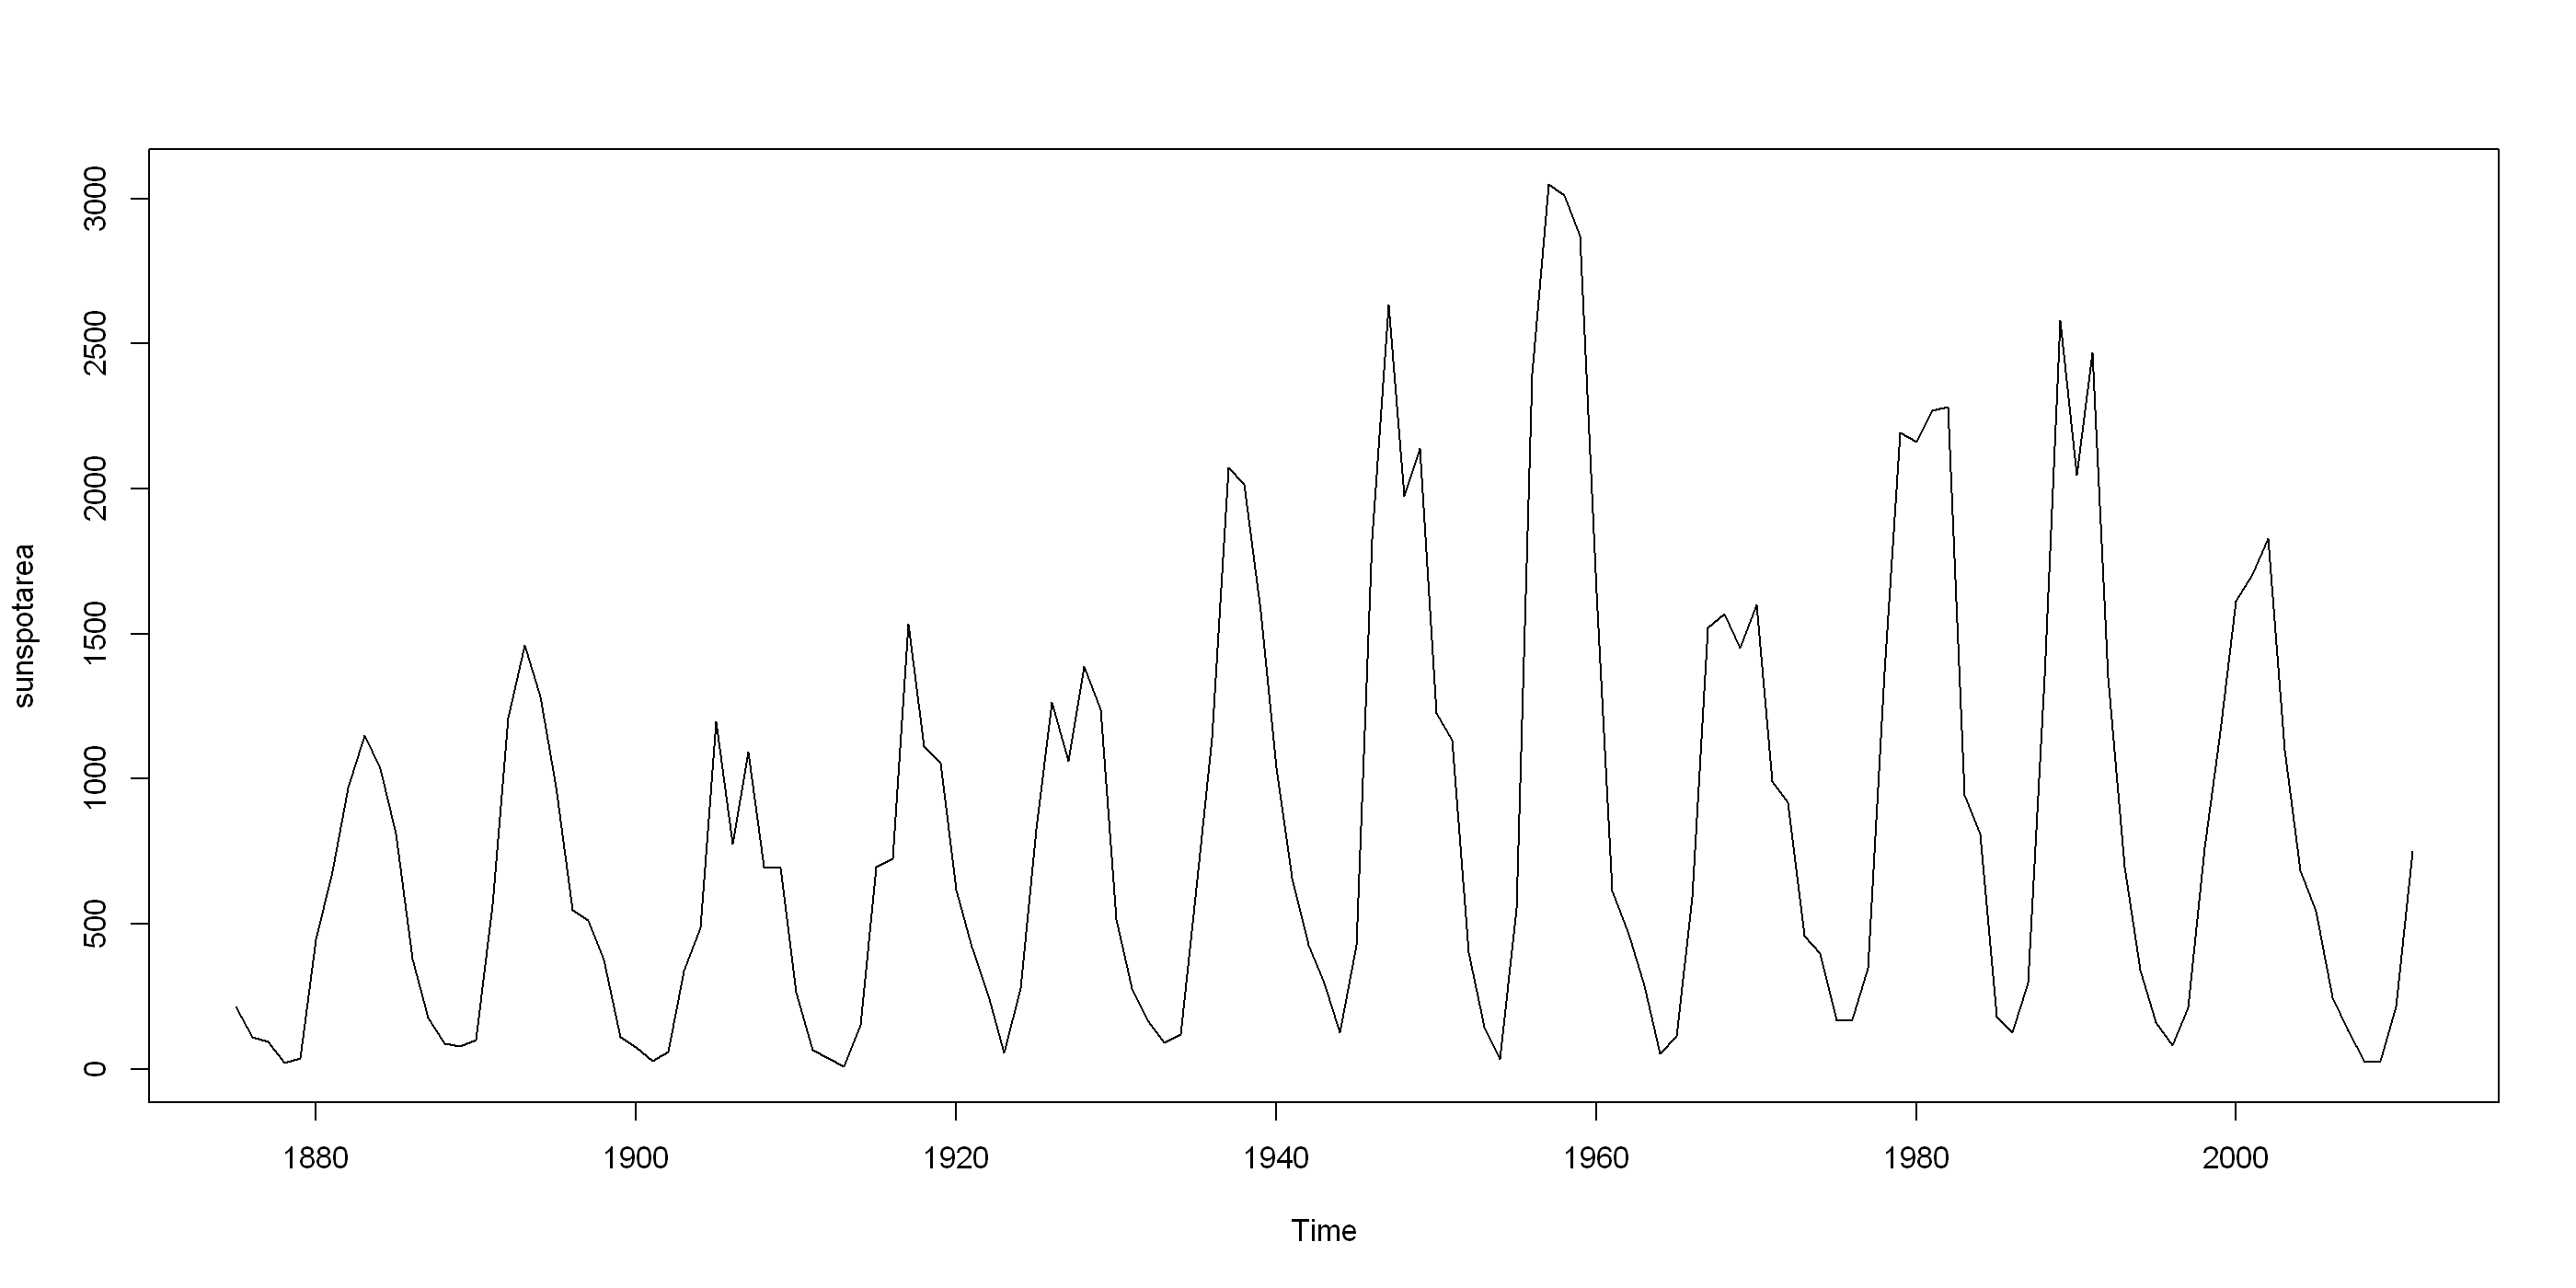

In [53]:
plot(sunspotarea)

In [54]:
sunspots.log <- log(sunspotarea)

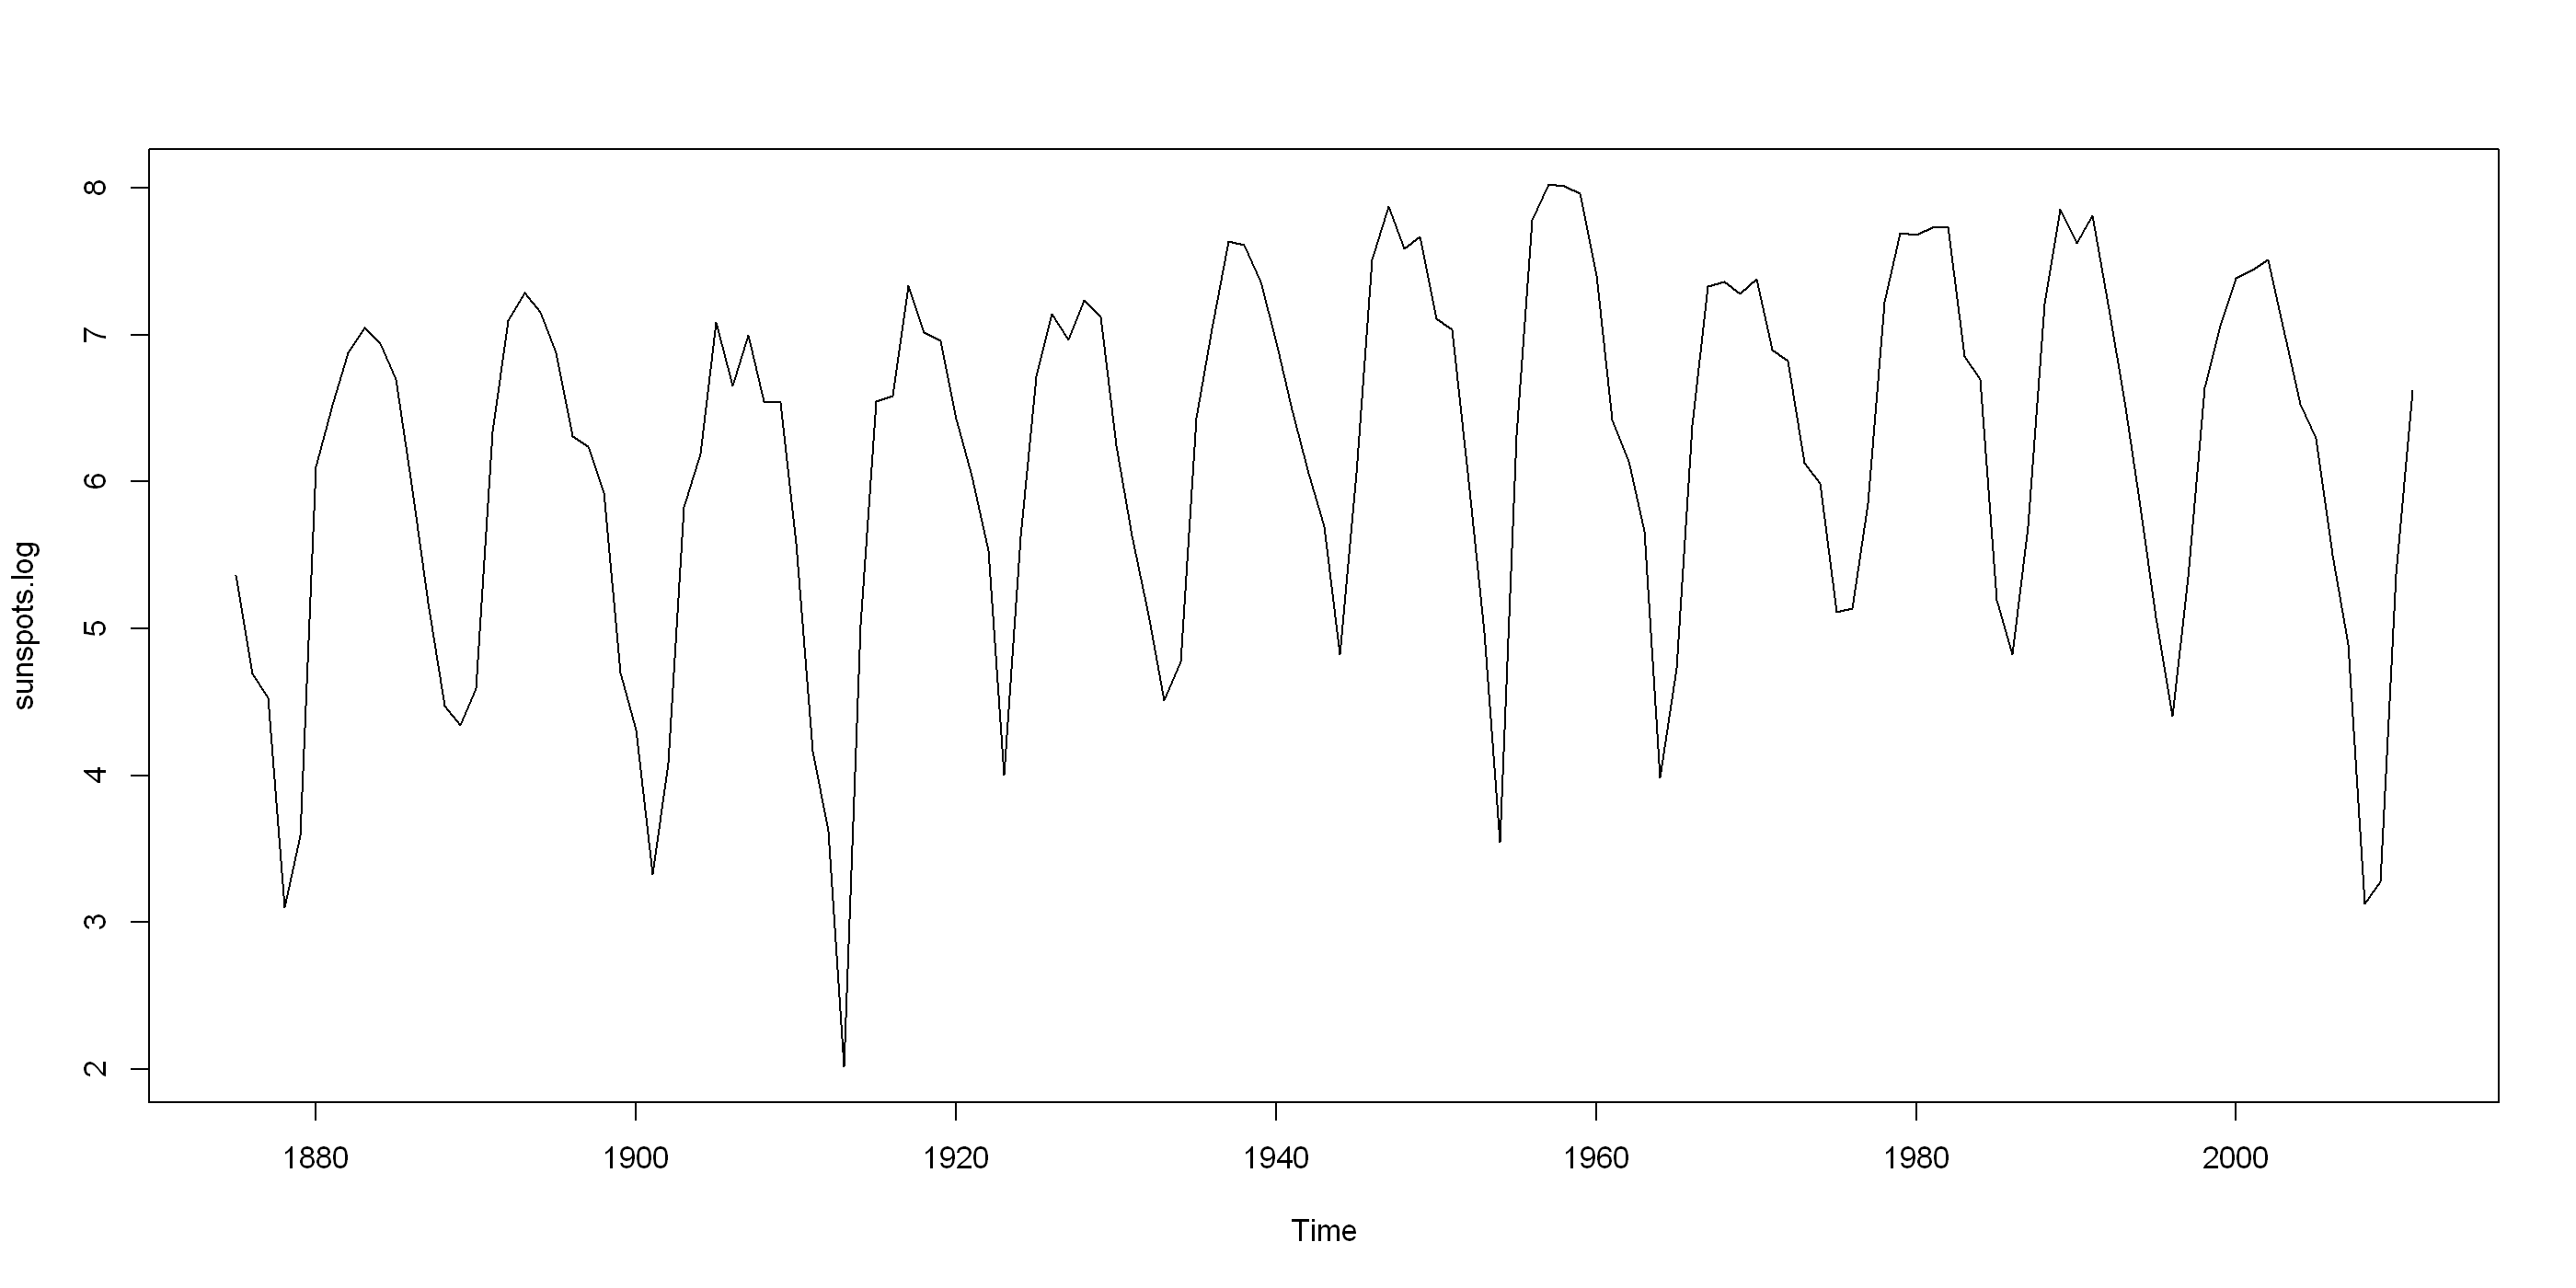

In [55]:
plot(sunspots.log)

In [56]:
sunspots.cut <- window(sunspots.log,start = 1875,end=1974)

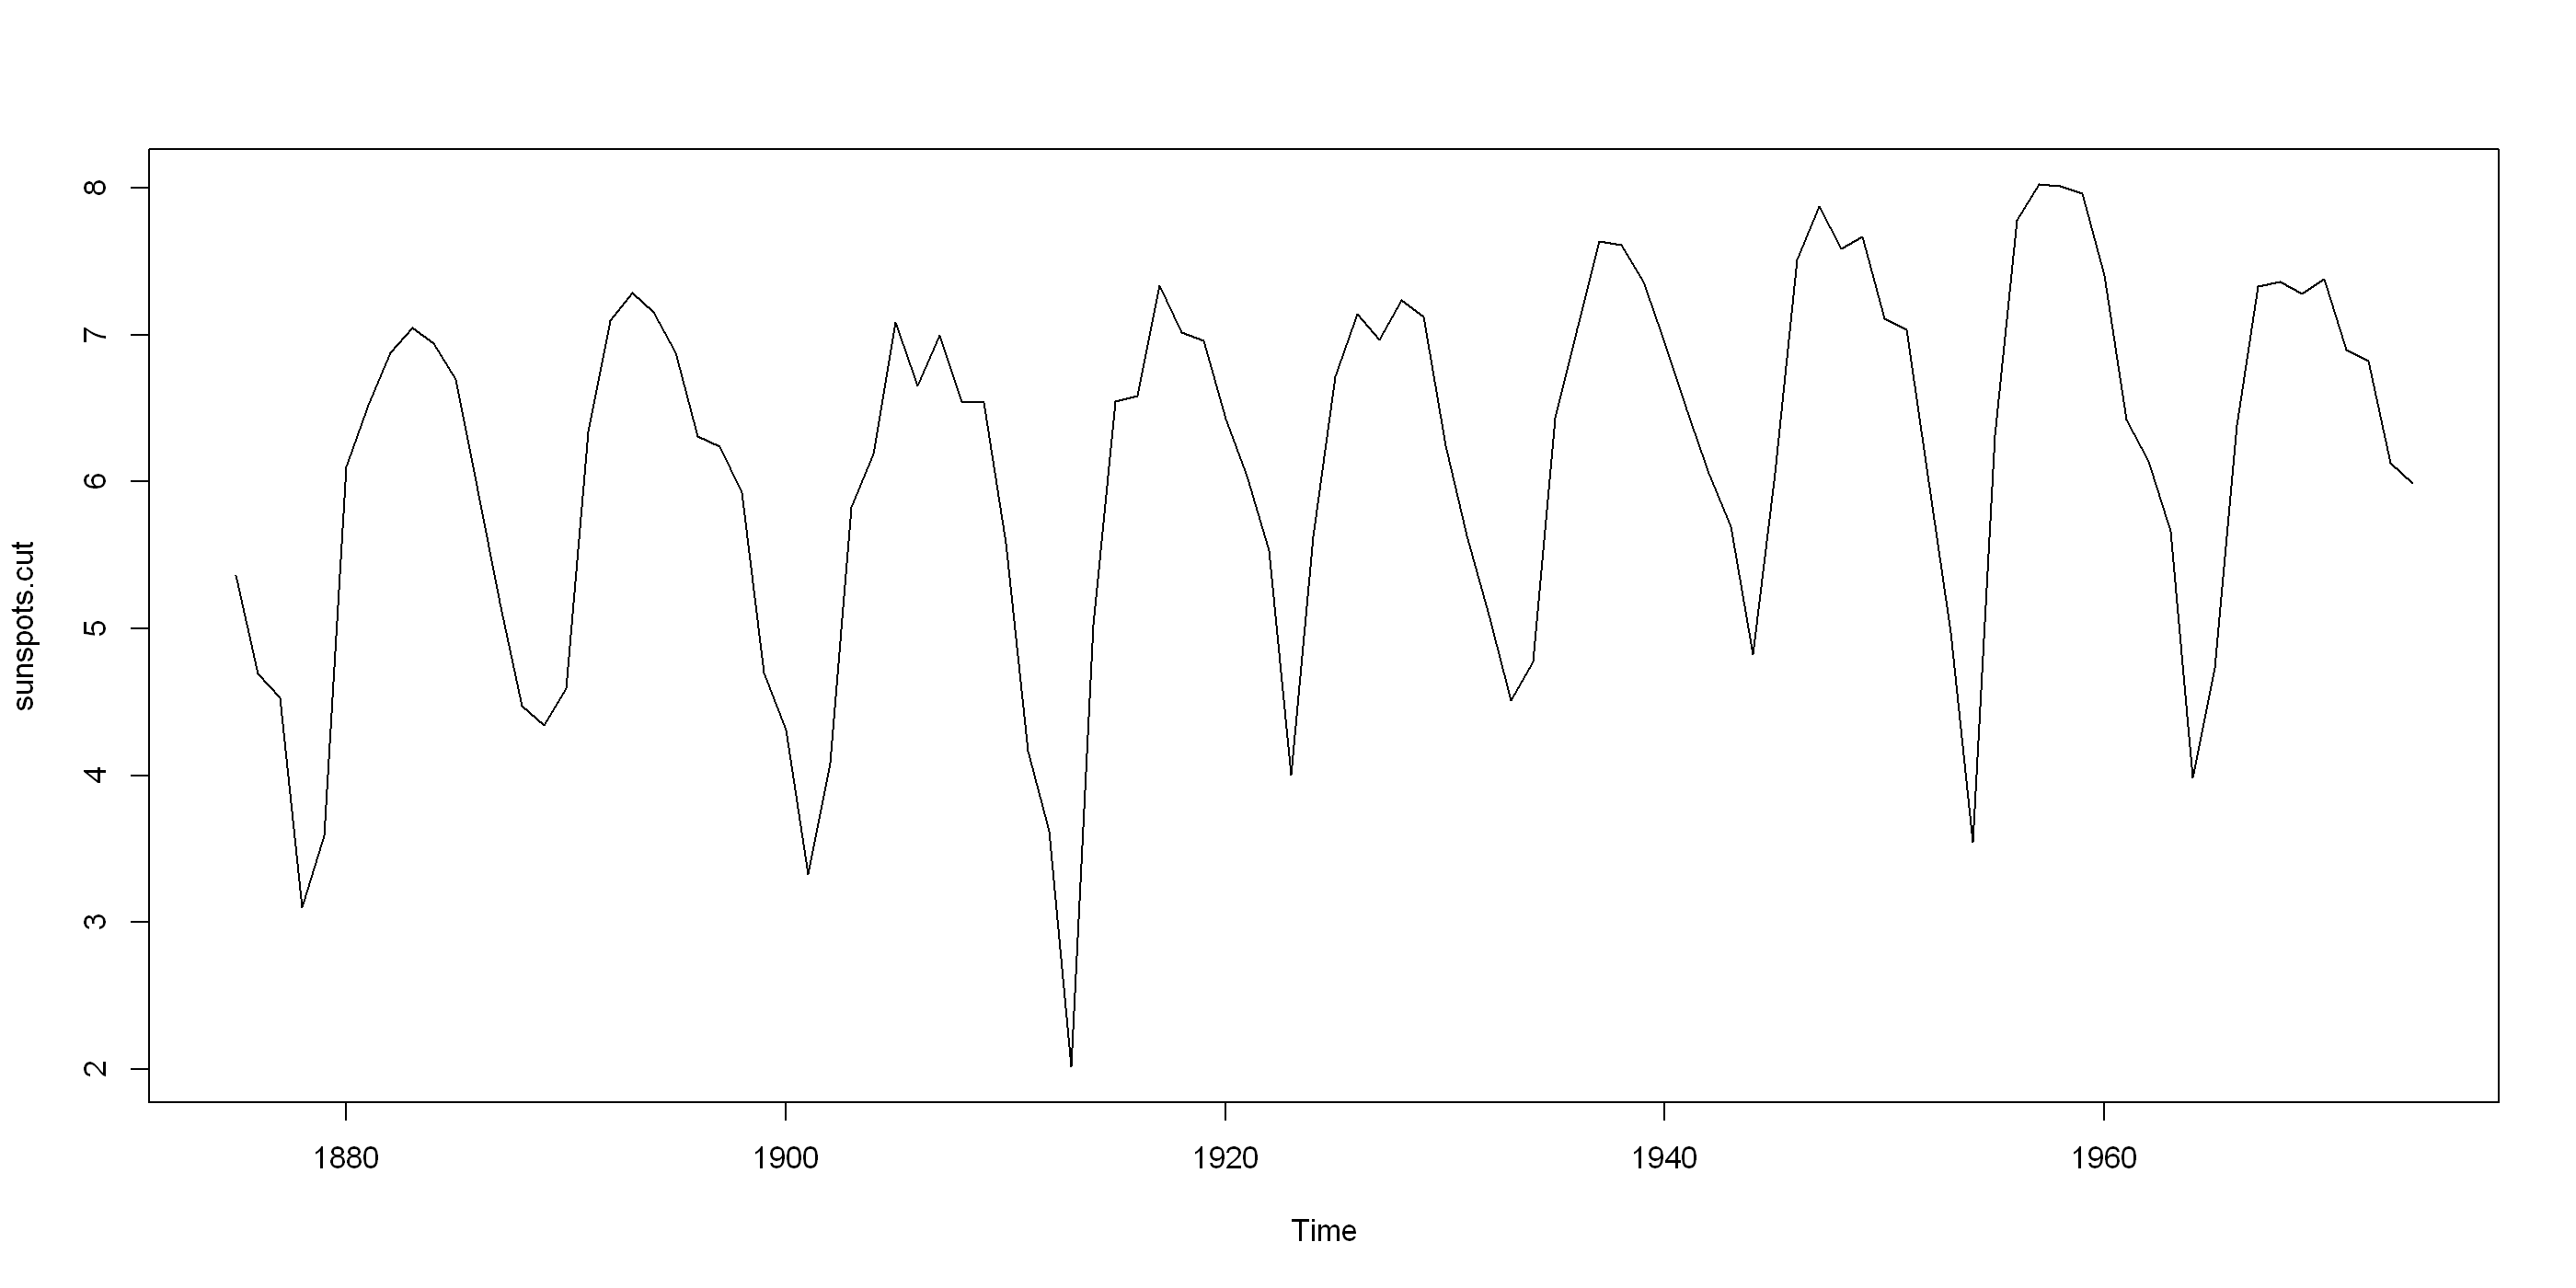

In [57]:
plot(sunspots.cut)

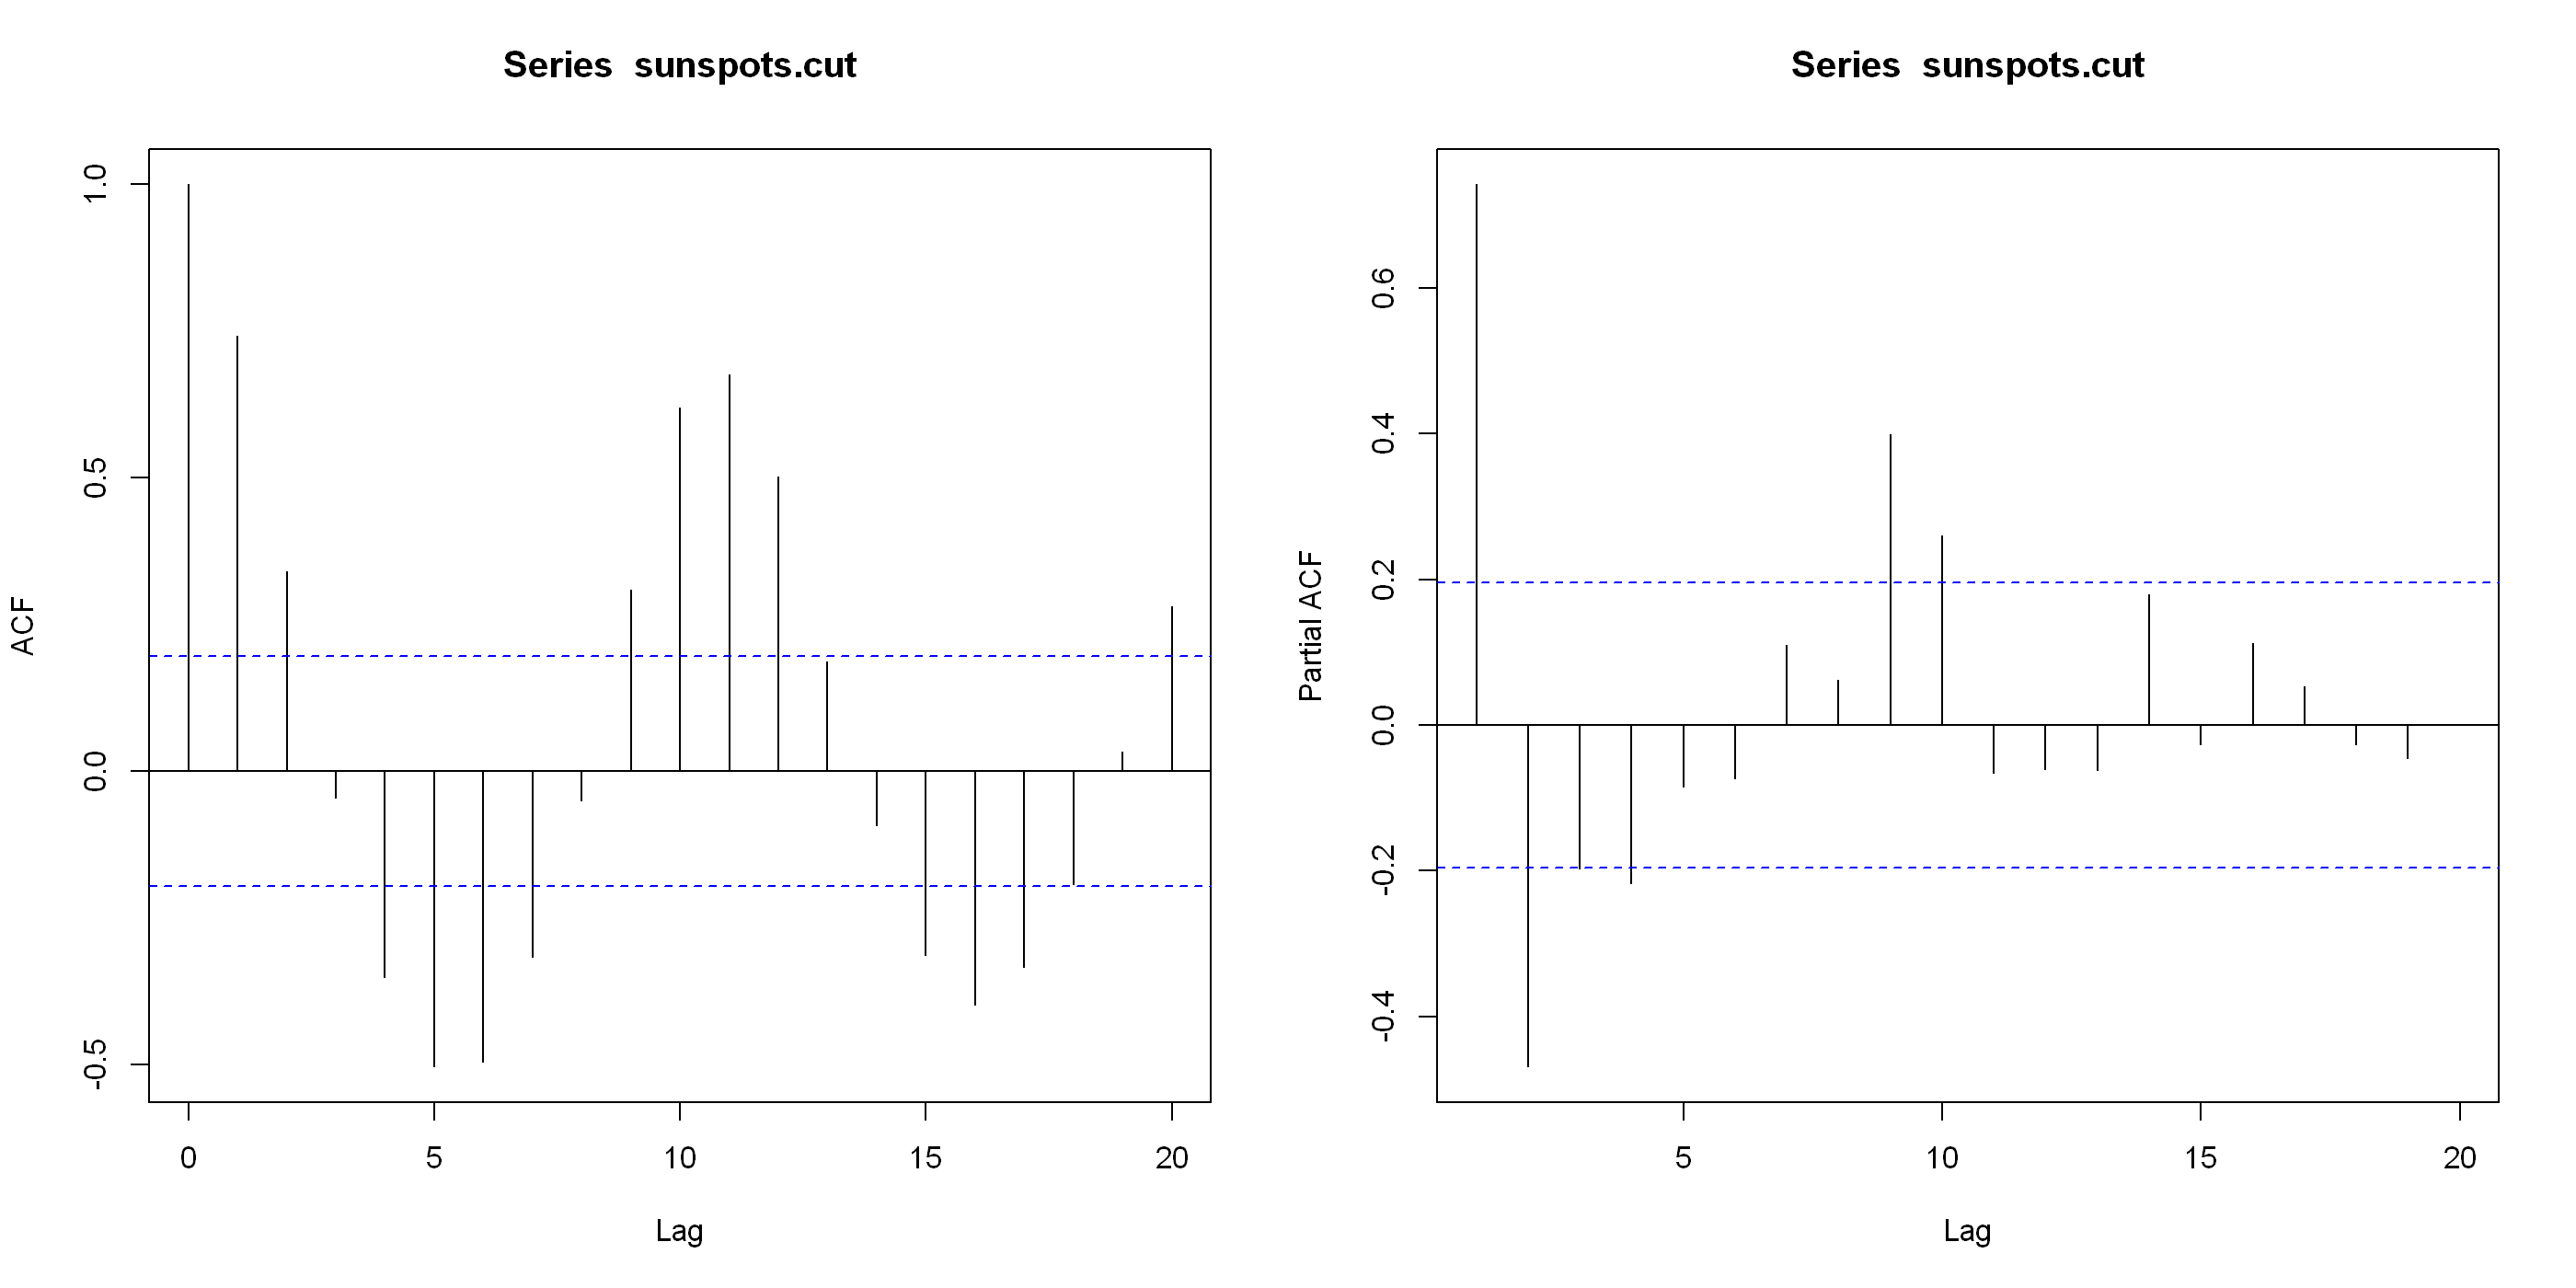

In [58]:
par(mfrow=c(1,2))
acf(sunspots.cut)
pacf(sunspots.cut)

In [59]:
fit <- auto.arima(
  sunspots.cut,
  d = 0,
  max.p = 15,
  max.q = 0,
  max.order = 15,
  seasonal = FALSE,
  stepwise = FALSE,
  approximation = FALSE,
  trace = TRUE
)


 ARIMA(0,0,0) with zero mean     : 651.991
 ARIMA(0,0,0) with non-zero mean : 335.5807
 ARIMA(1,0,0) with zero mean     : 272.6797
 ARIMA(1,0,0) with non-zero mean : 257.9244
 ARIMA(2,0,0) with zero mean     : 266.6257
 ARIMA(2,0,0) with non-zero mean : 235.9116
 ARIMA(3,0,0) with zero mean     : 267.6733
 ARIMA(3,0,0) with non-zero mean : 234.007
 ARIMA(4,0,0) with zero mean     : 268.1371
 ARIMA(4,0,0) with non-zero mean : 230.9483
 ARIMA(5,0,0) with zero mean     : Inf
 ARIMA(5,0,0) with non-zero mean : 231.7444
 ARIMA(6,0,0) with zero mean     : Inf
 ARIMA(6,0,0) with non-zero mean : 233.1993
 ARIMA(7,0,0) with zero mean     : Inf
 ARIMA(7,0,0) with non-zero mean : 234.5332
 ARIMA(8,0,0) with zero mean     : Inf
 ARIMA(8,0,0) with non-zero mean : 236.7099
 ARIMA(9,0,0) with zero mean     : Inf
 ARIMA(9,0,0) with non-zero mean : 219.681
 ARIMA(10,0,0) with zero mean     : Inf
 ARIMA(10,0,0) with non-zero mean : 209.7891
 ARIMA(11,0,0) with zero mean     : Inf
 ARIMA(11,0,0) with no

In [60]:
model <- arima(sunspots.cut,order = c(10,0,0))

In [61]:
model


Call:
arima(x = sunspots.cut, order = c(10, 0, 0))

Coefficients:
         ar1      ar2     ar3      ar4     ar5      ar6     ar7      ar8
      0.7171  -0.1887  0.0045  -0.0621  0.0220  -0.1140  0.1694  -0.2284
s.e.  0.0938   0.1175  0.1176   0.1180  0.1159   0.1183  0.1184   0.1189
         ar9    ar10  intercept
      0.1272  0.3601     6.1045
s.e.  0.1207  0.0970     0.2597

sigma^2 estimated as 0.3439:  log likelihood = -91.1,  aic = 206.2

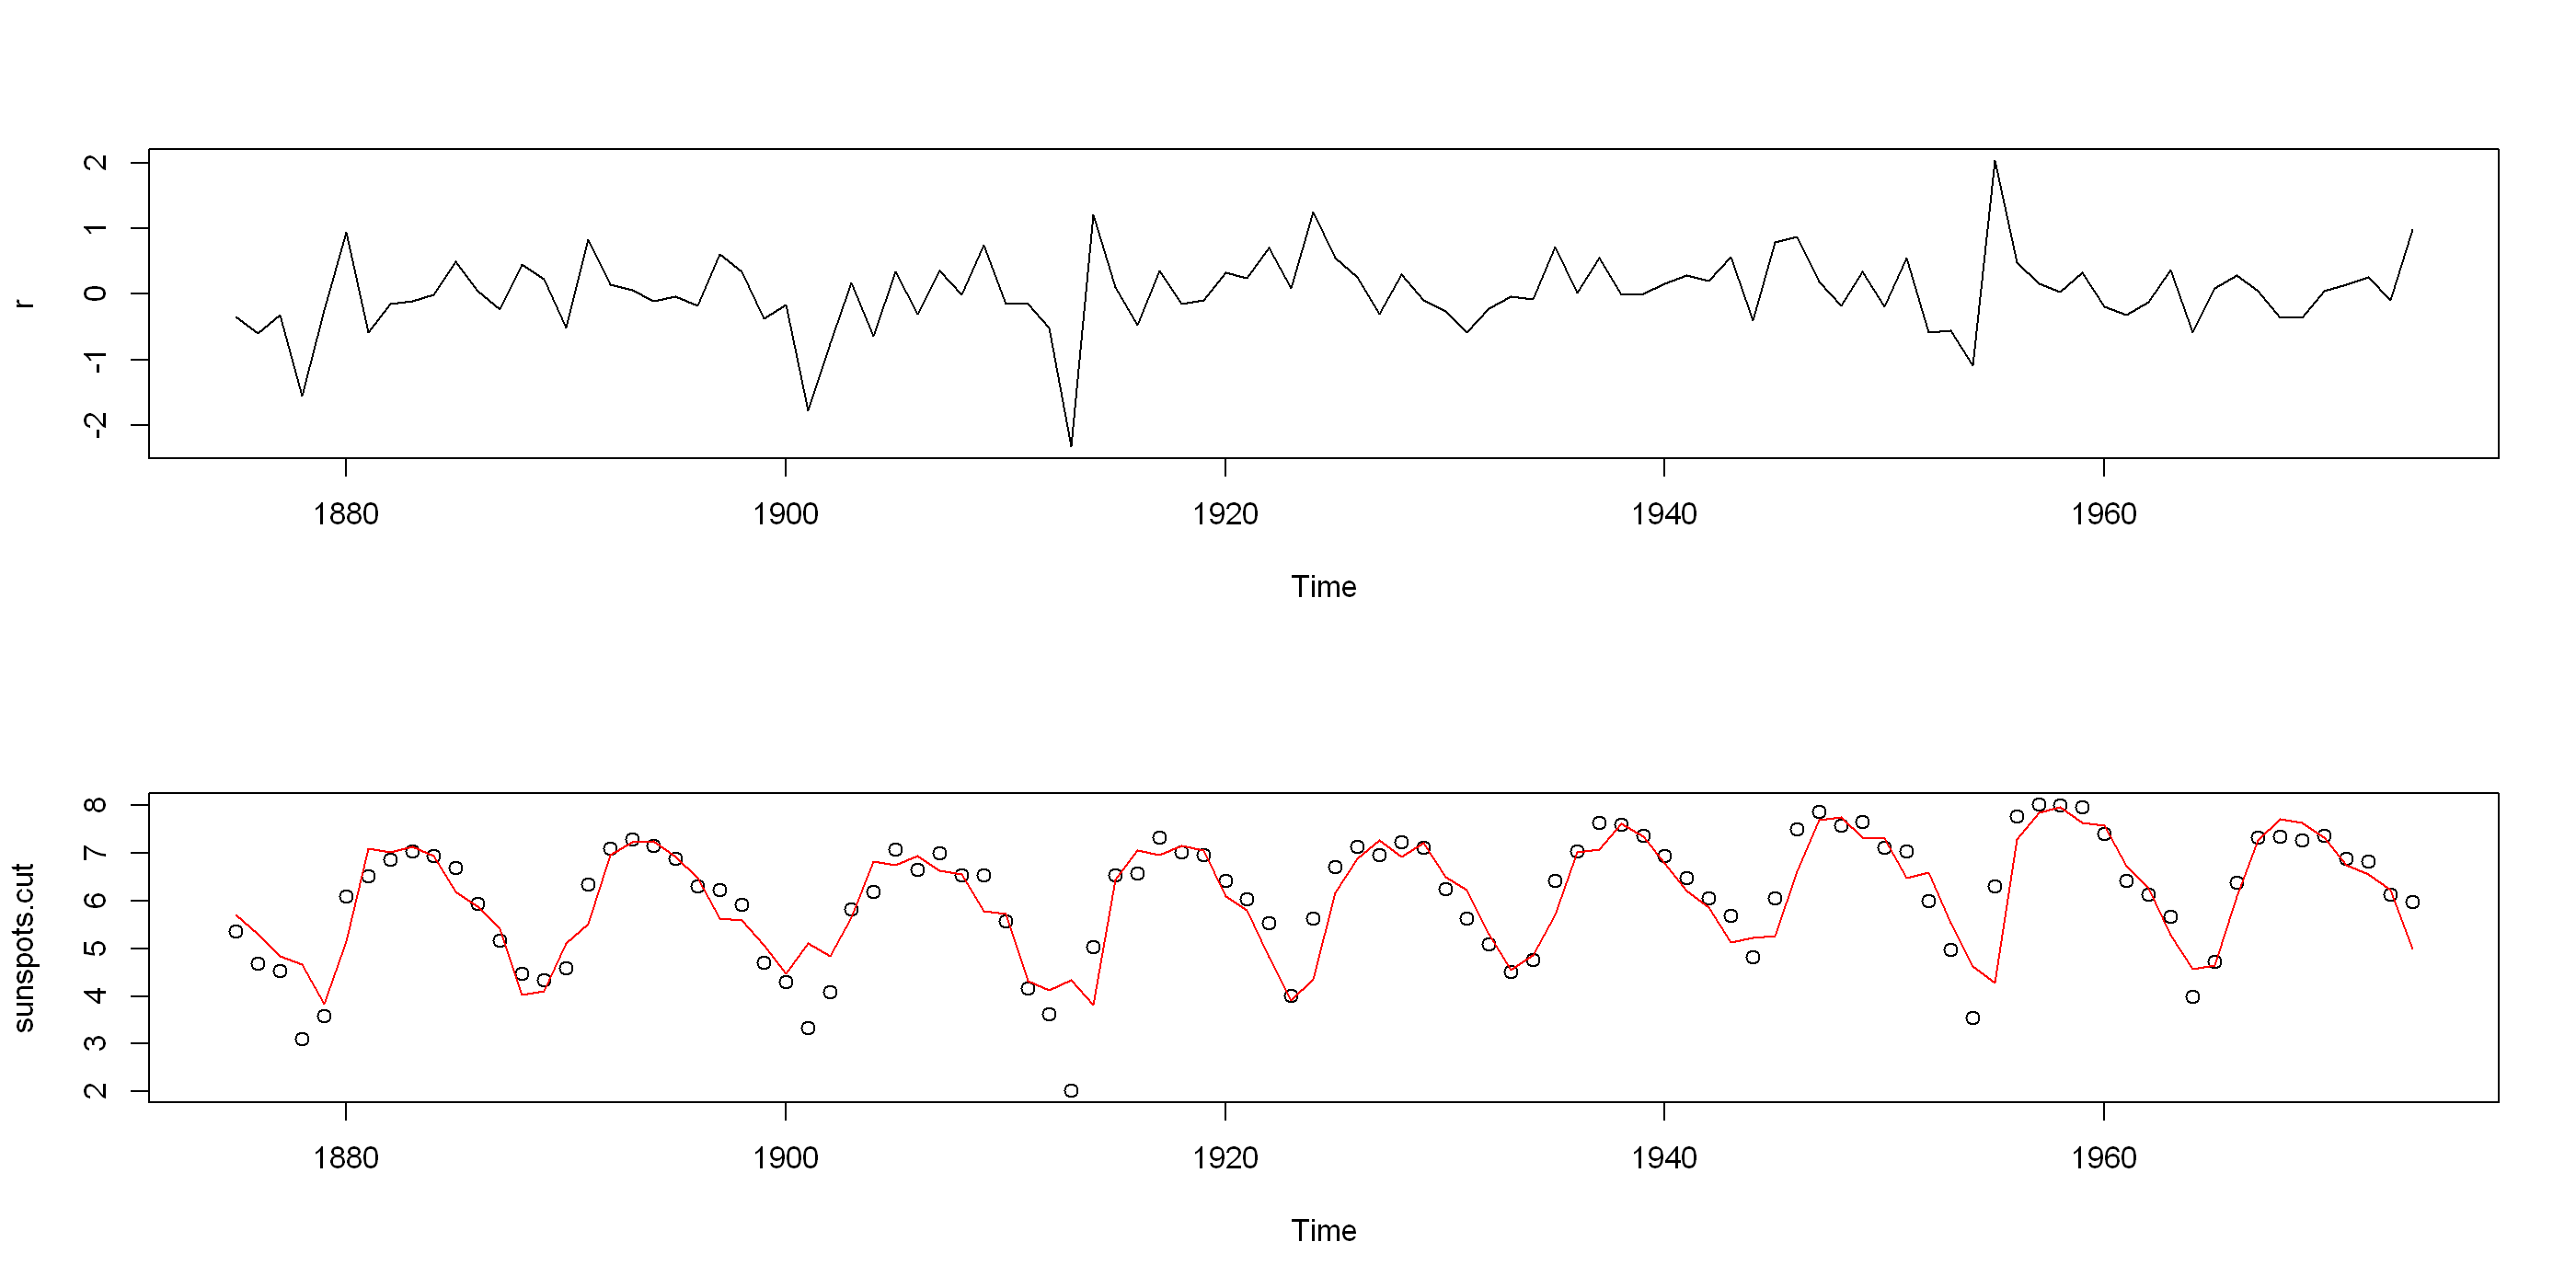

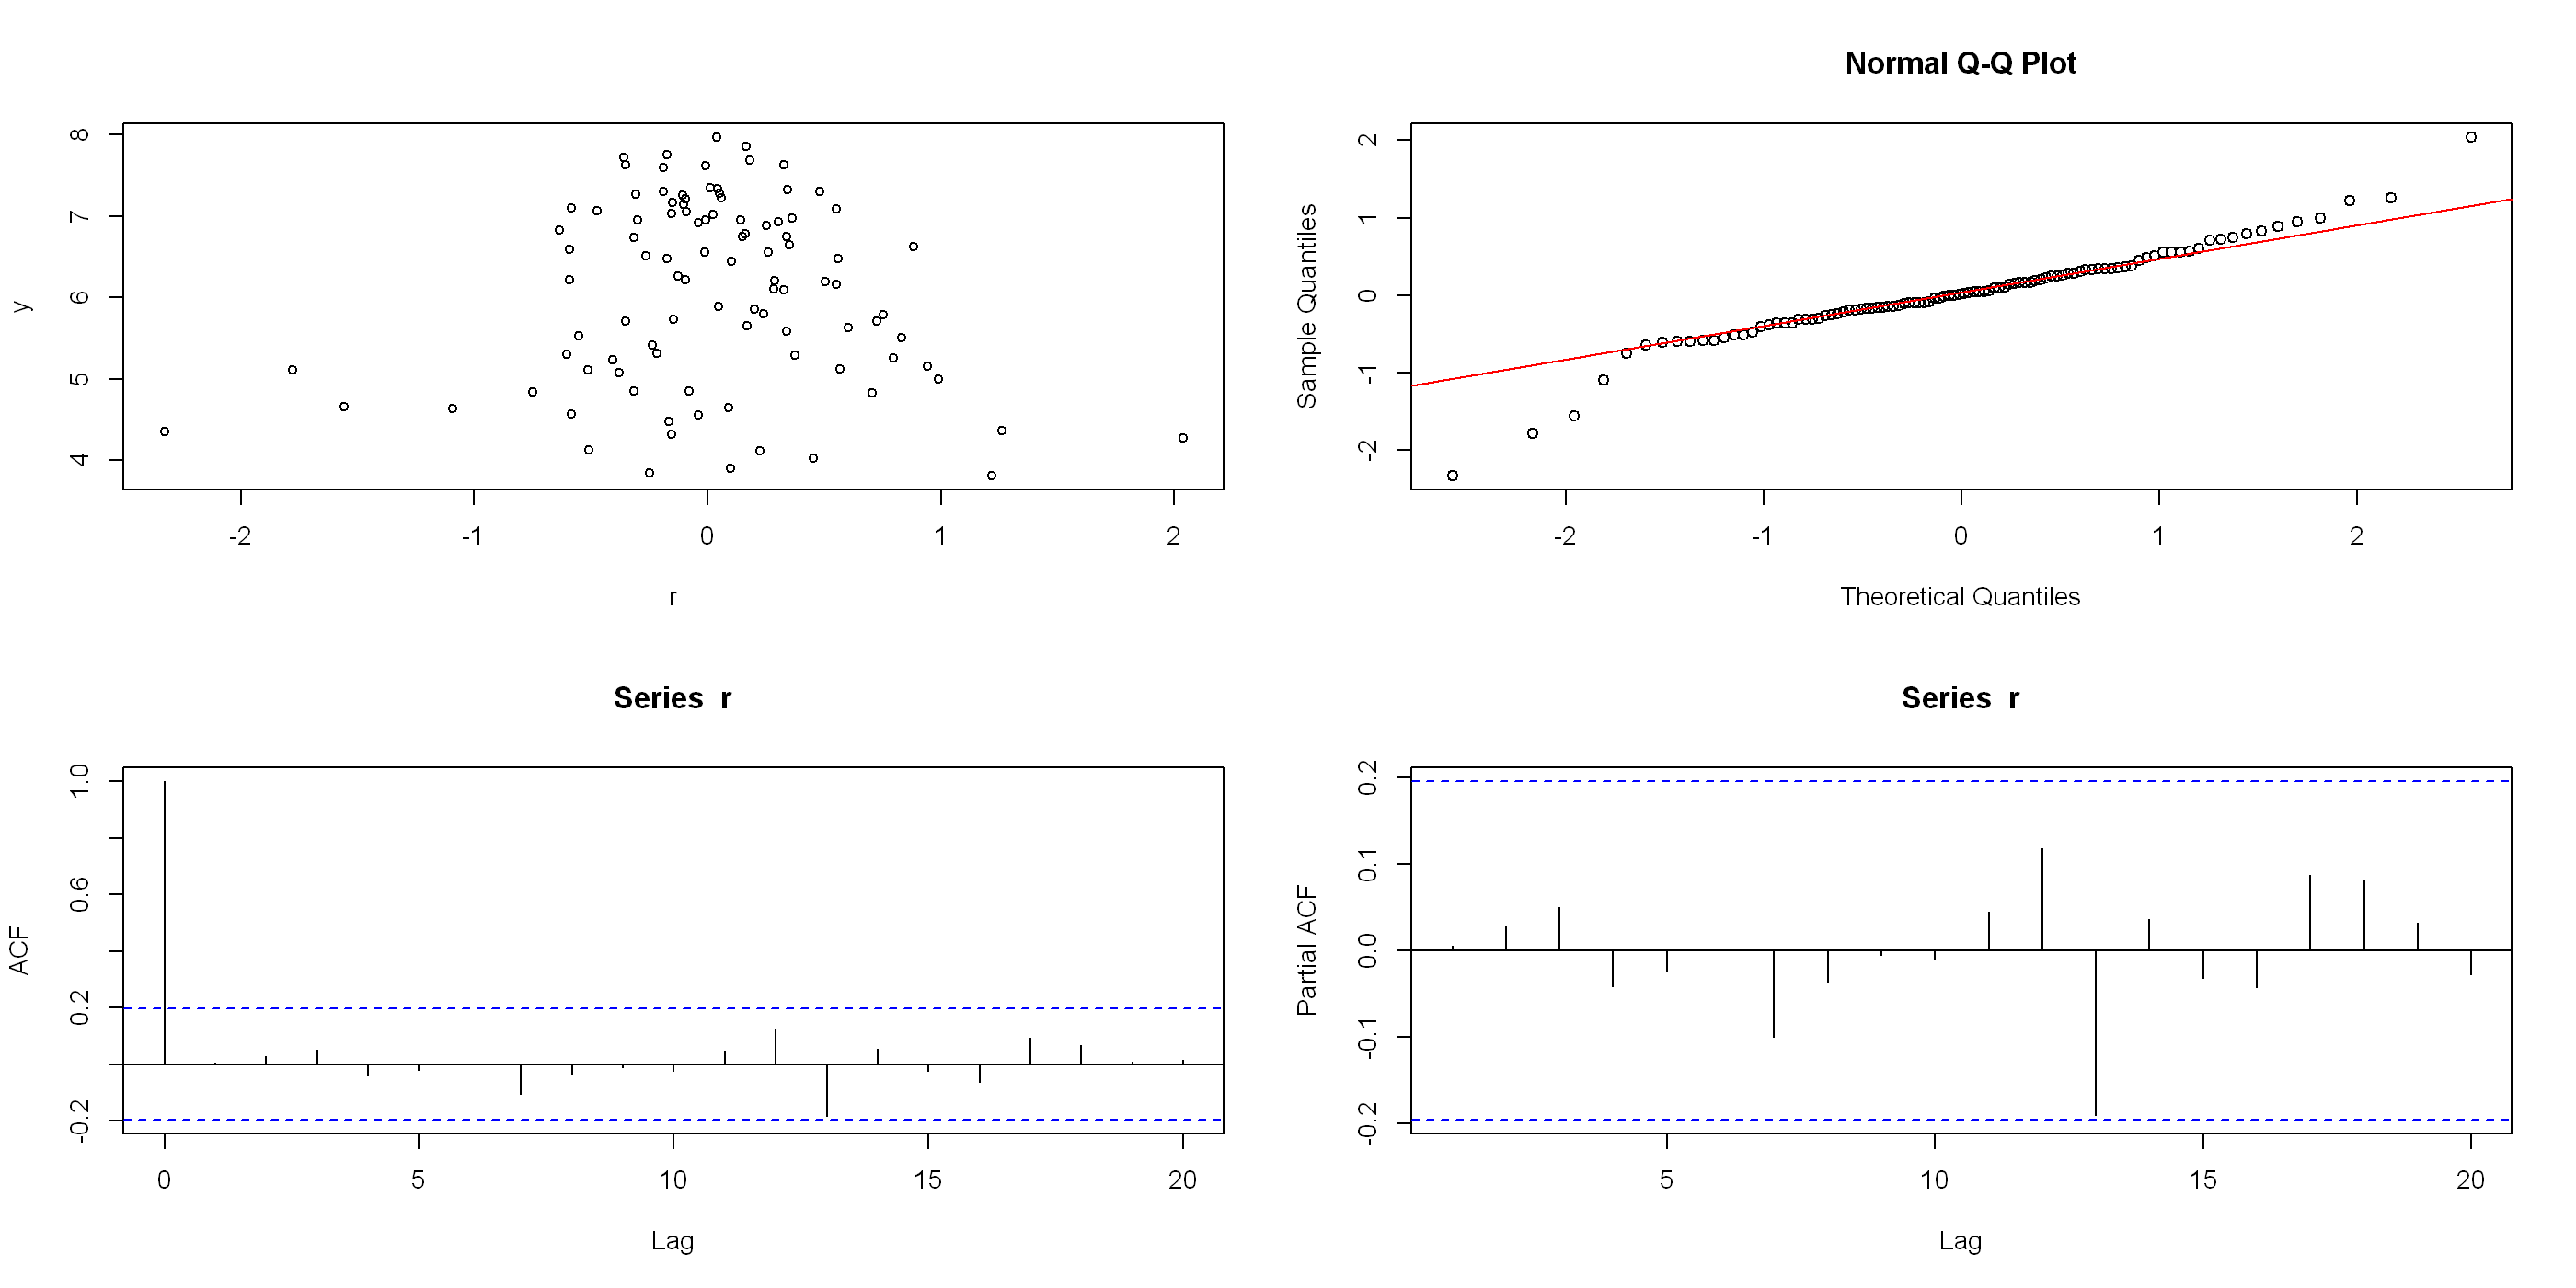

In [62]:
r <- na.omit(model$residuals)
y <- sunspots.cut-r
par(mfrow = c(2,1))
plot(r,type="l")
plot(sunspots.cut,type="p")
lines(y,col="red")
par(mfrow = c(2,2))

plot(r,y,type="p",xy.labels = FALSE, xy.lines = FALSE)
qqnorm(r)
qqline(r,col="red")
acf(r)
pacf(r)


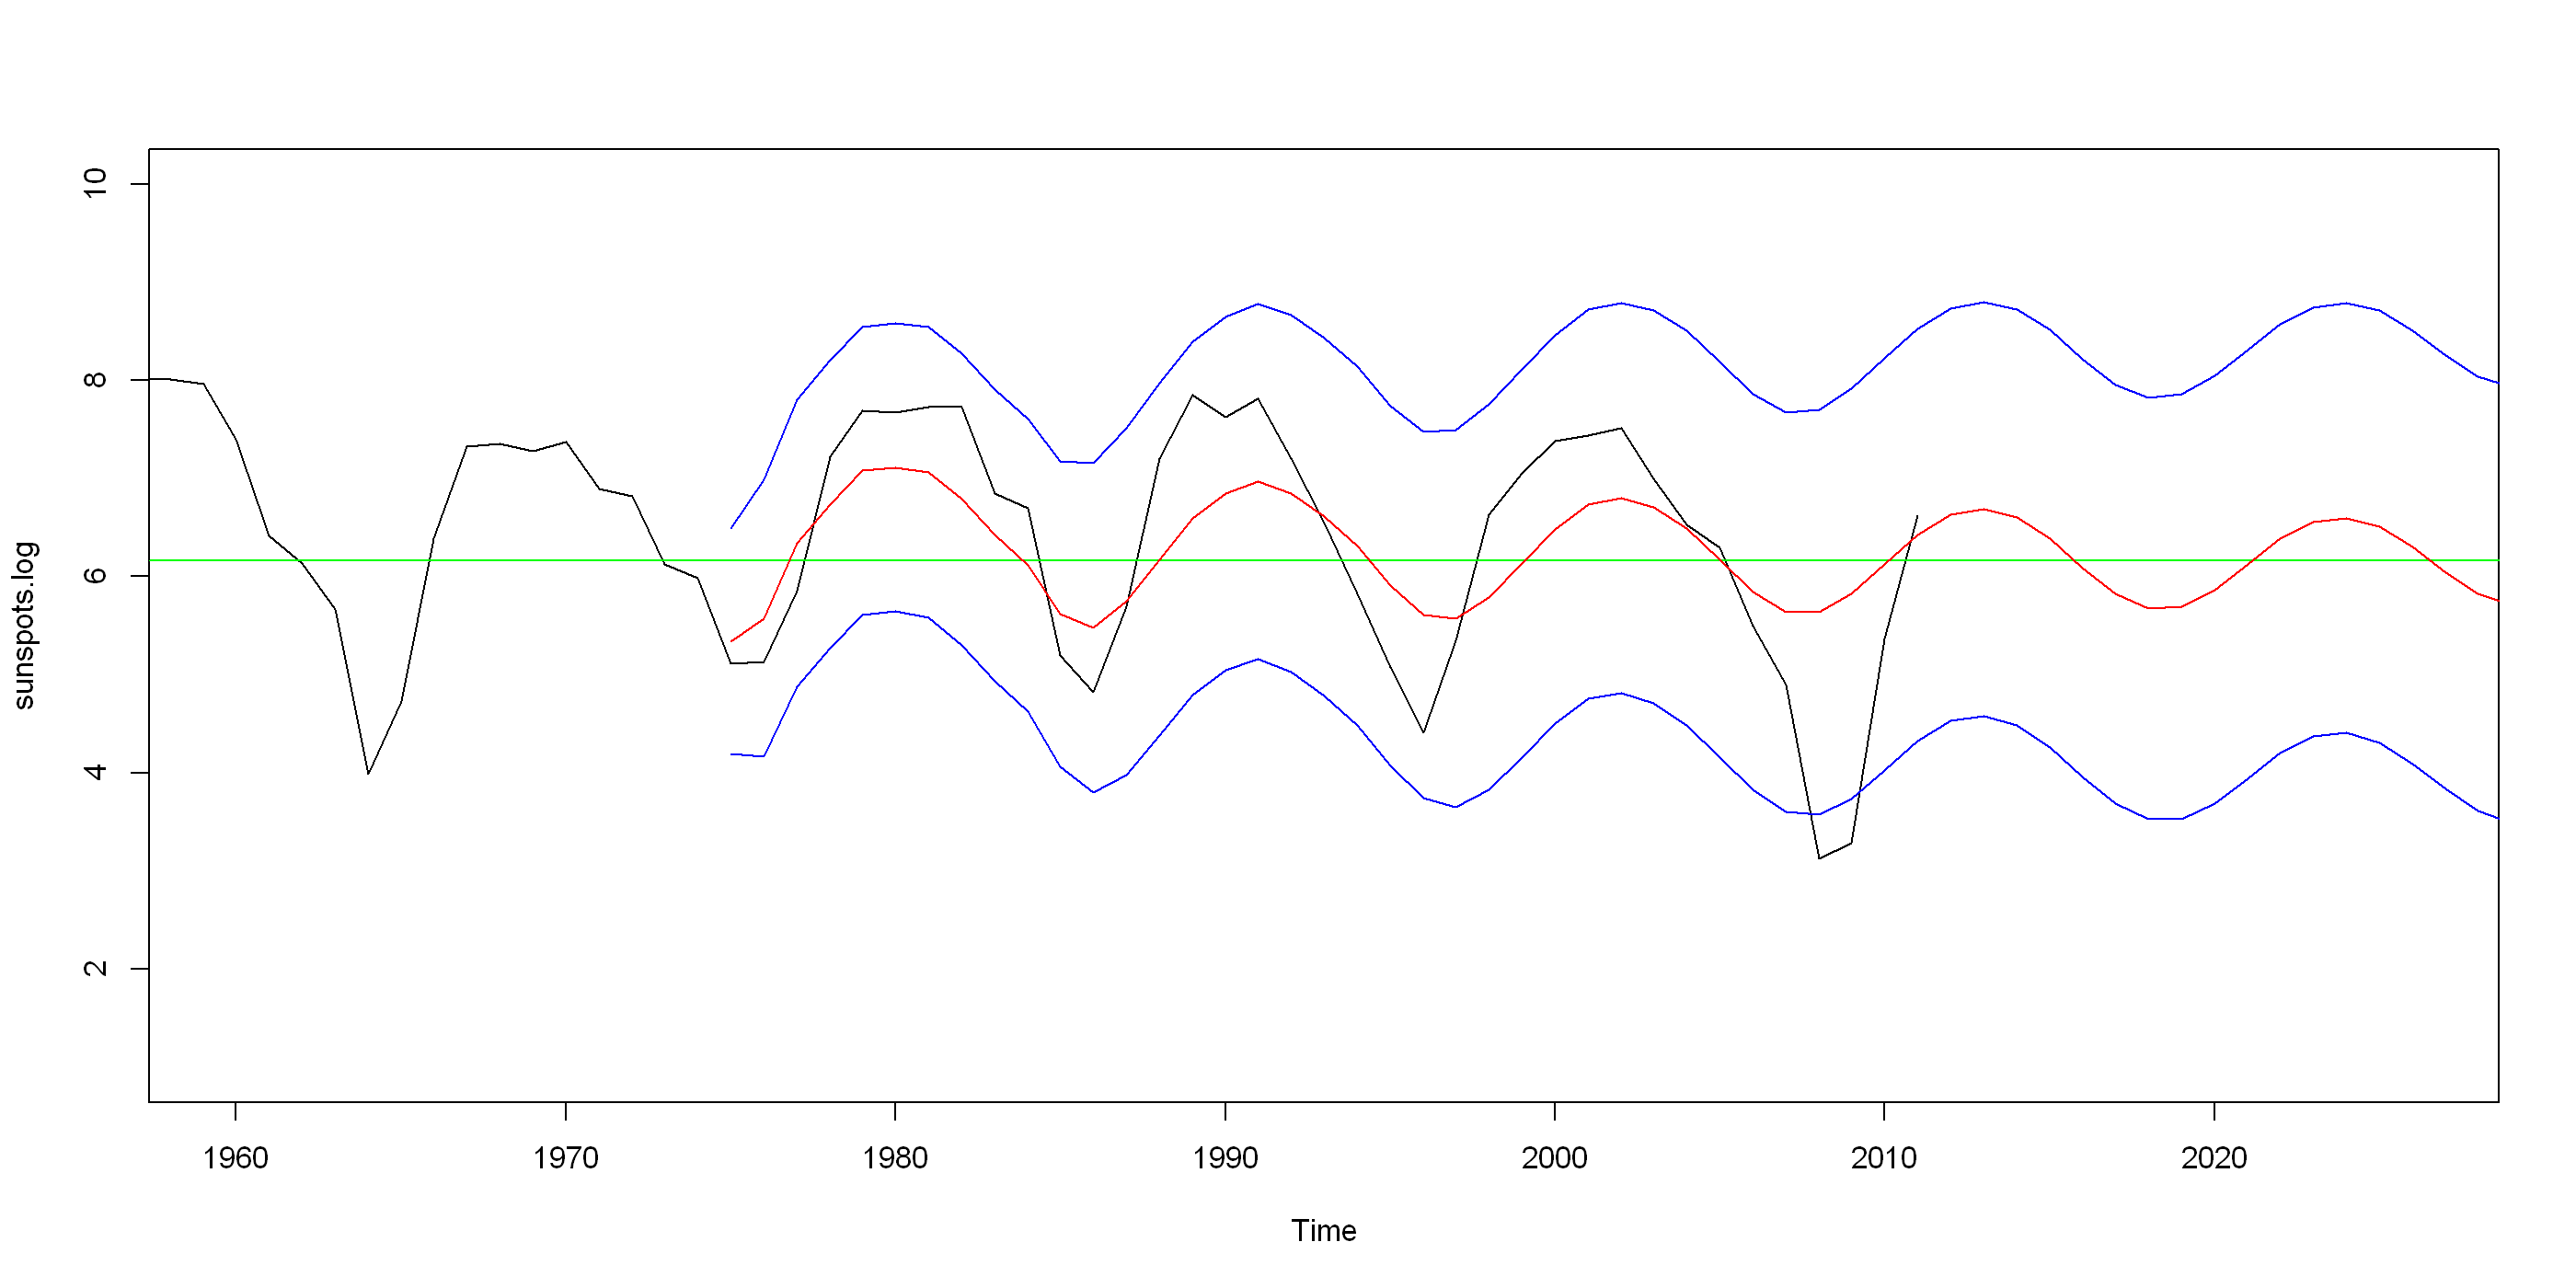

In [63]:
y_hat <- predict(model,n.ahead=100)
CI <- qnorm(0.975)*y_hat$se
plot(sunspots.log,ylim=c(1,10),xlim=c(1960,2026))
abline(h=mean(sunspots.log),col="green")
lines(y_hat$pred+CI,col="blue")
lines(y_hat$pred-CI,col="blue")

lines(y_hat$pred,col="red")

In [64]:
sum((window(sunspots.log,start=1974)-window(y_hat$pred,end=2011))^2)/(length(window(y_hat$pred,end=2011)))

[1] 0.7557876

In [65]:
t.url <- "http://stat.ethz.ch/Teaching/Datasets/WBL/varve.dat"
d.varve <- ts(scan(t.url)[201:550])

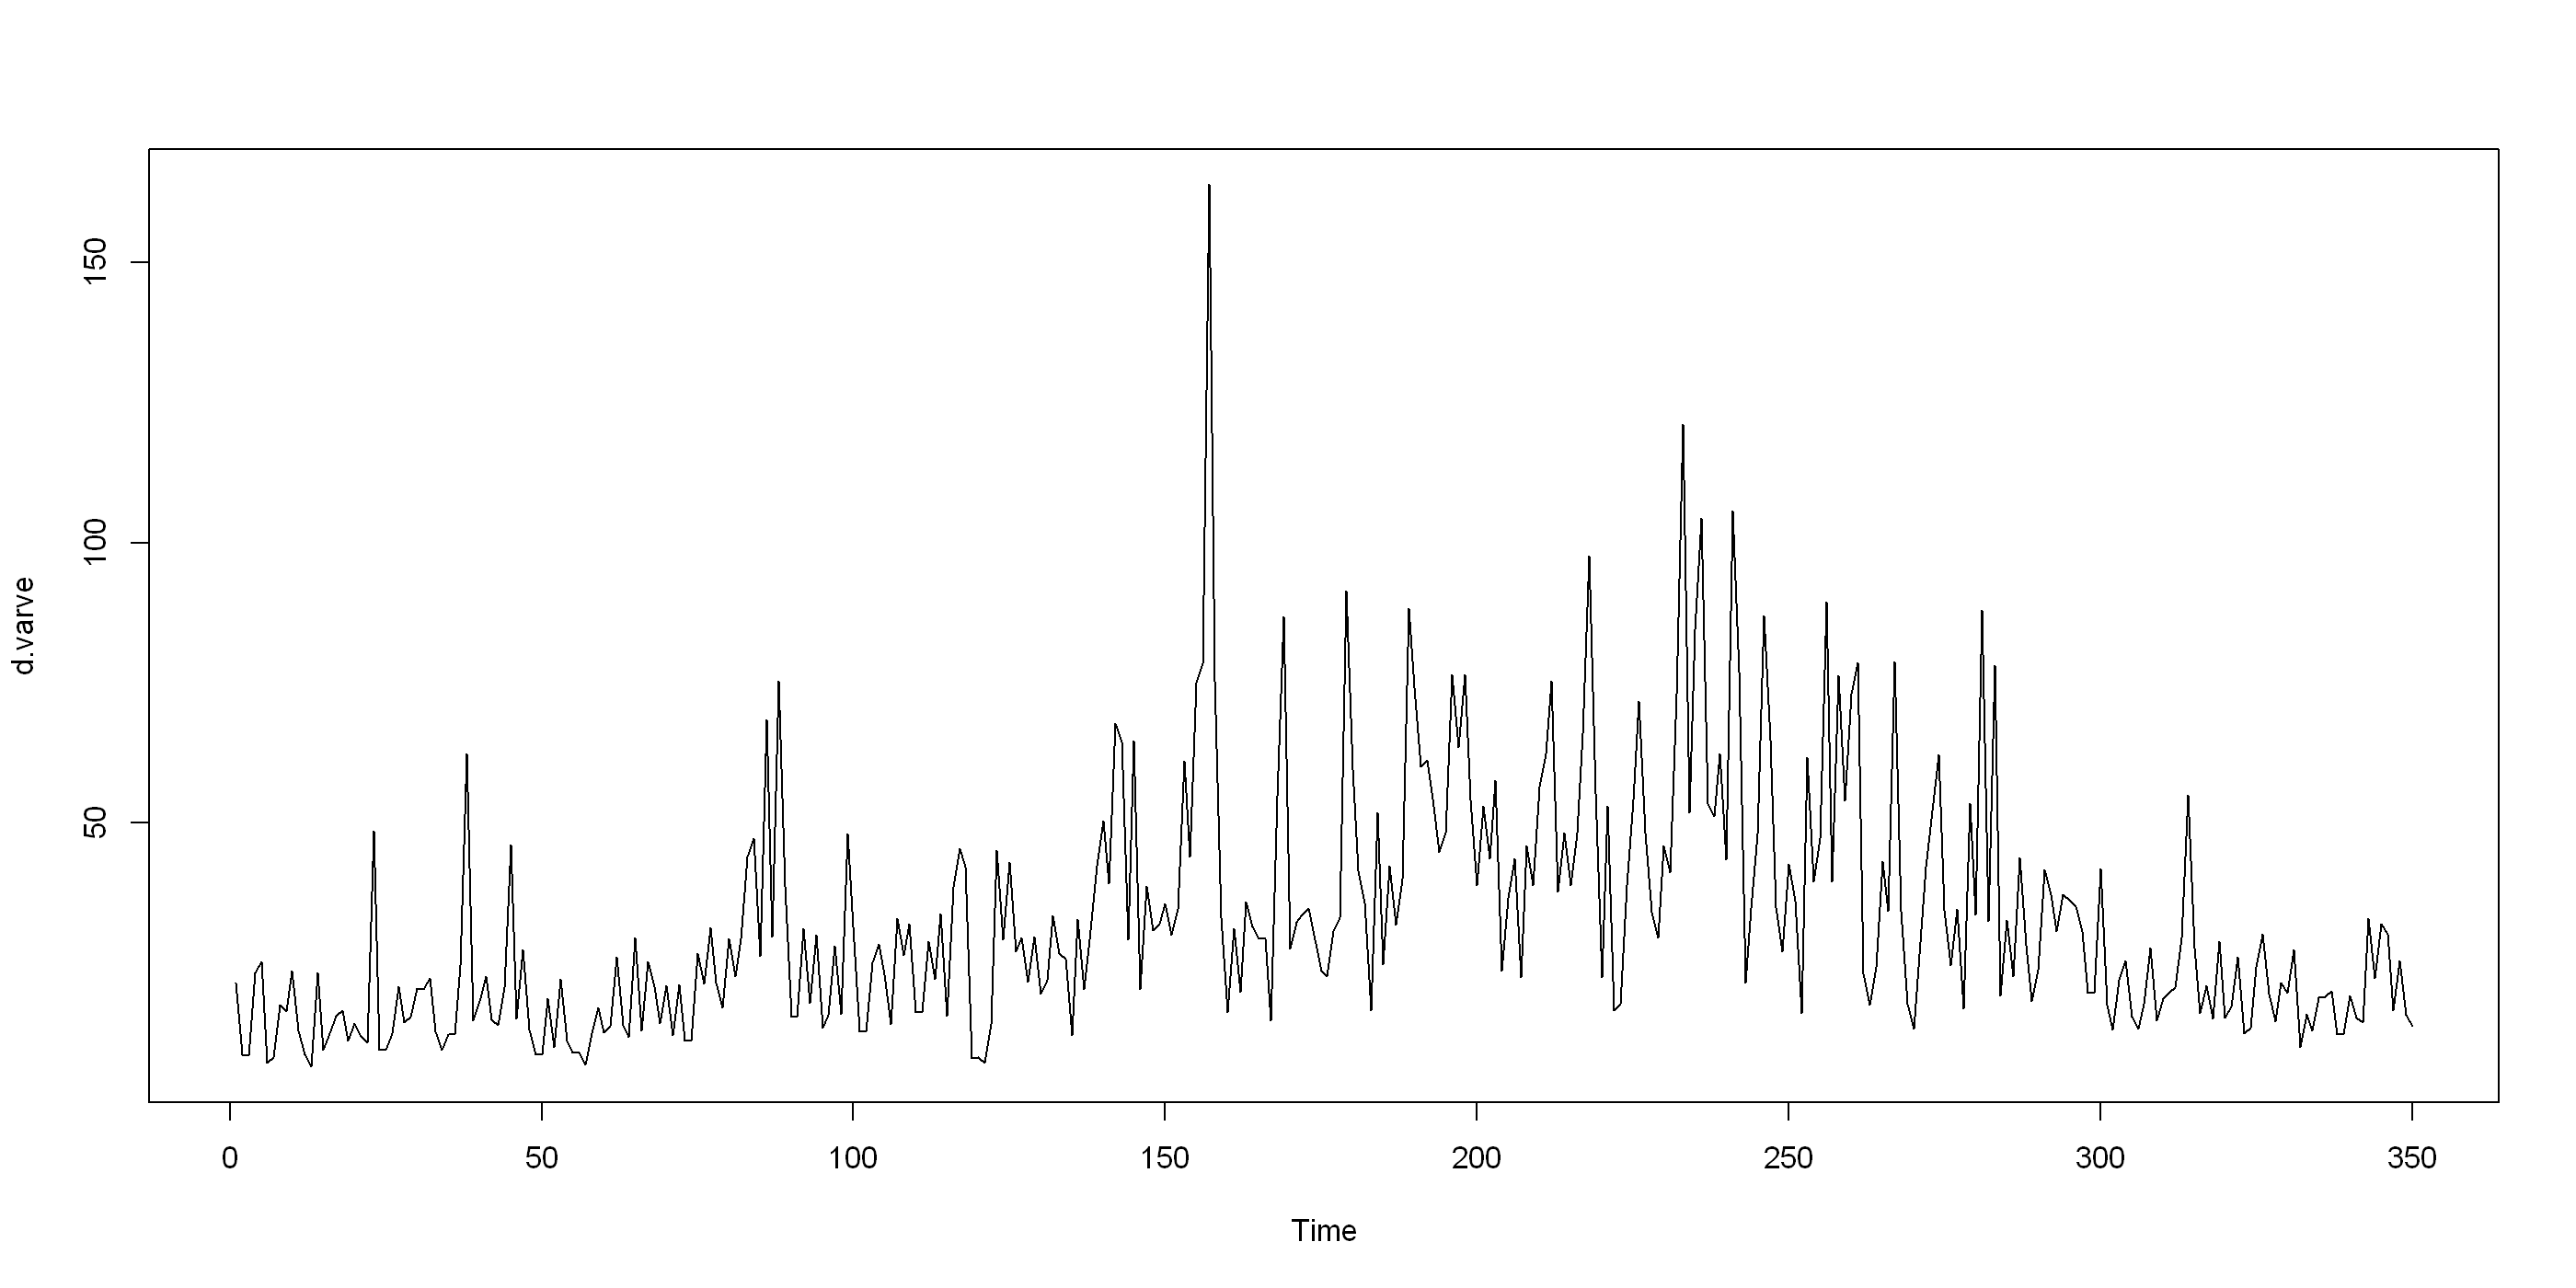

In [66]:
plot(d.varve)

In [67]:
d.varve.log <- log(d.varve)

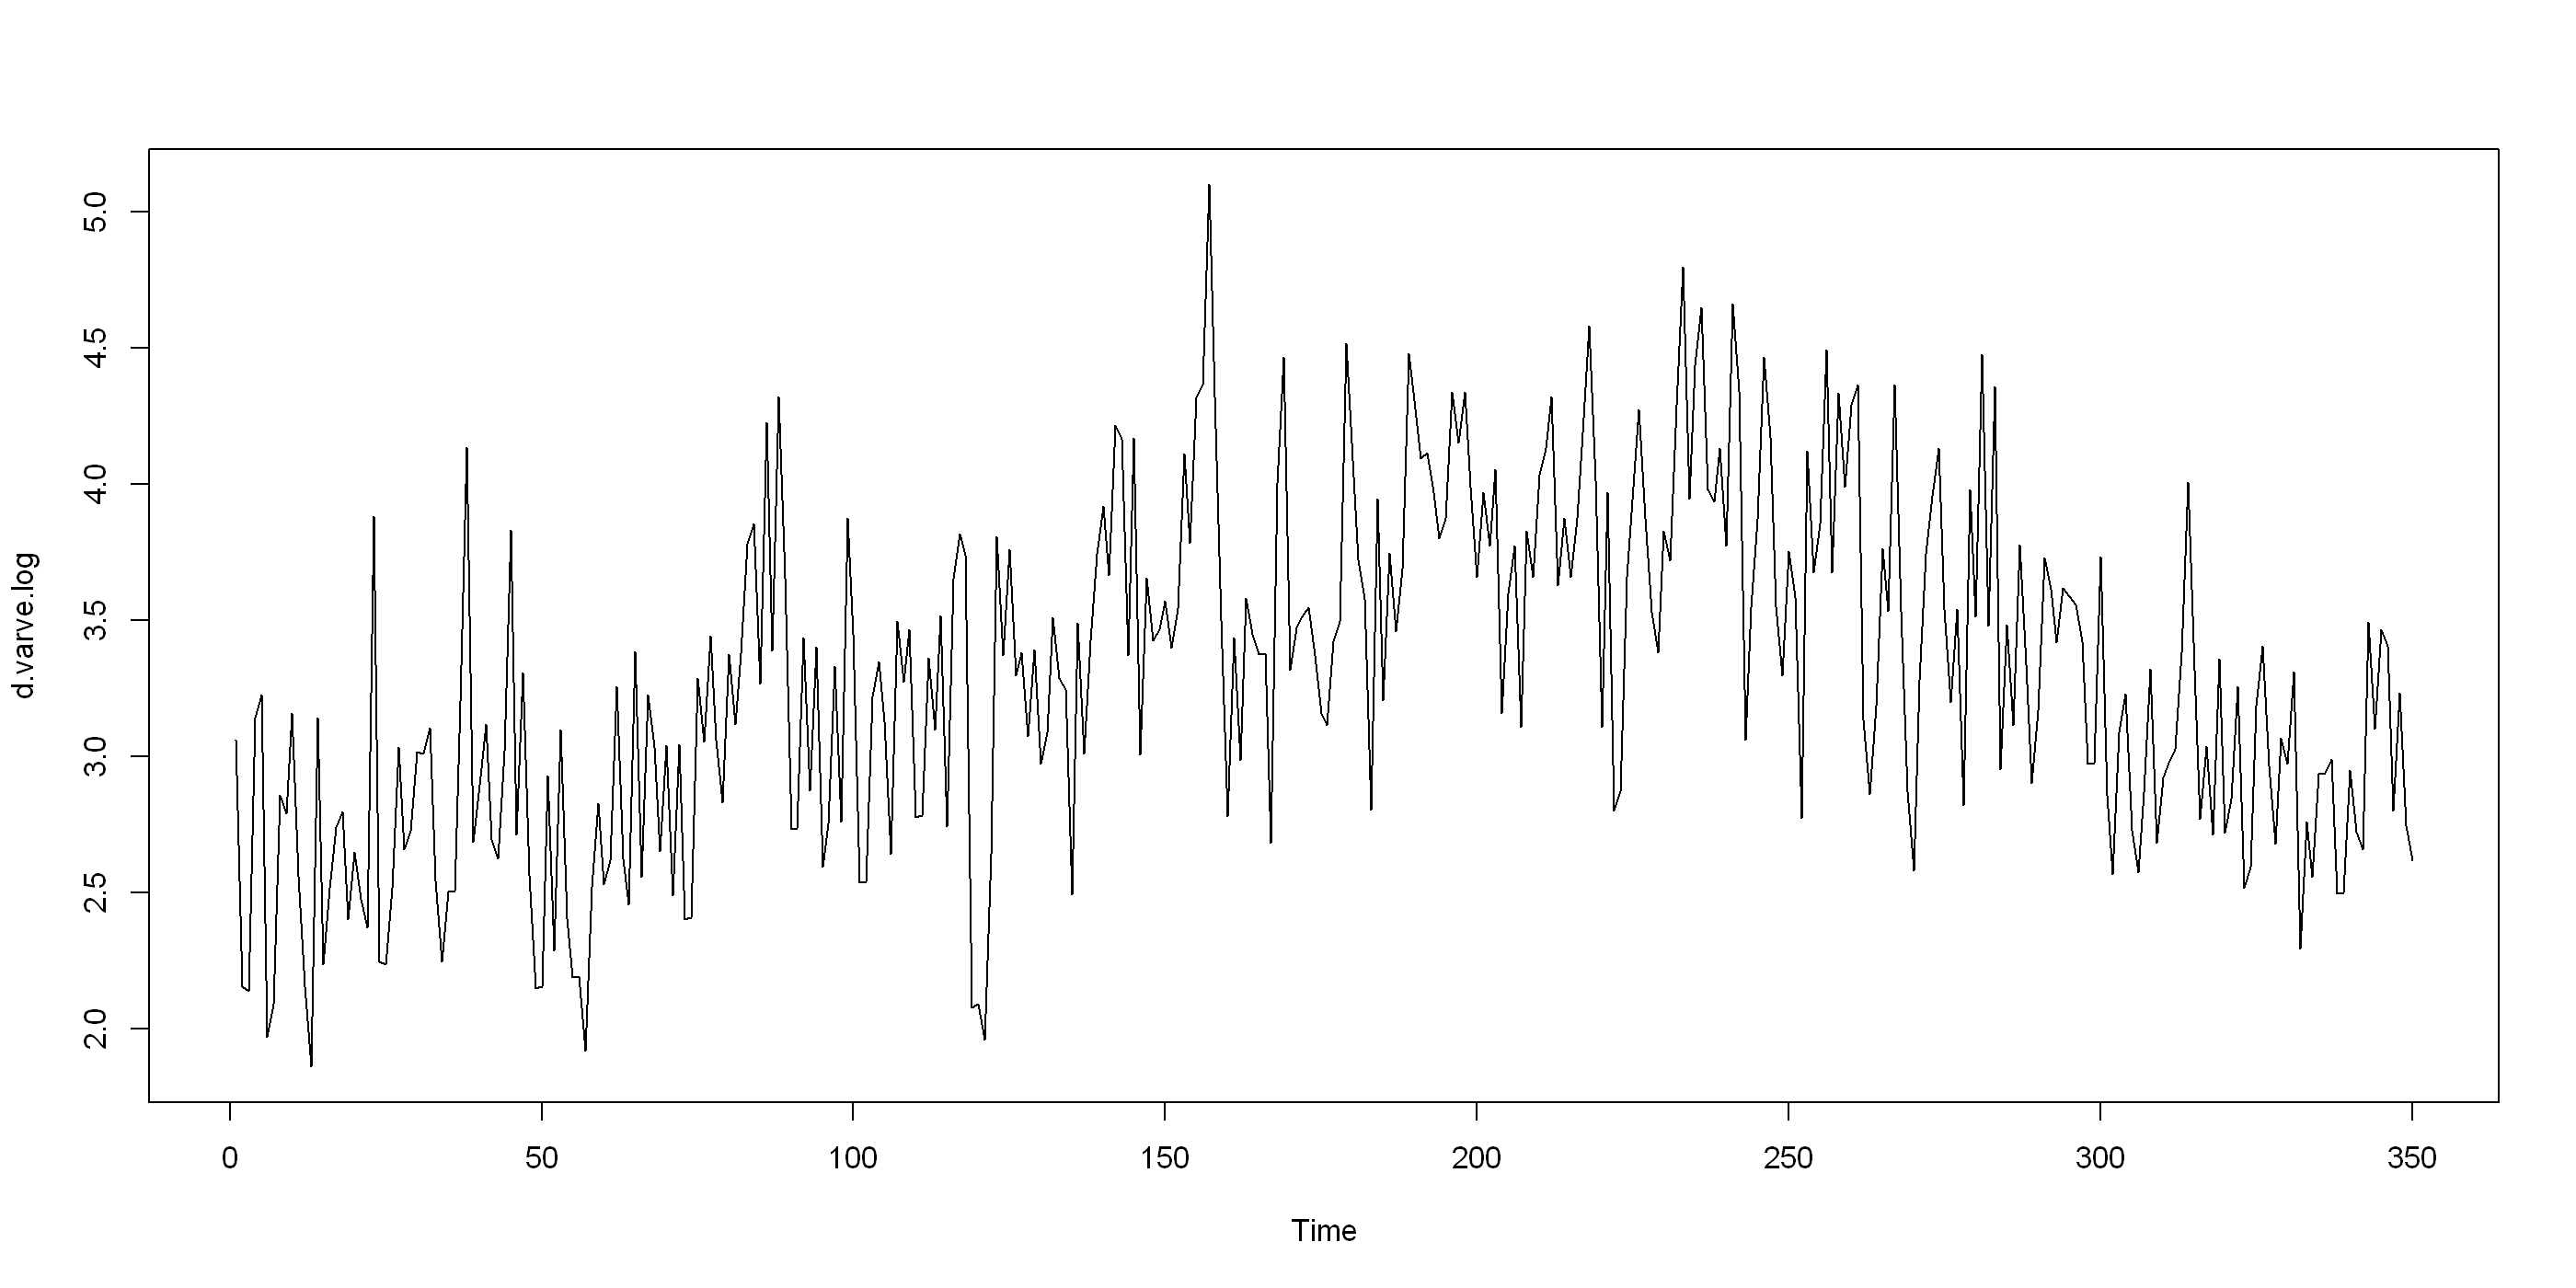

In [68]:
plot(d.varve.log)

In [69]:
d.varve.log.diff <- diff(d.varve.log)

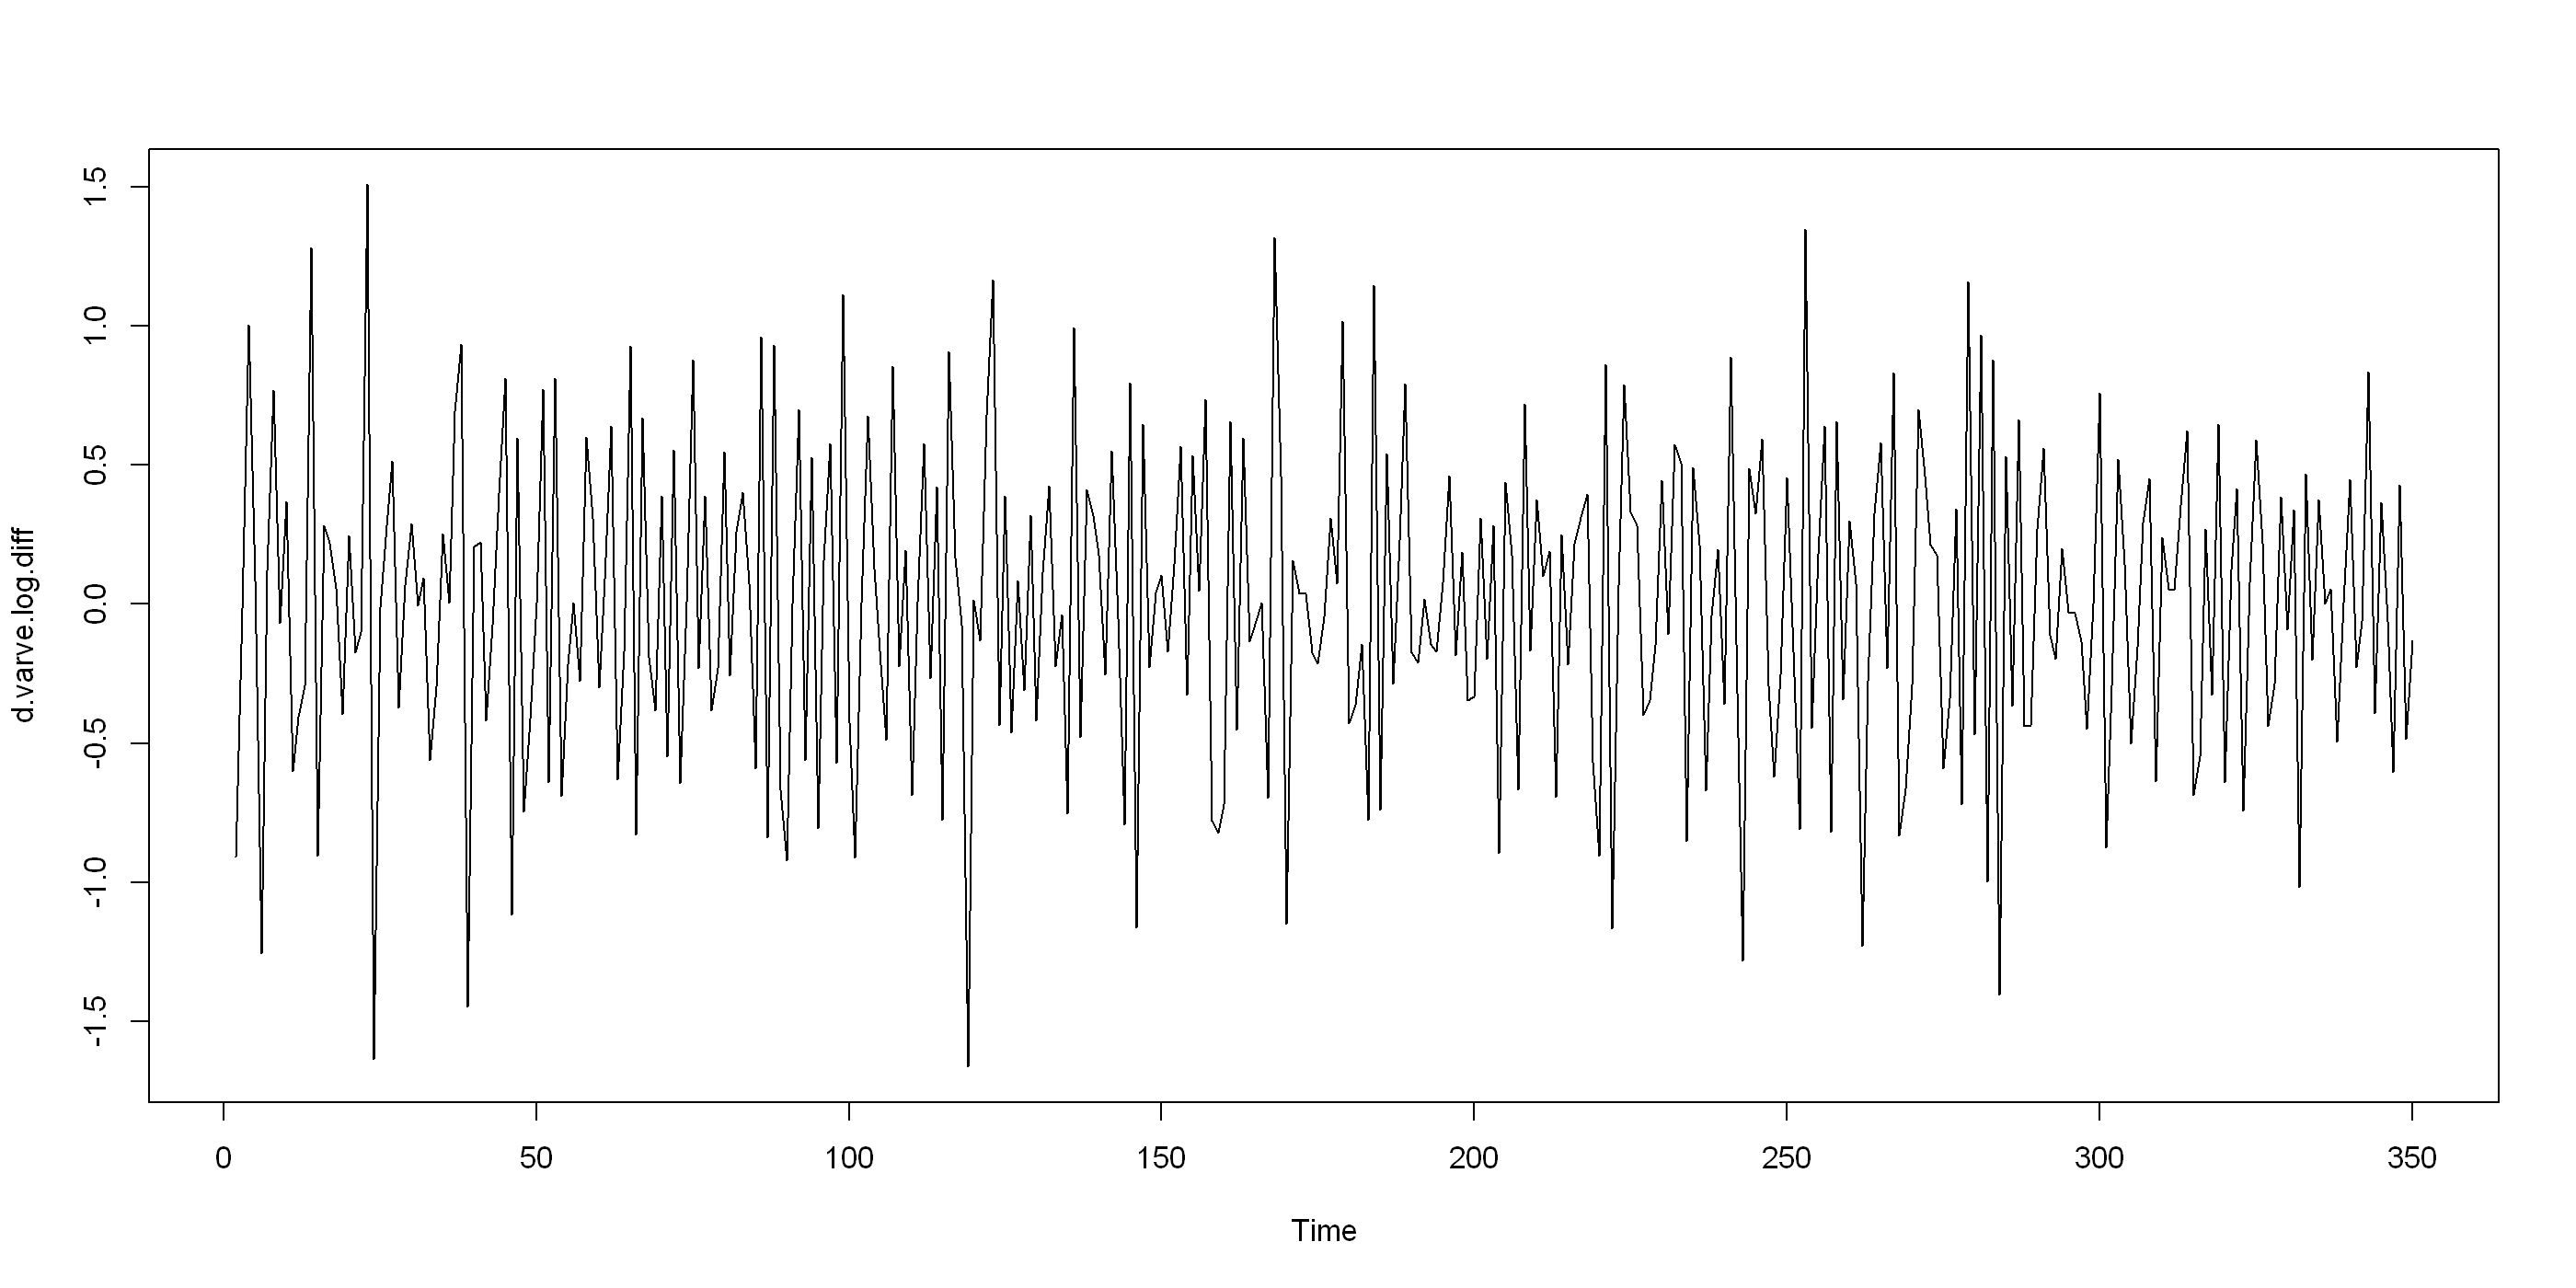

In [70]:
plot(d.varve.log.diff)

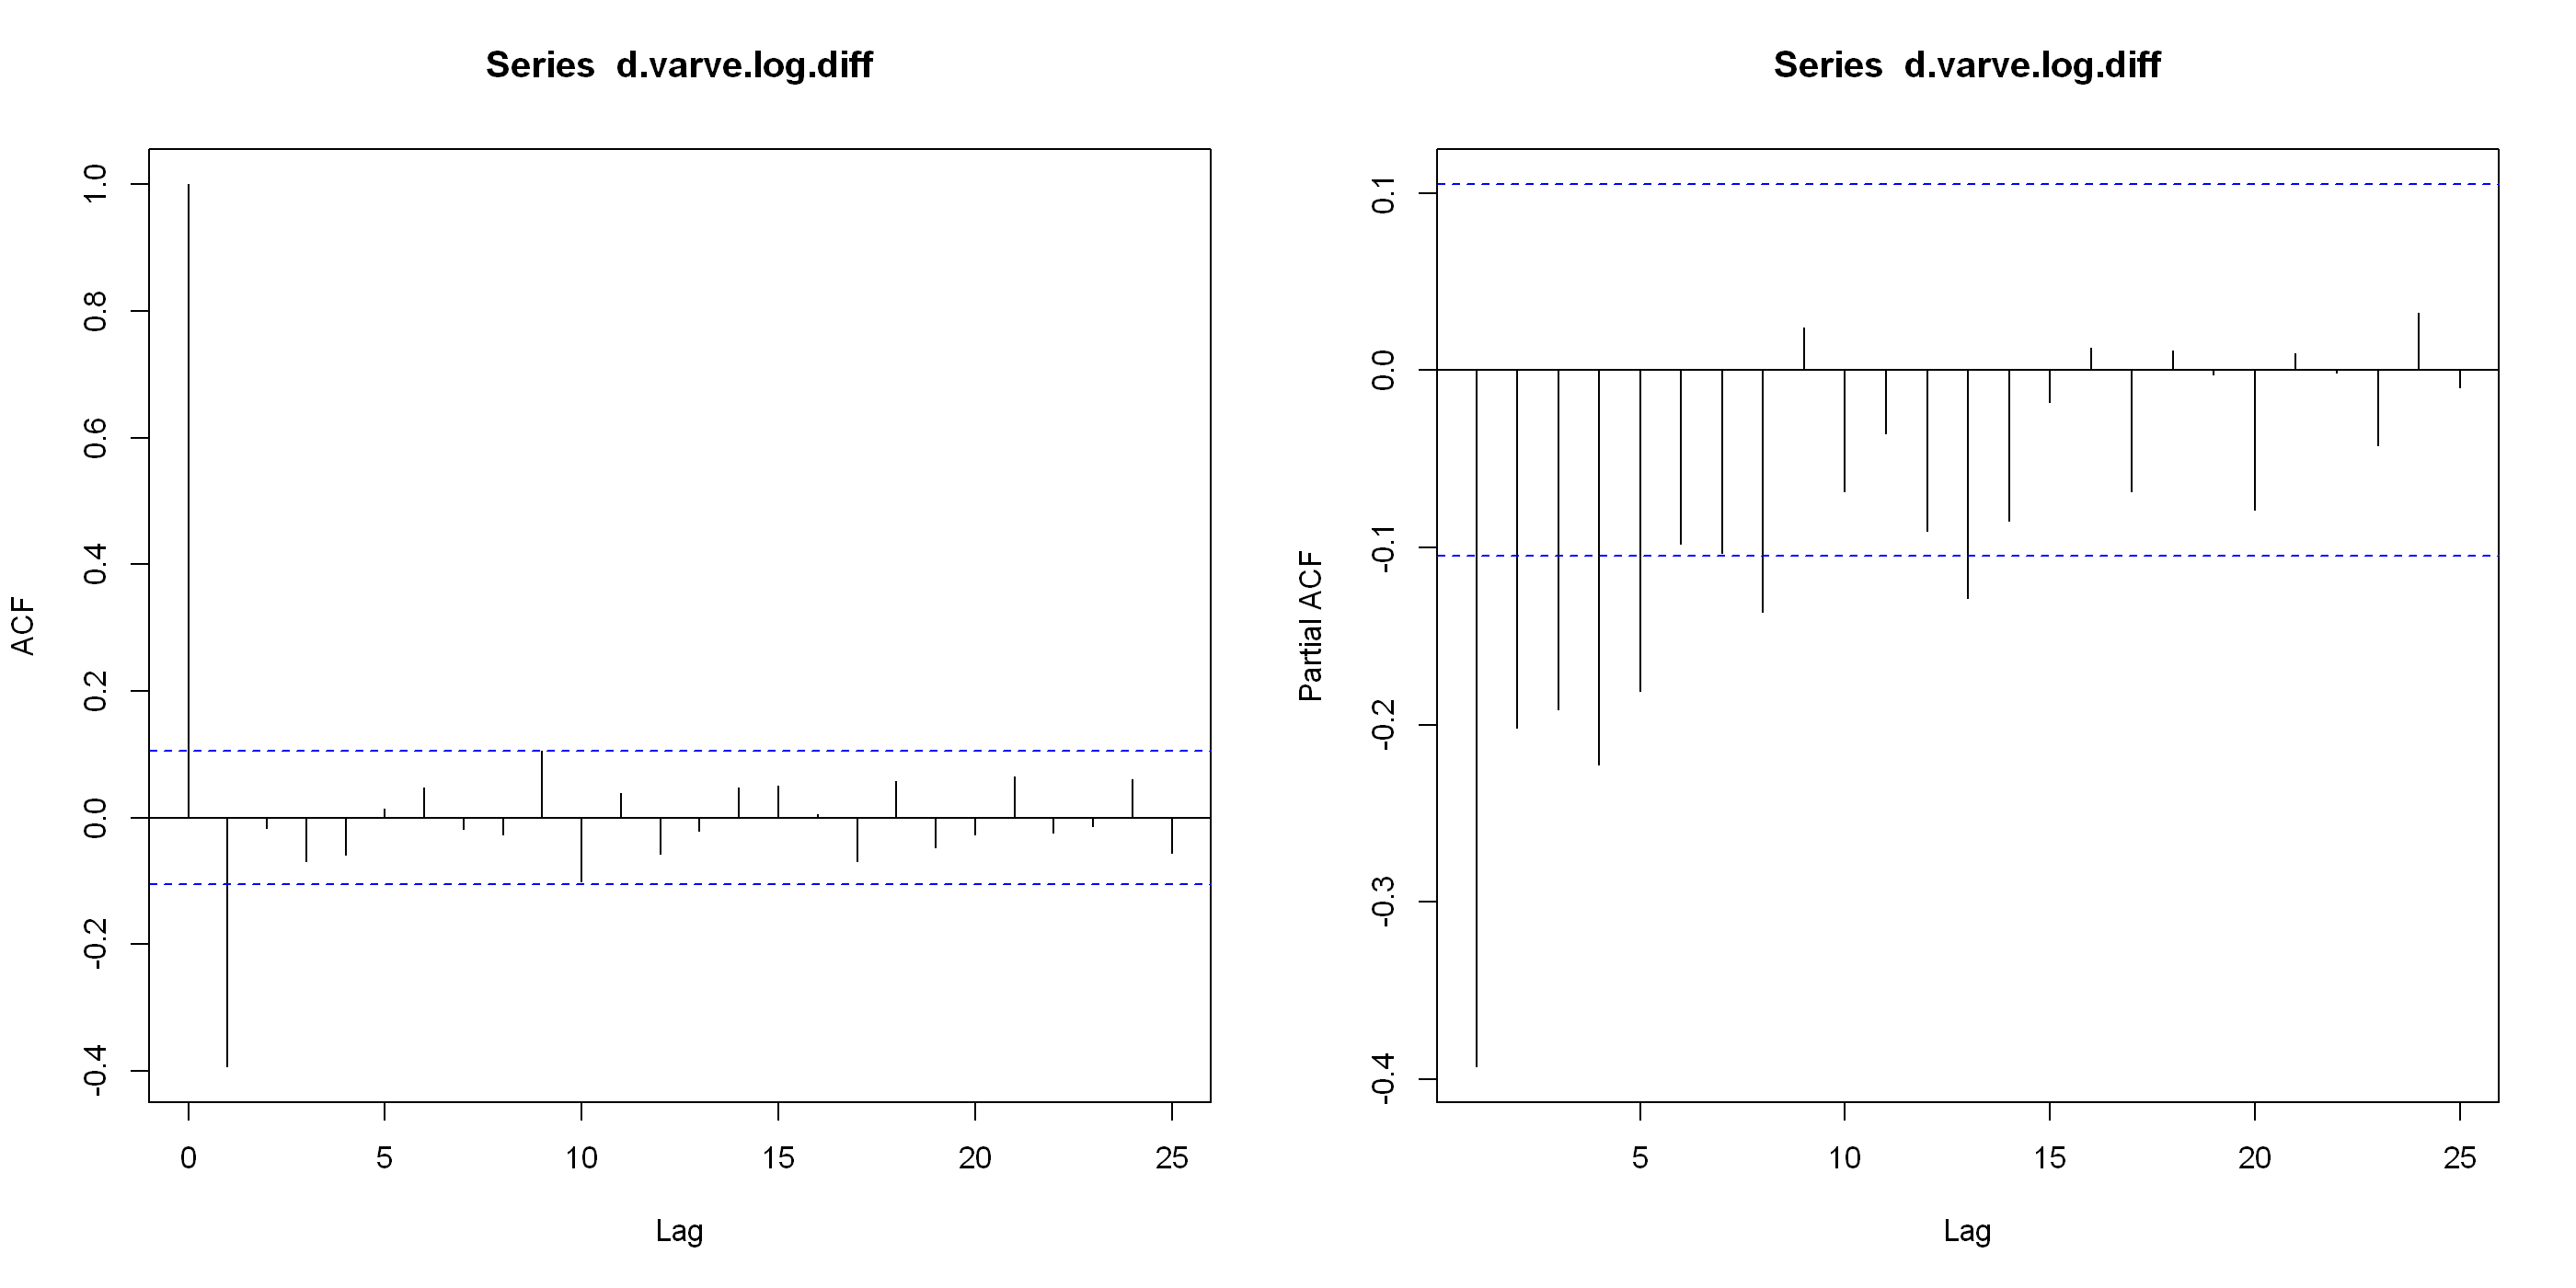

In [71]:
par(mfrow = c(1,2))
acf(d.varve.log.diff)
pacf(d.varve.log.diff)

In [72]:
fit <- auto.arima(
  sunspots.cut,
  max.p = 15,
  max.q = 10,
  max.d = 1,
  max.order = 15,
  seasonal = FALSE,
  stepwise = FALSE,
  approximation = FALSE,
  trace = TRUE
)


 ARIMA(0,1,0)                    : 264.8044
 ARIMA(0,1,0) with drift         : 266.8834
 ARIMA(0,1,1)                    : 258.3172
 ARIMA(0,1,1) with drift         : 260.4434
 ARIMA(0,1,2)                    : 260.4289
 ARIMA(0,1,2) with drift         : 262.6005
 ARIMA(0,1,3)                    : 248.5401
 ARIMA(0,1,3) with drift         : Inf
 ARIMA(0,1,4)                    : 242.9714
 ARIMA(0,1,4) with drift         : Inf
 ARIMA(0,1,5)                    : 243.6459
 ARIMA(0,1,5) with drift         : Inf
 ARIMA(0,1,6)                    : 245.5785
 ARIMA(0,1,6) with drift         : Inf
 ARIMA(0,1,7)                    : 234.1822
 ARIMA(0,1,7) with drift         : Inf
 ARIMA(0,1,8)                    : 236.3516
 ARIMA(0,1,8) with drift         : Inf
 ARIMA(0,1,9)                    : 238.6971
 ARIMA(0,1,9) with drift         : Inf
 ARIMA(0,1,10)                    : Inf
 ARIMA(0,1,10) with drift         : Inf
 ARIMA(1,1,0)                    : 259.0894
 ARIMA(1,1,0) with drift      

In [73]:
model <- arima(d.varve.log,order = c(1,1,1))

In [74]:
summary(model)


Call:
arima(x = d.varve.log, order = c(1, 1, 1))

Coefficients:
         ar1      ma1
      0.2461  -0.9140
s.e.  0.0590   0.0234

sigma^2 estimated as 0.2138:  log likelihood = -226.65,  aic = 459.3

Training set error measures:
                      ME      RMSE      MAE       MPE     MAPE      MASE
Training set 0.006059001 0.4616814 0.367778 -1.751849 11.66957 0.8126875
                     ACF1
Training set -0.007303981

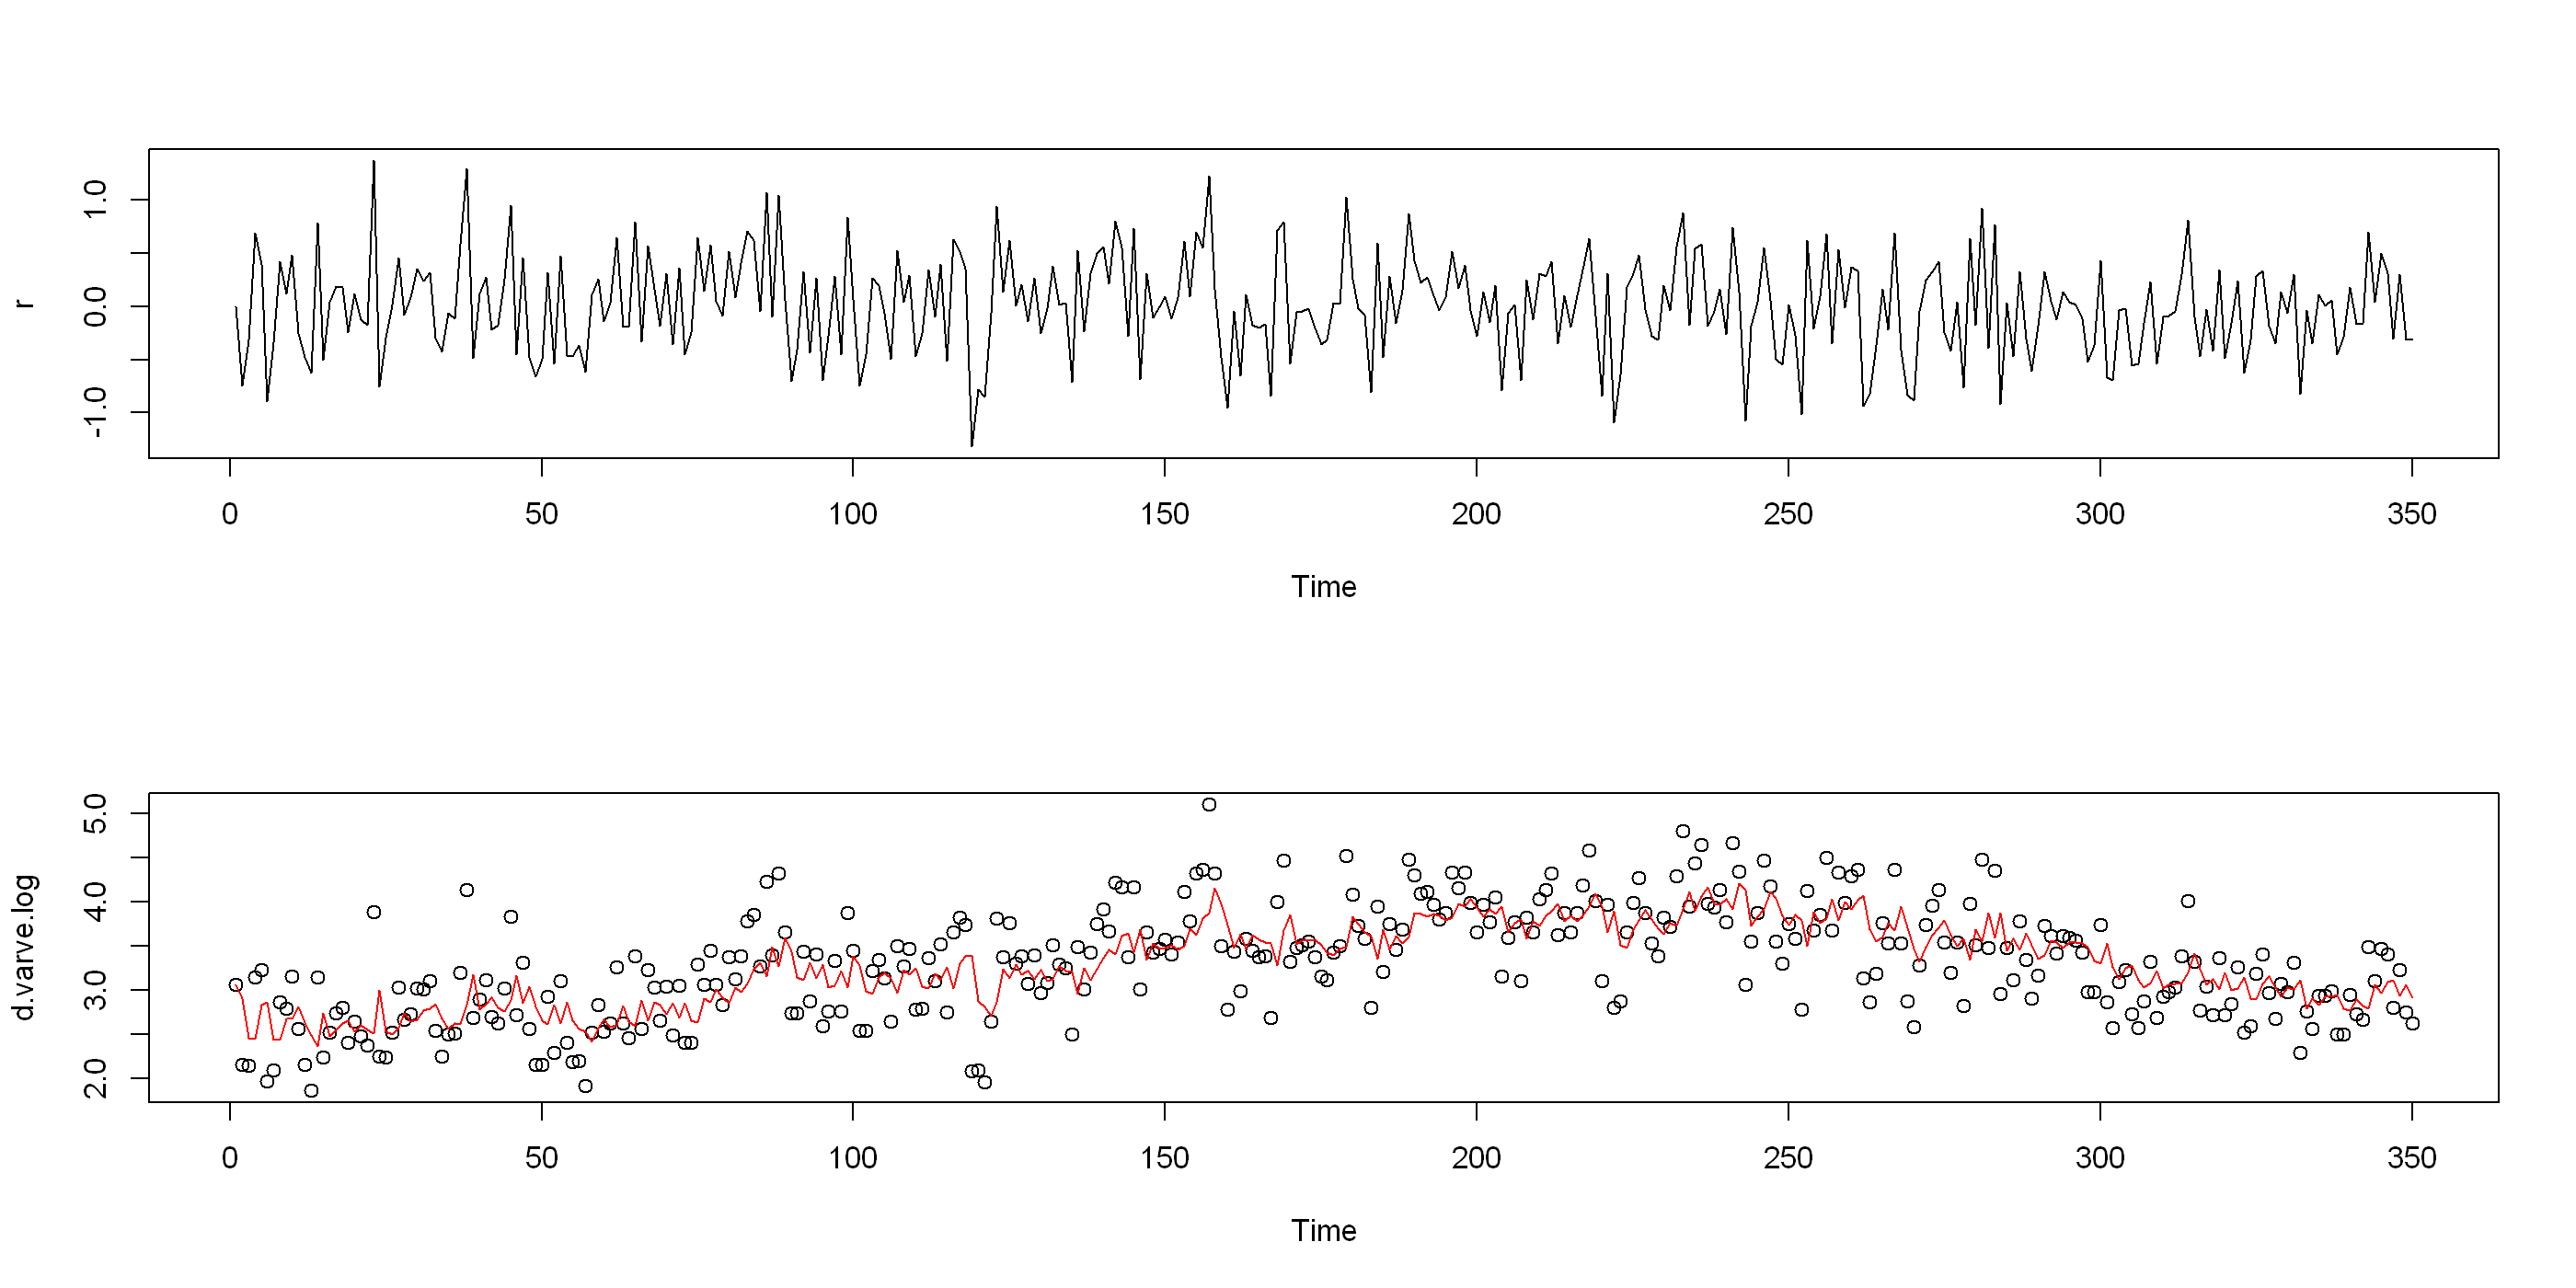

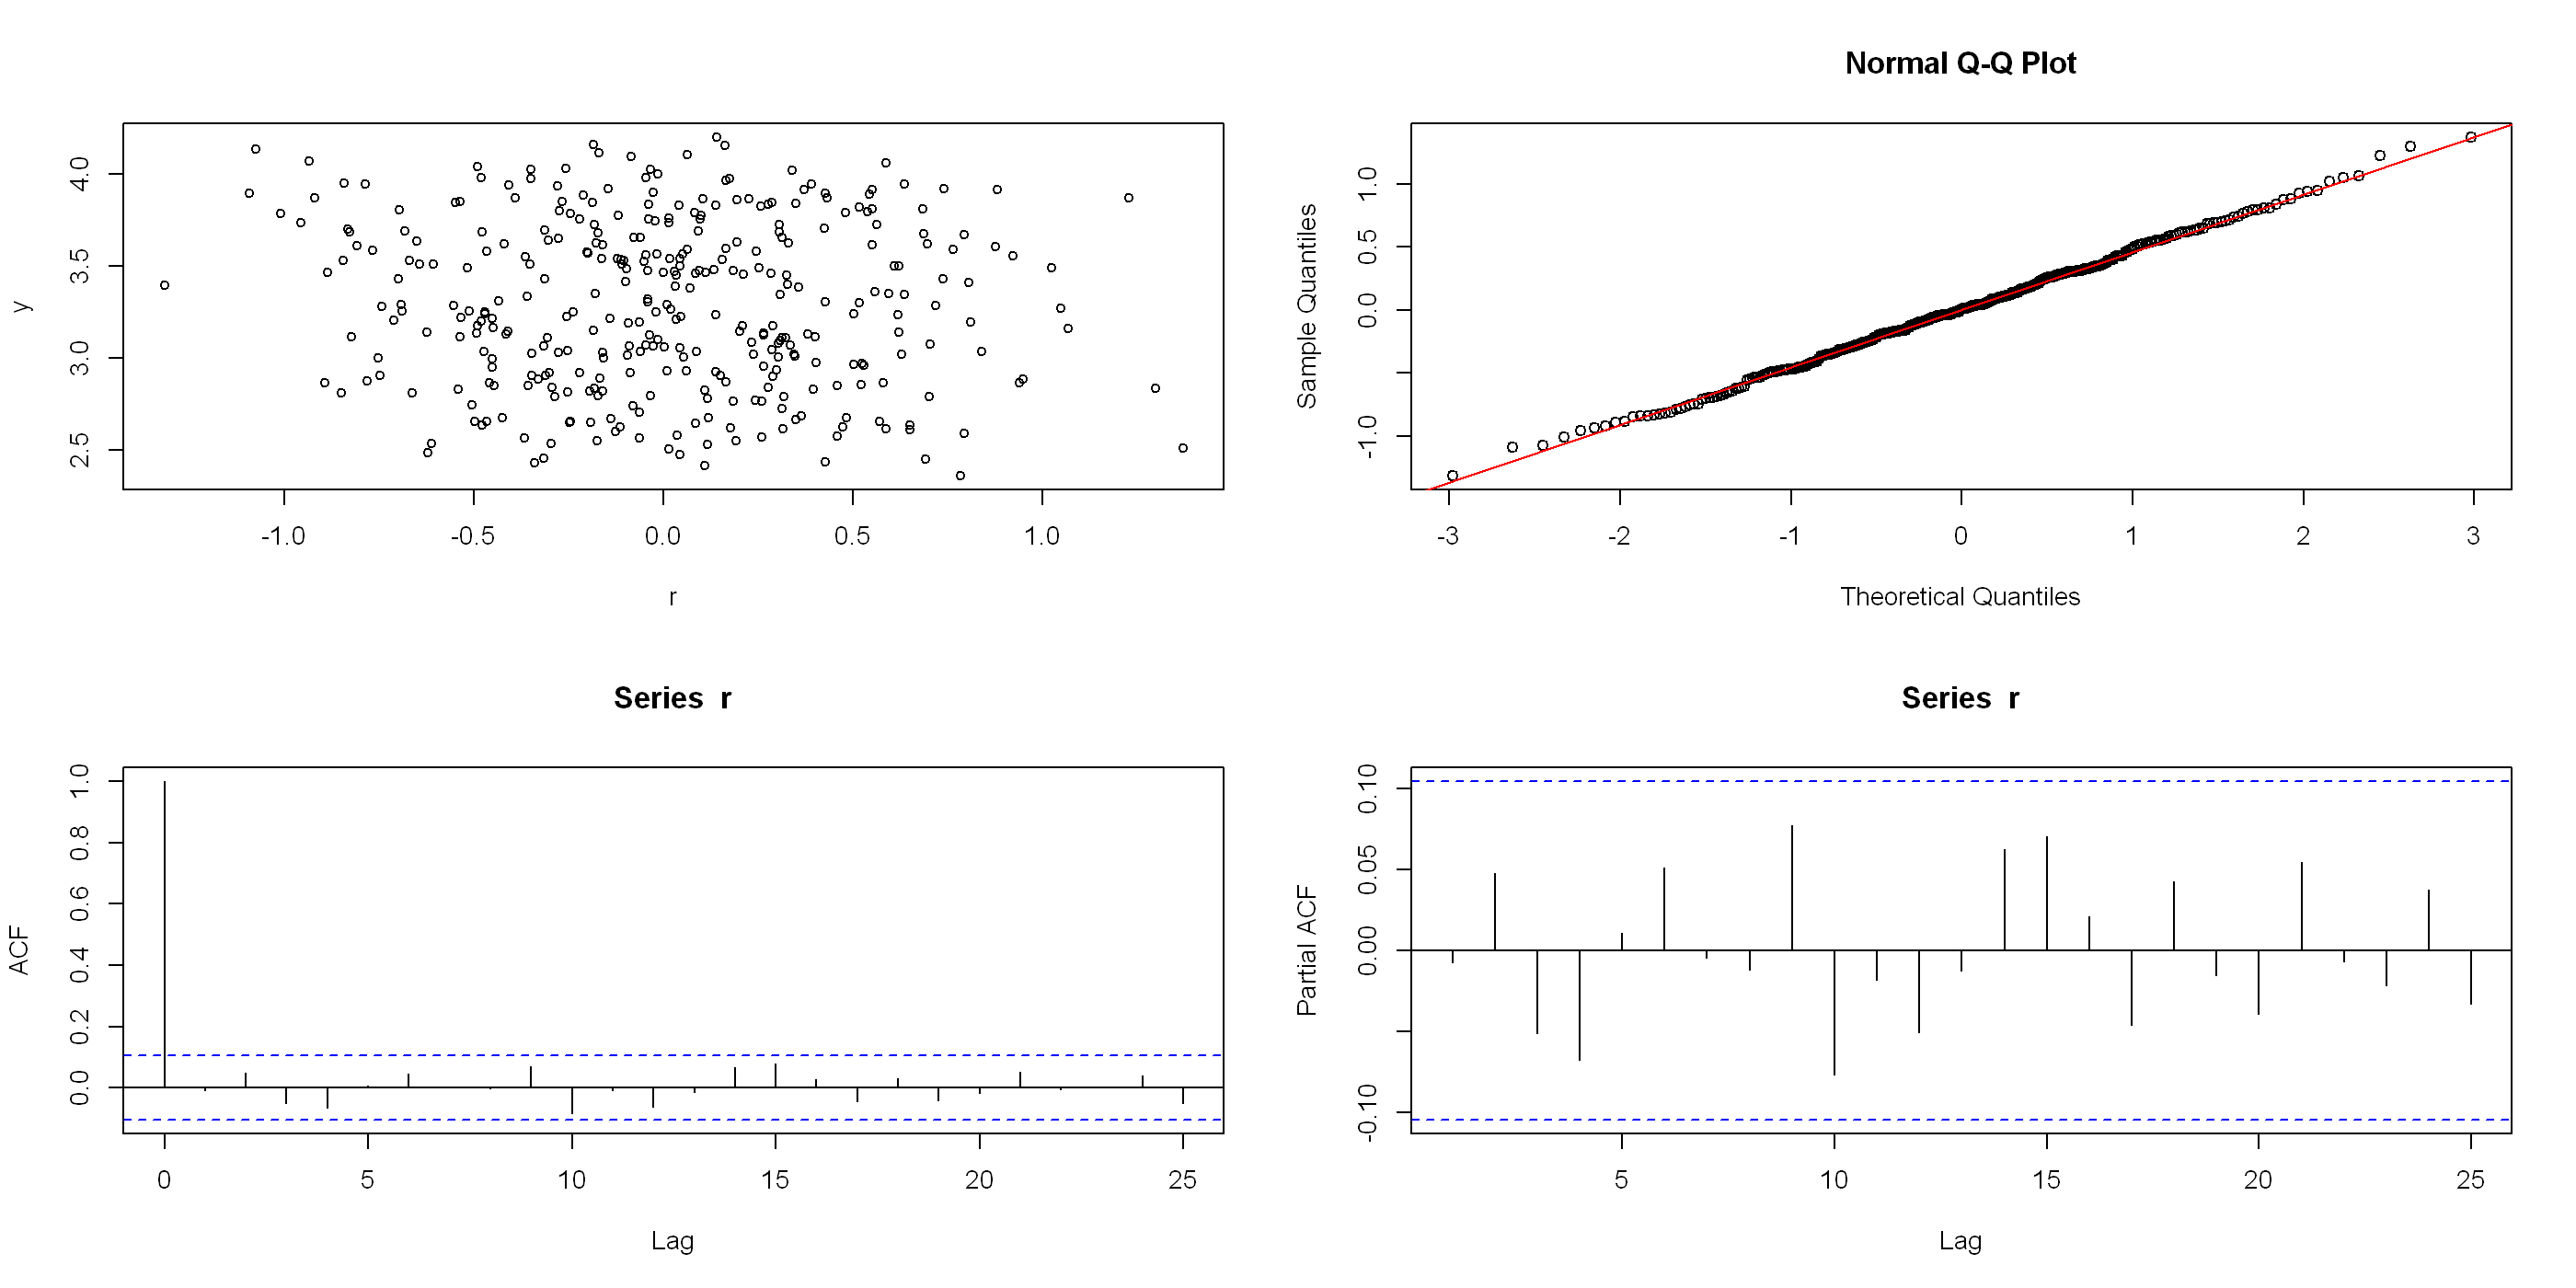

In [75]:
r <- na.omit(model$residuals)
y <- d.varve.log-r
par(mfrow = c(2,1))
plot(r,type="l")
plot(d.varve.log,type="p")
lines(y,col="red")
par(mfrow = c(2,2))

plot(r,y,type="p",xy.labels = FALSE, xy.lines = FALSE)
qqnorm(r)
qqline(r,col="red")
acf(r)
pacf(r)


In [76]:
d.varve_n <- log(ts(scan(t.url)[550:580],start = 350))


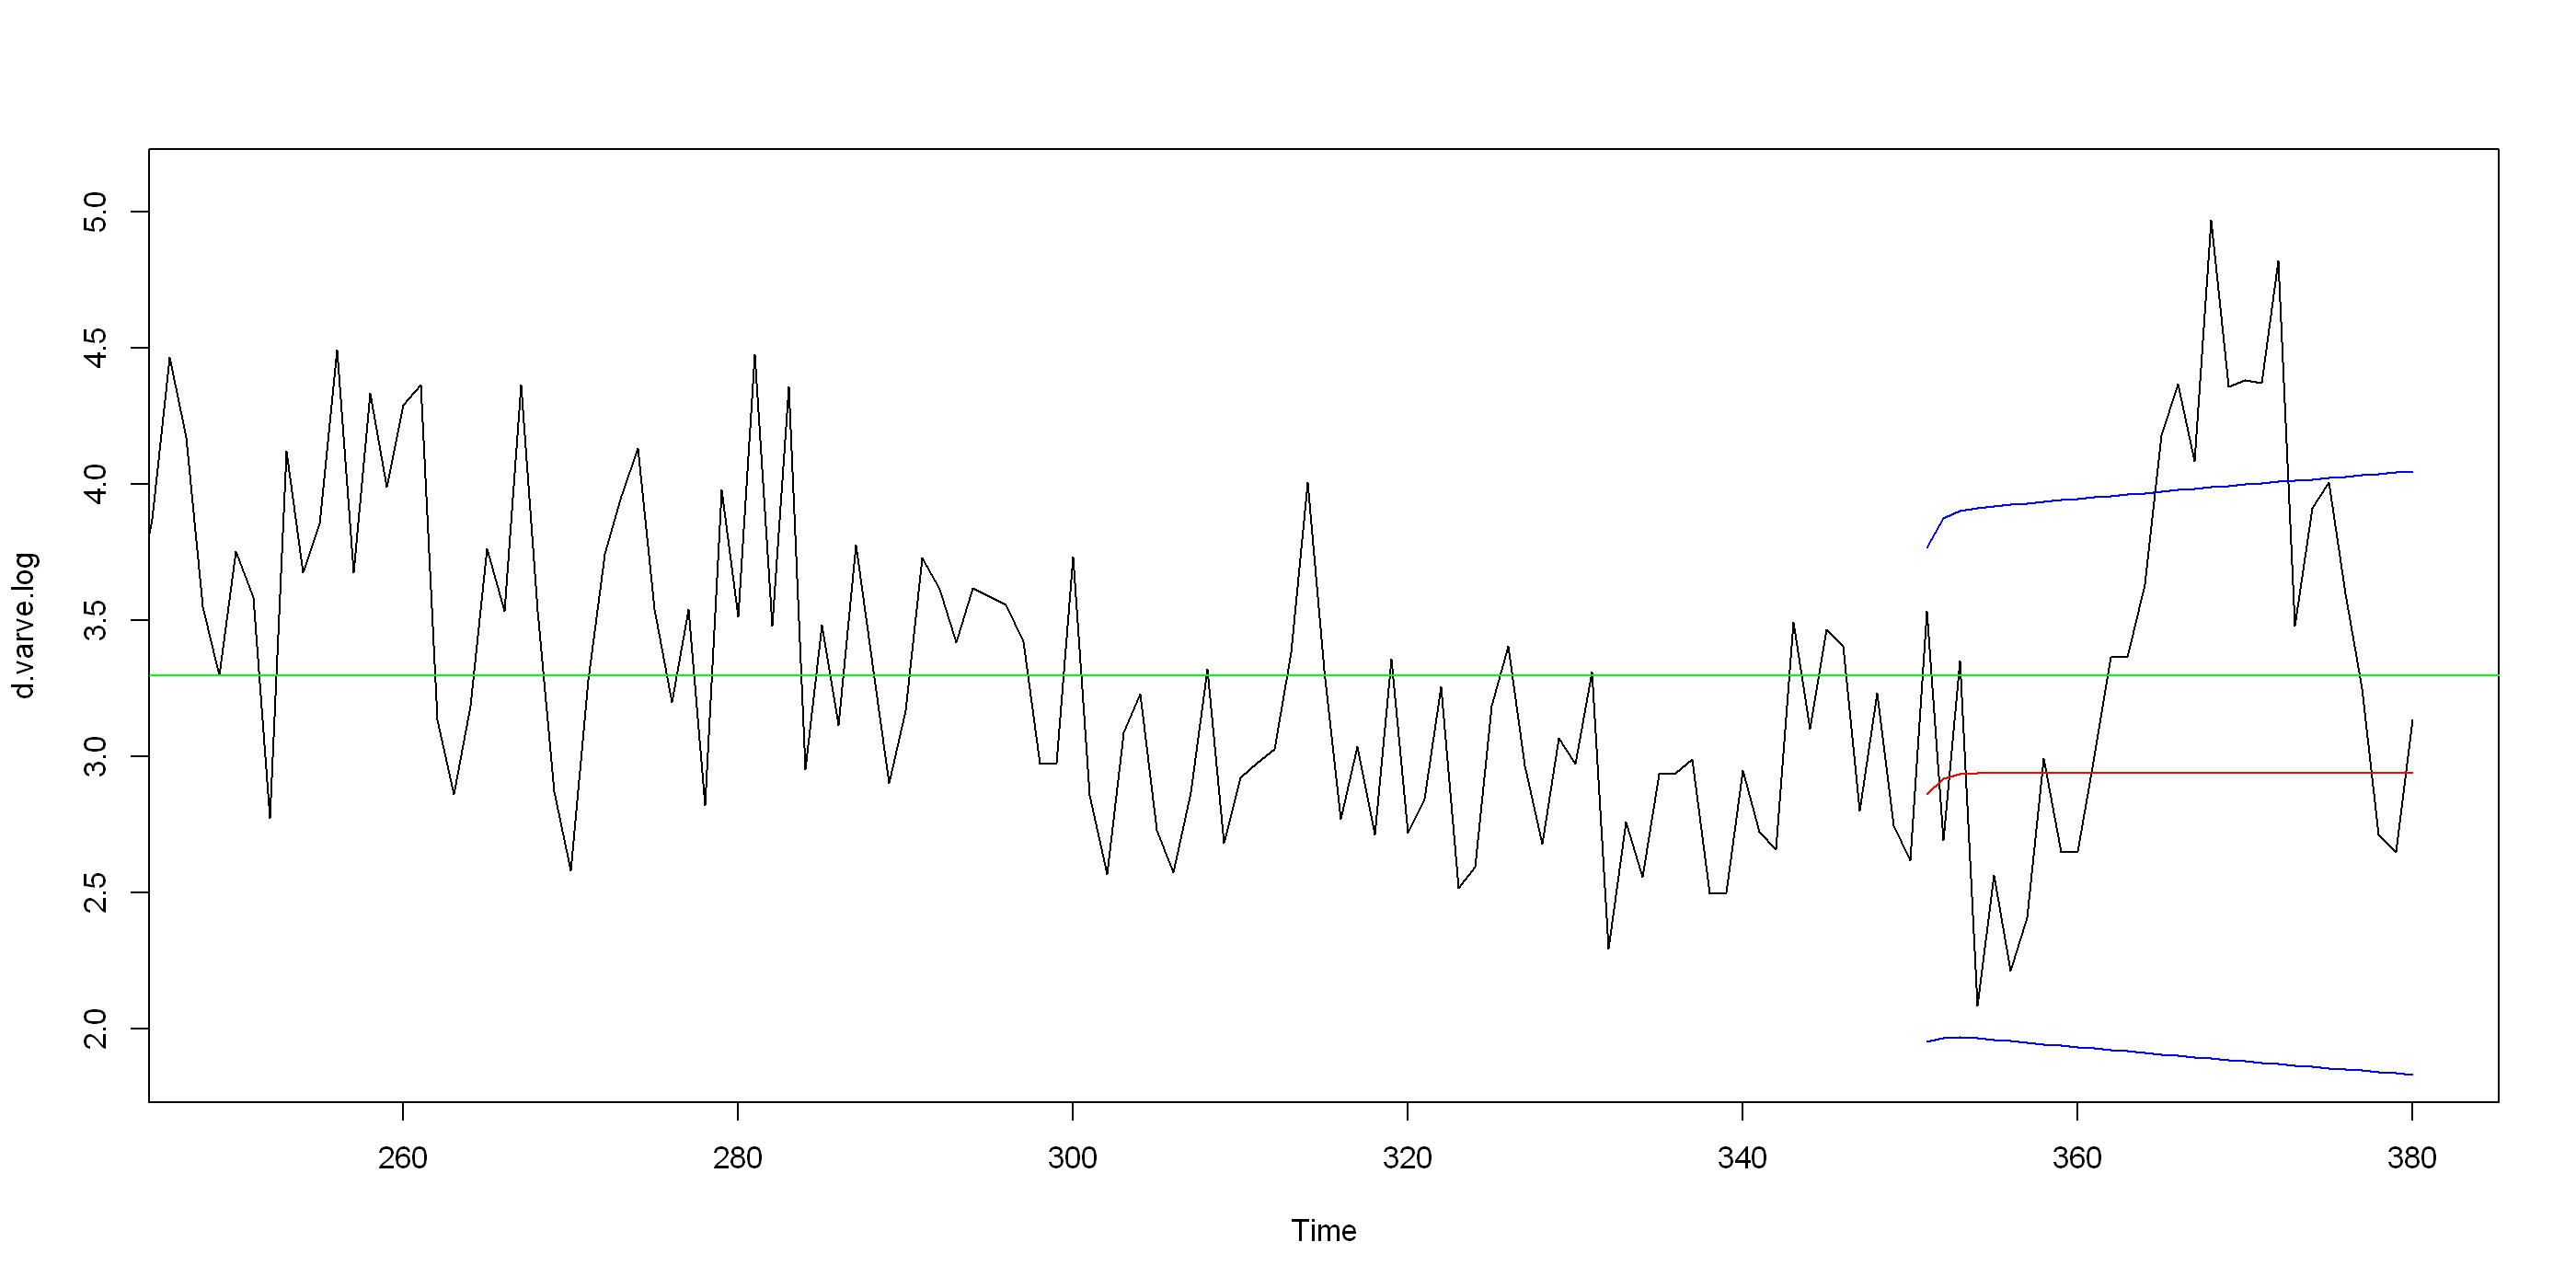

In [77]:
y_hat <- predict(model,n.ahead=30)
CI <- qnorm(0.975)*y_hat$se
plot(d.varve.log,xlim=c(250,380))
lines(d.varve_n)
abline(h=mean(d.varve.log),col="green")
lines(y_hat$pred+CI,col="blue")
lines(y_hat$pred-CI,col="blue")

lines(y_hat$pred,col="red")

In [78]:
model <- arima(d.varve.log.diff,order = c(1,0,1))

In [79]:
summary(model)


Call:
arima(x = d.varve.log.diff, order = c(1, 0, 1))

Coefficients:
         ar1      ma1  intercept
      0.2463  -0.9145     0.0009
s.e.  0.0590   0.0234     0.0029

sigma^2 estimated as 0.2137:  log likelihood = -226.6,  aic = 461.2

Training set error measures:
                       ME      RMSE       MAE       MPE     MAPE      MASE
Training set -0.001721056 0.4622711 0.3687881 -202.8806 407.2031 0.4844537
                     ACF1
Training set -0.007031365

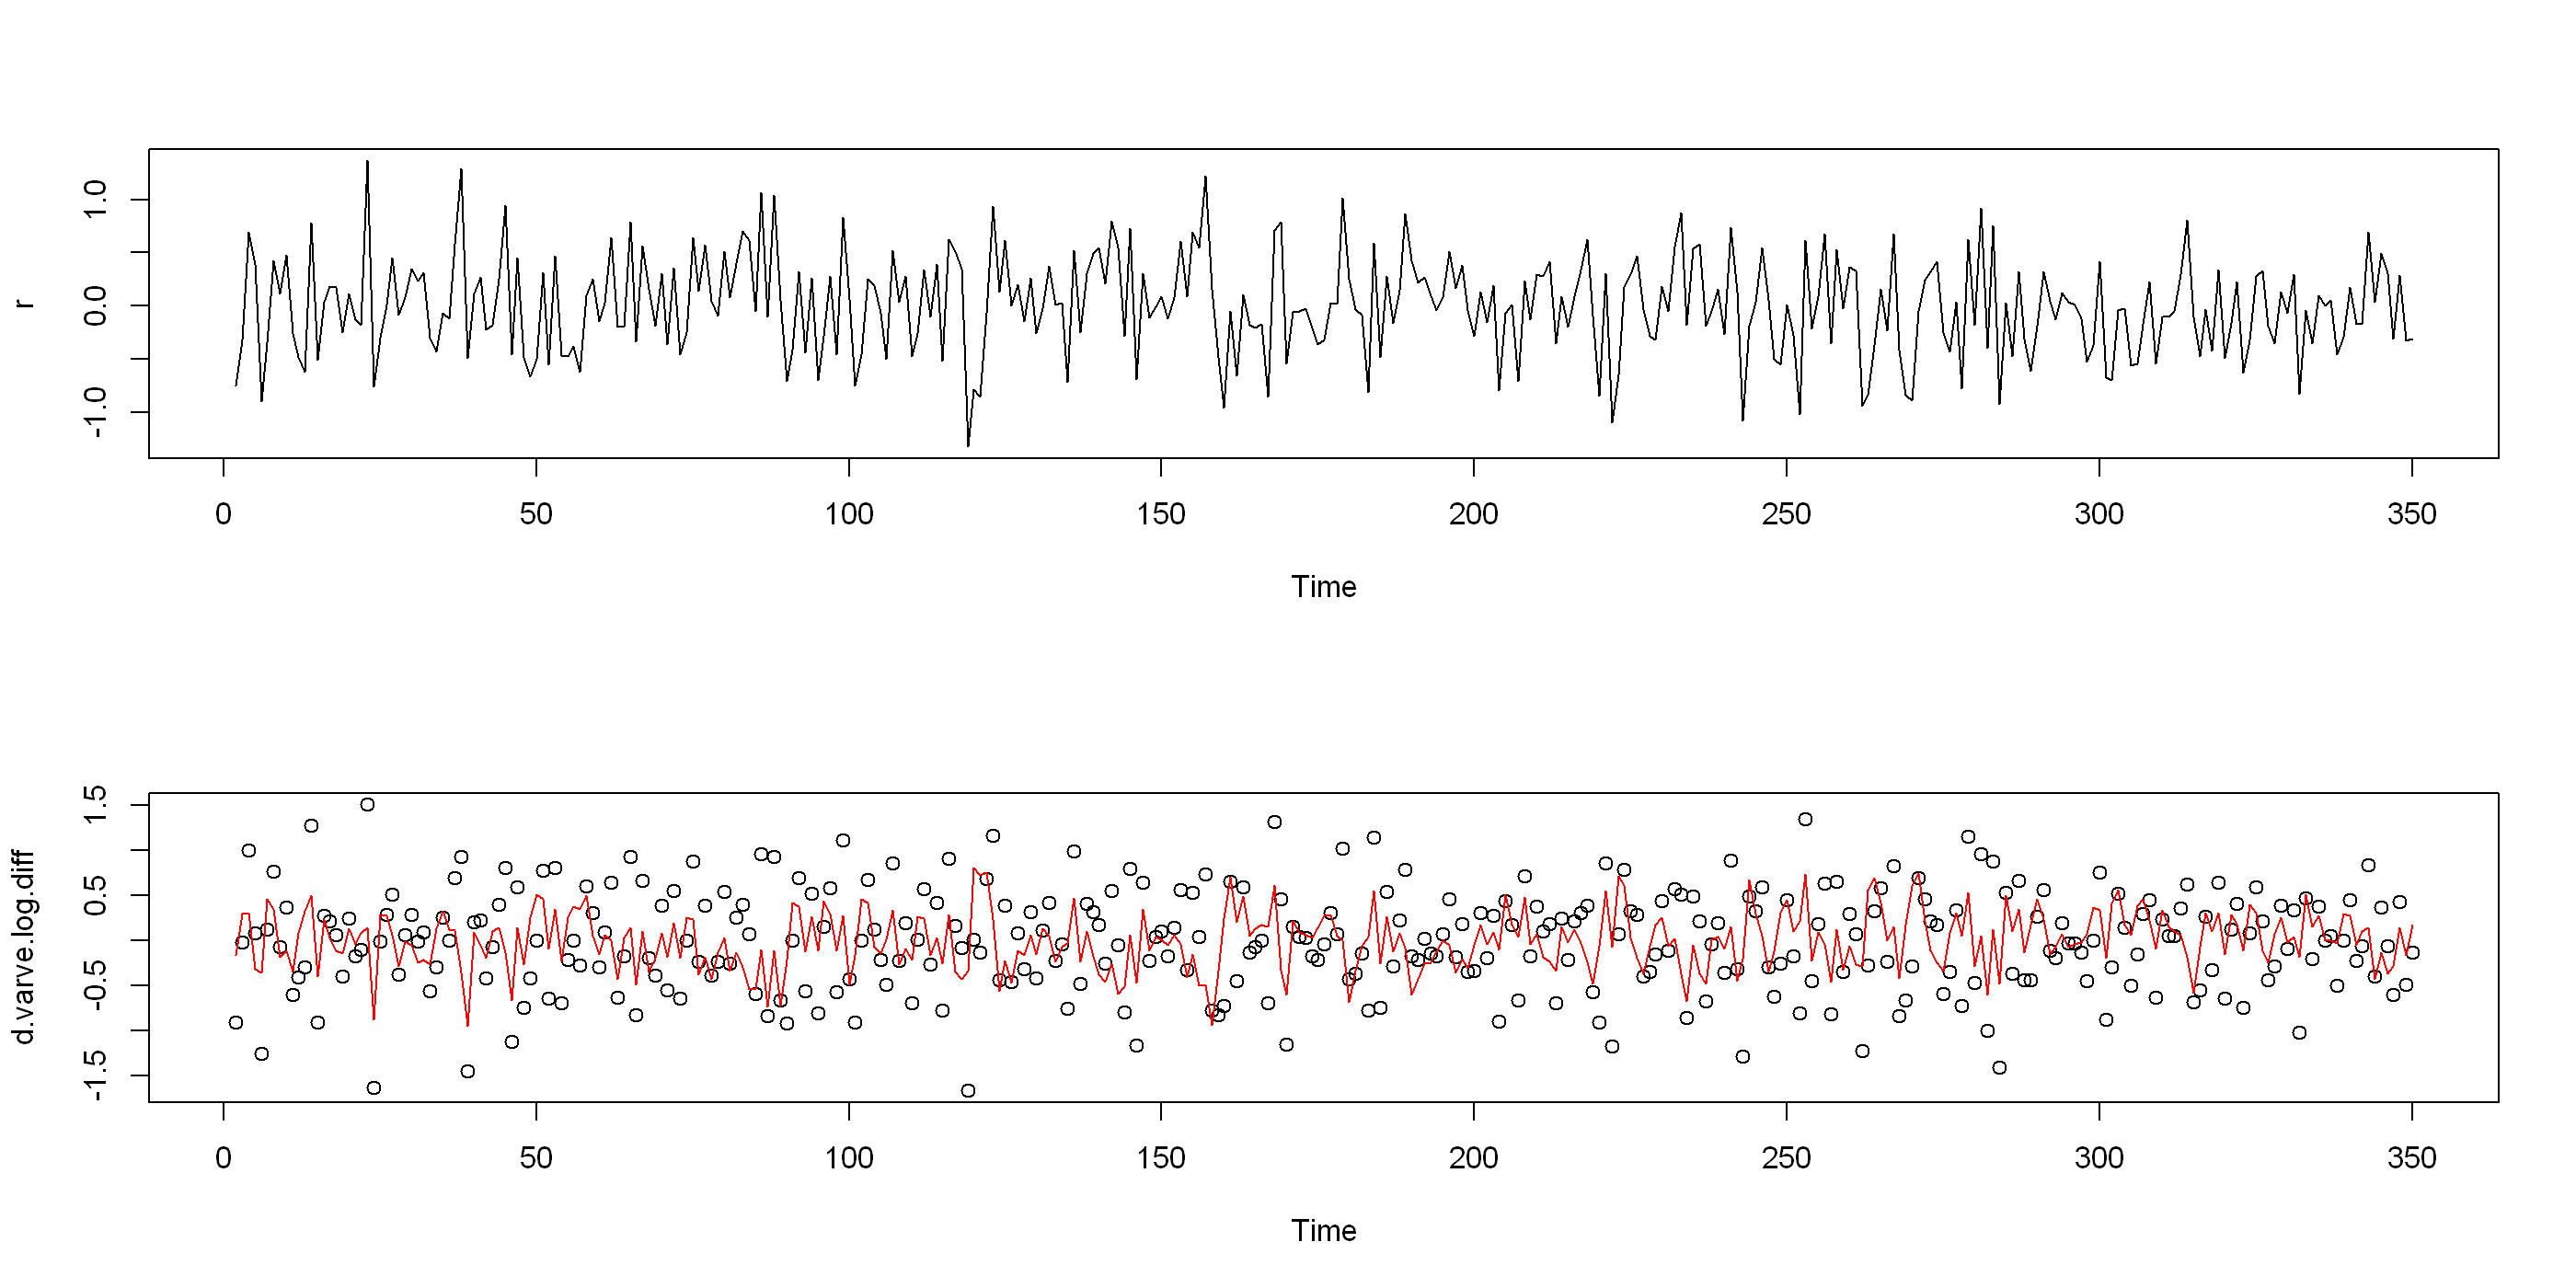

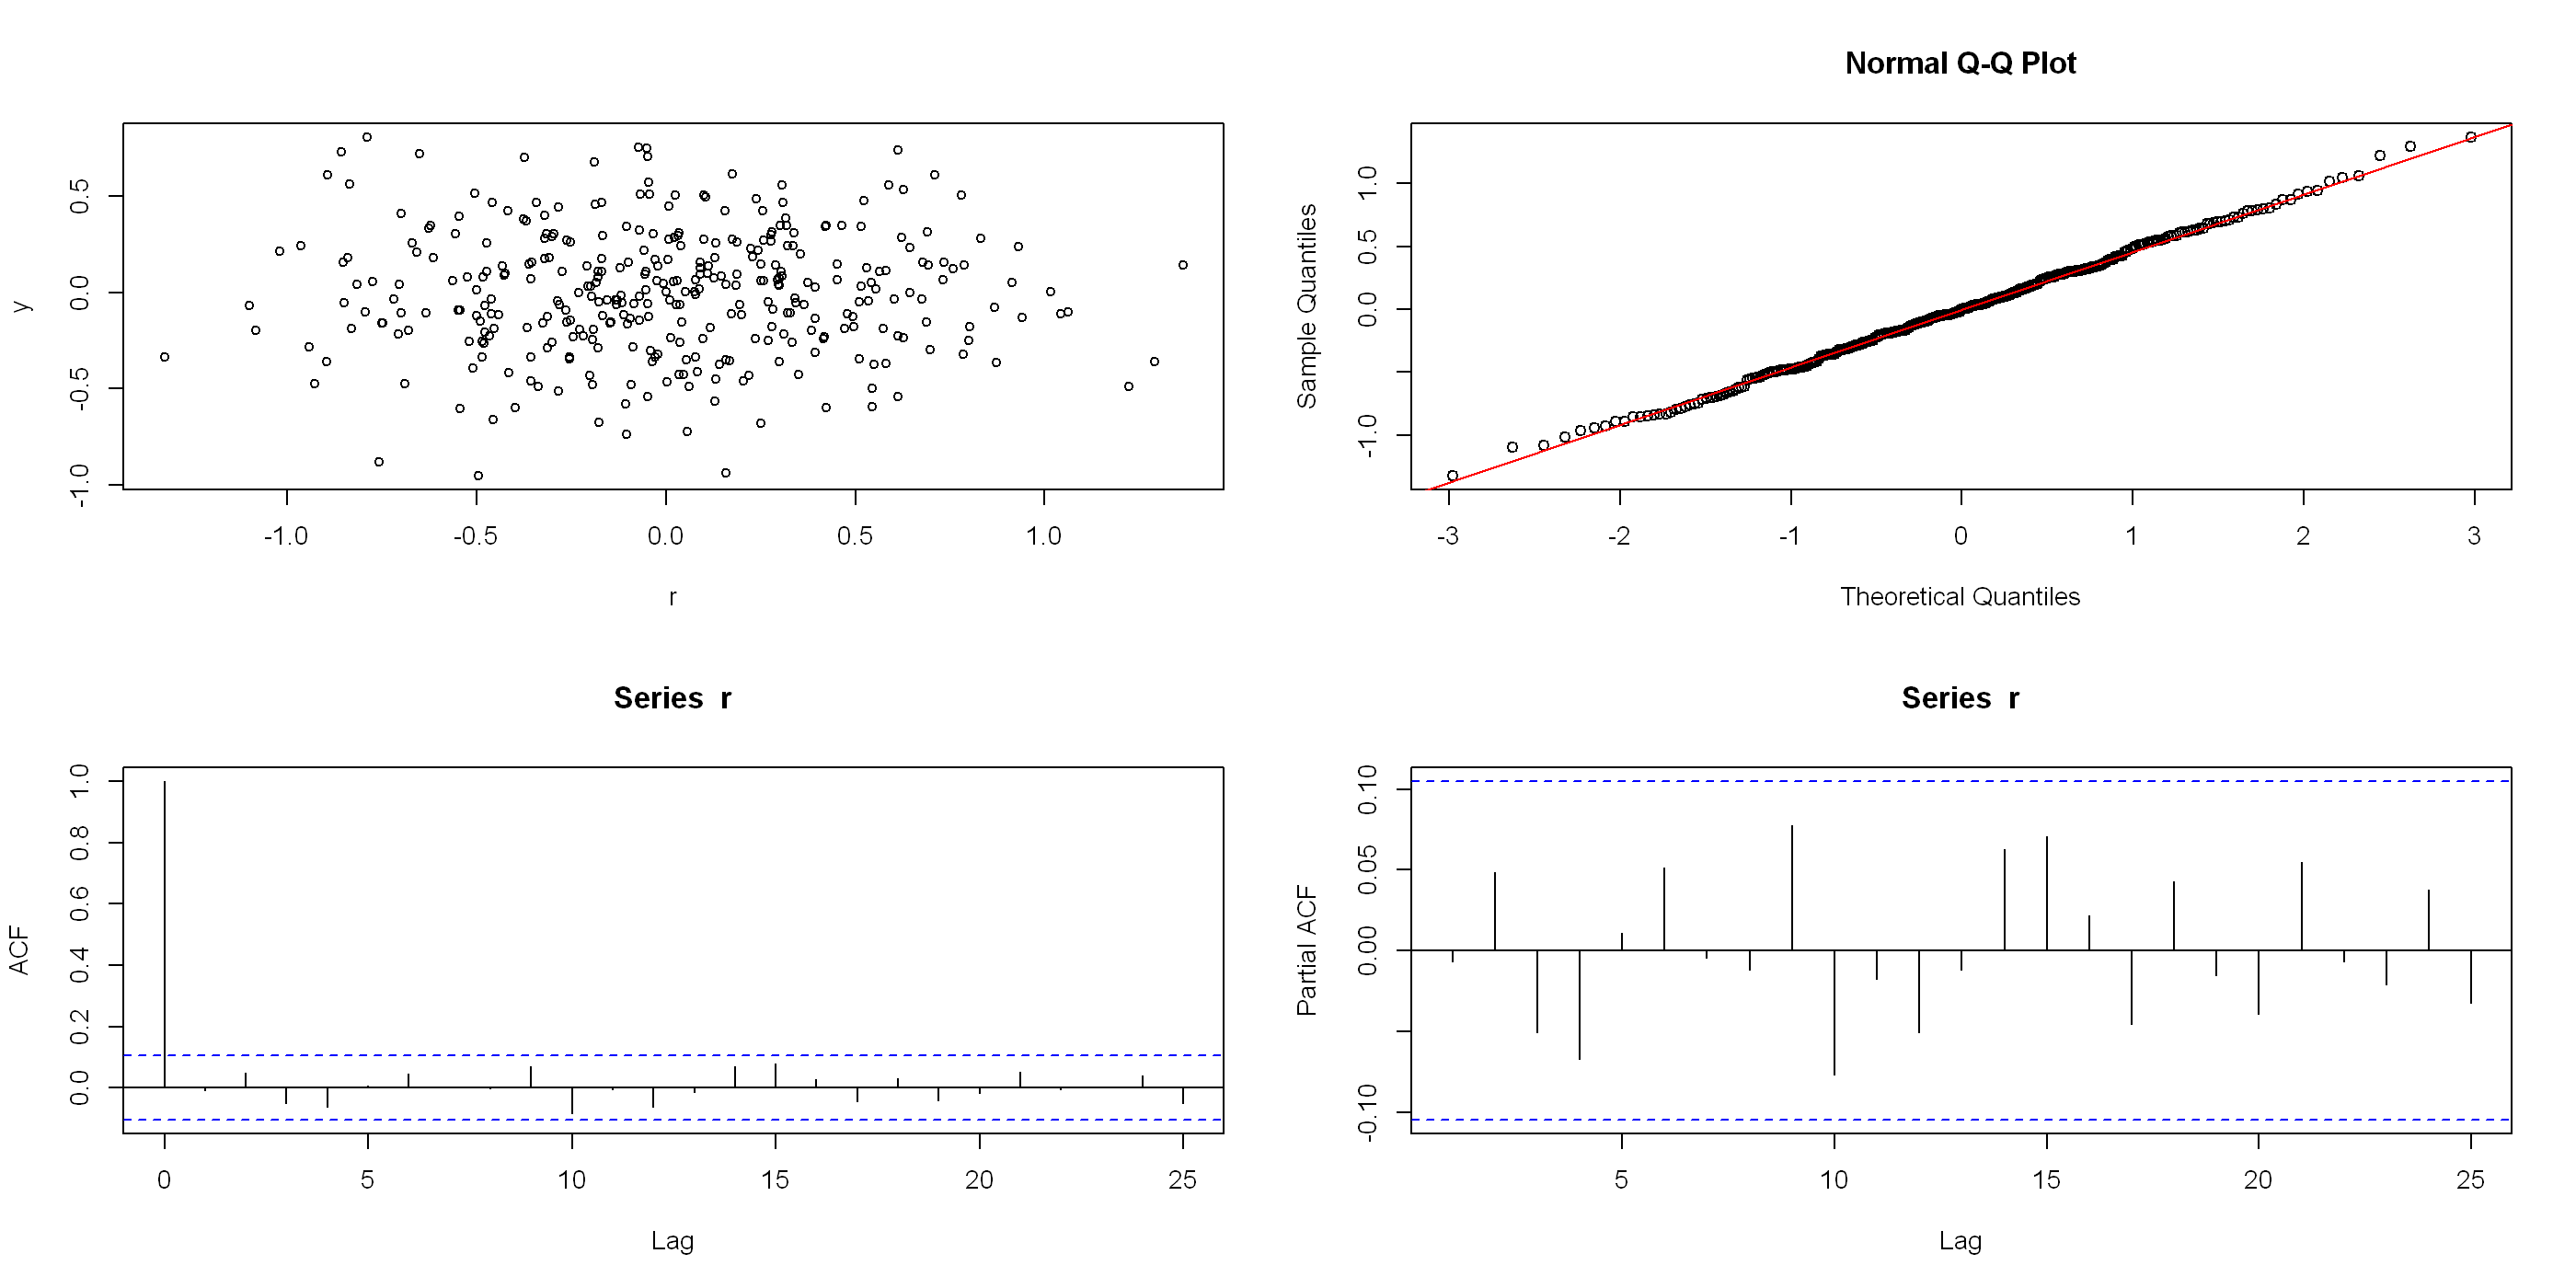

In [80]:
r <- na.omit(model$residuals)
y <- d.varve.log.diff-r
par(mfrow = c(2,1))
plot(r,type="l")
plot(d.varve.log.diff,type="p")
lines(y,col="red")
par(mfrow = c(2,2))

plot(r,y,type="p",xy.labels = FALSE, xy.lines = FALSE)
qqnorm(r)
qqline(r,col="red")
acf(r)
pacf(r)


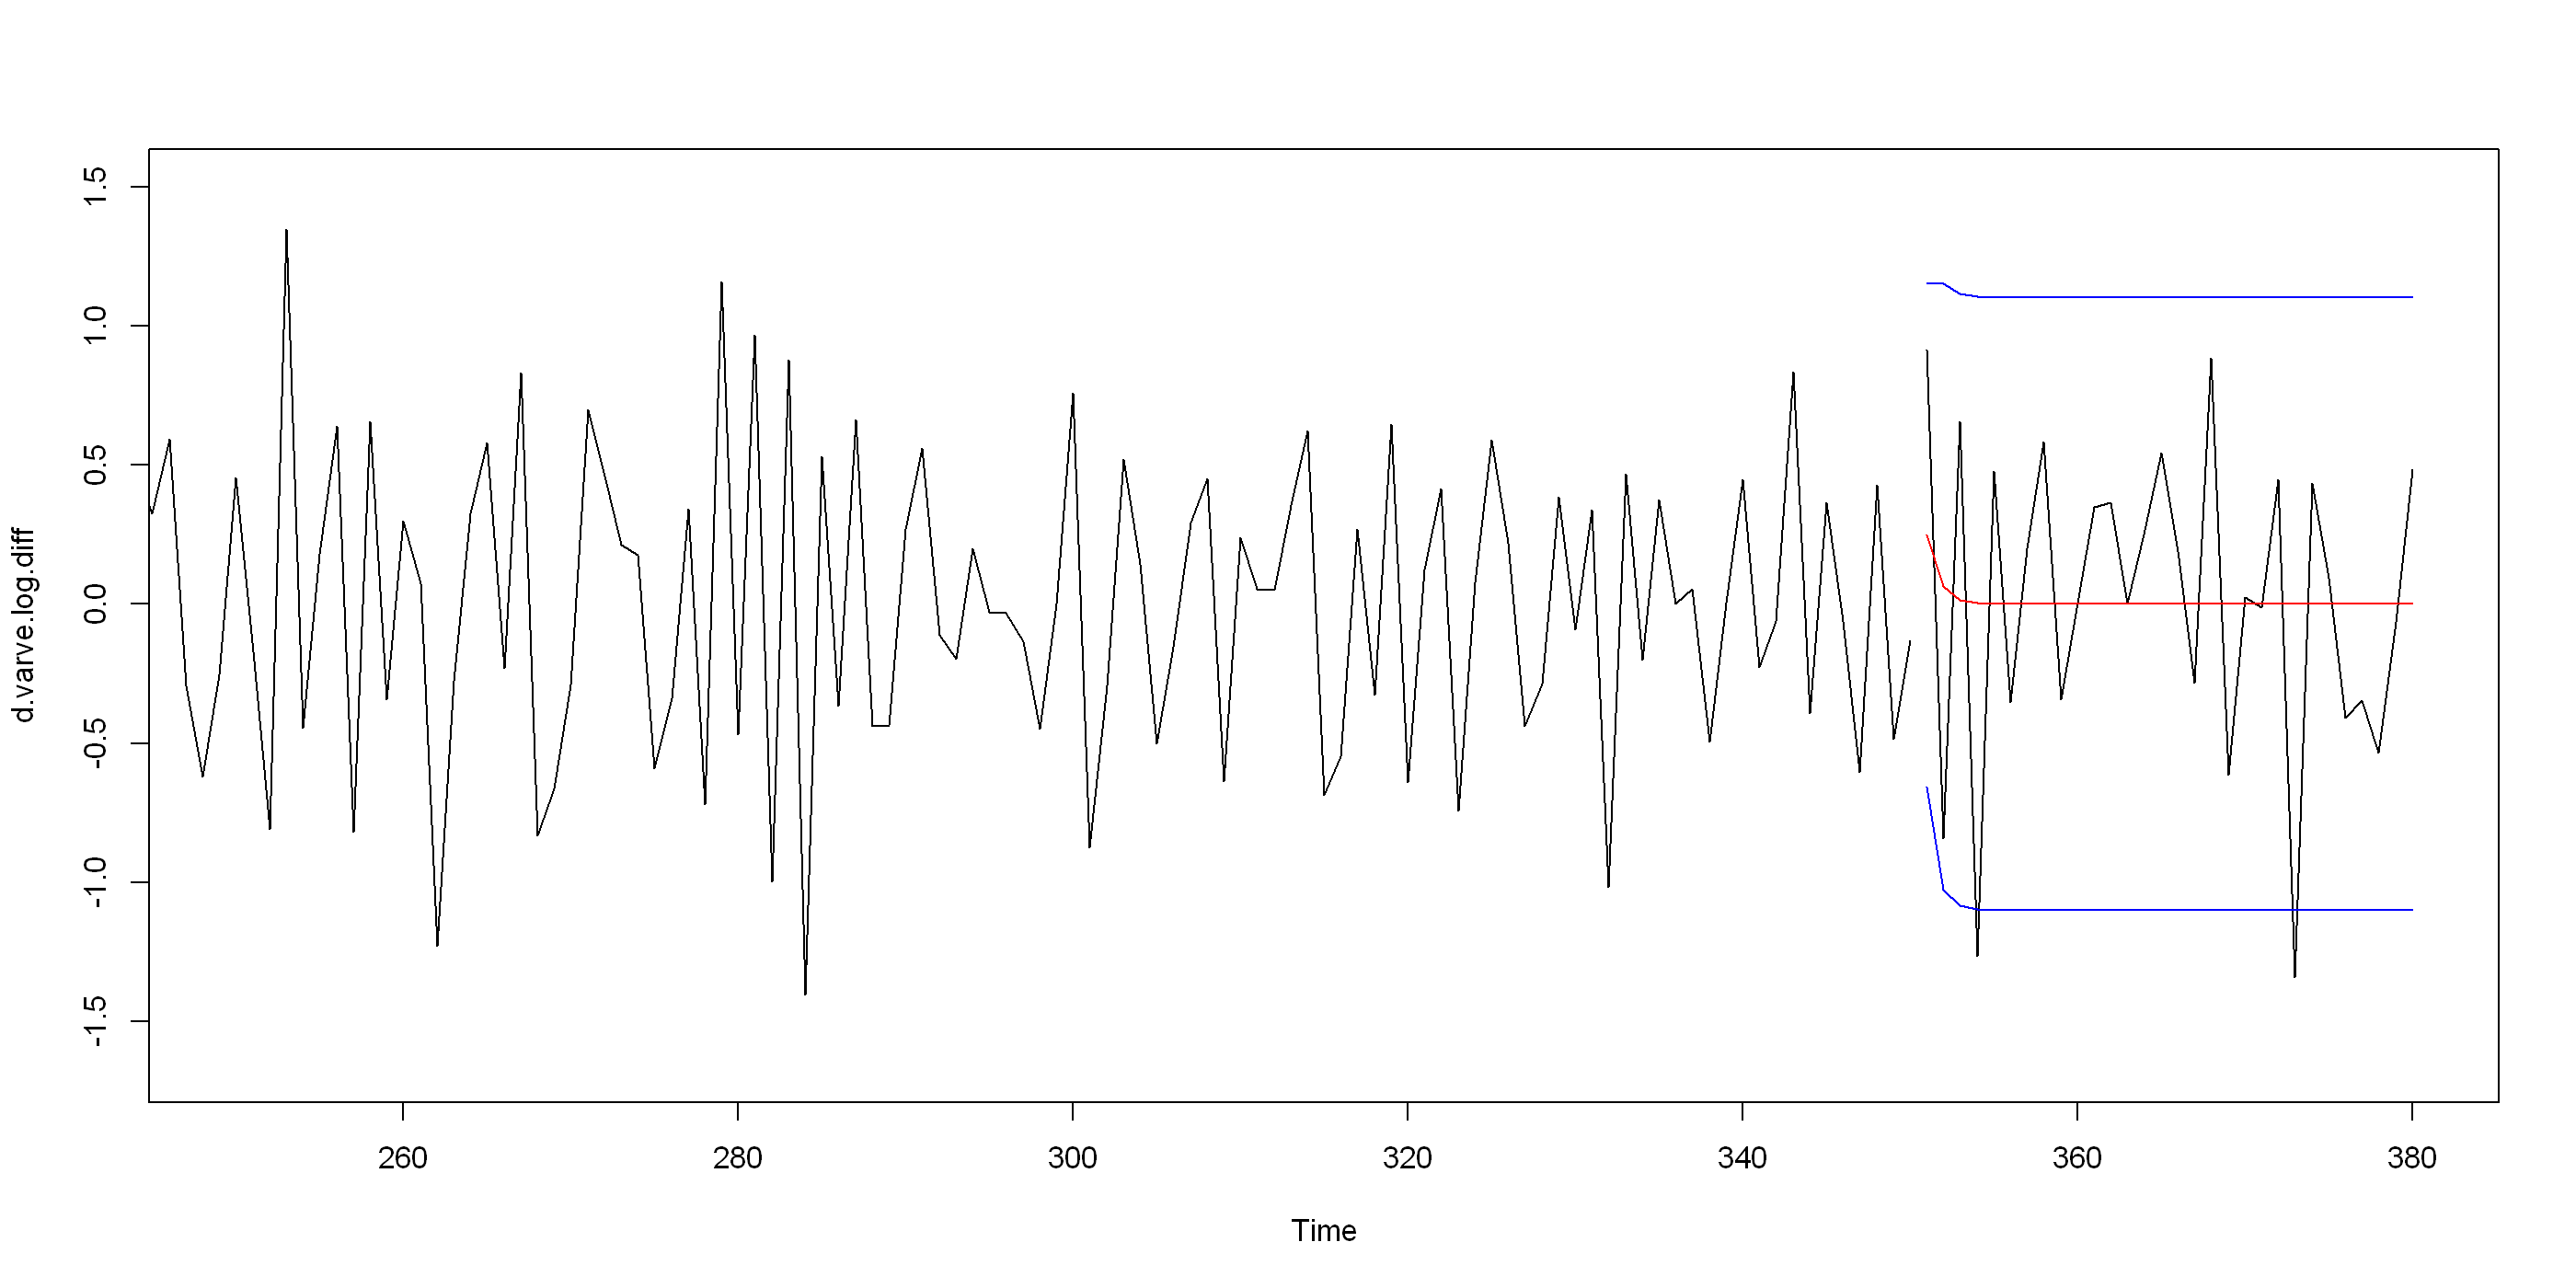

In [81]:
y_hat <- predict(model,n.ahead=30)
CI <- qnorm(0.975)*y_hat$se
plot(d.varve.log.diff,xlim=c(250,380))
lines(diff(d.varve_n))
abline(h=mean(d.varve.log),col="green")
lines(y_hat$pred+CI,col="blue")
lines(y_hat$pred-CI,col="blue")

lines(y_hat$pred,col="red")

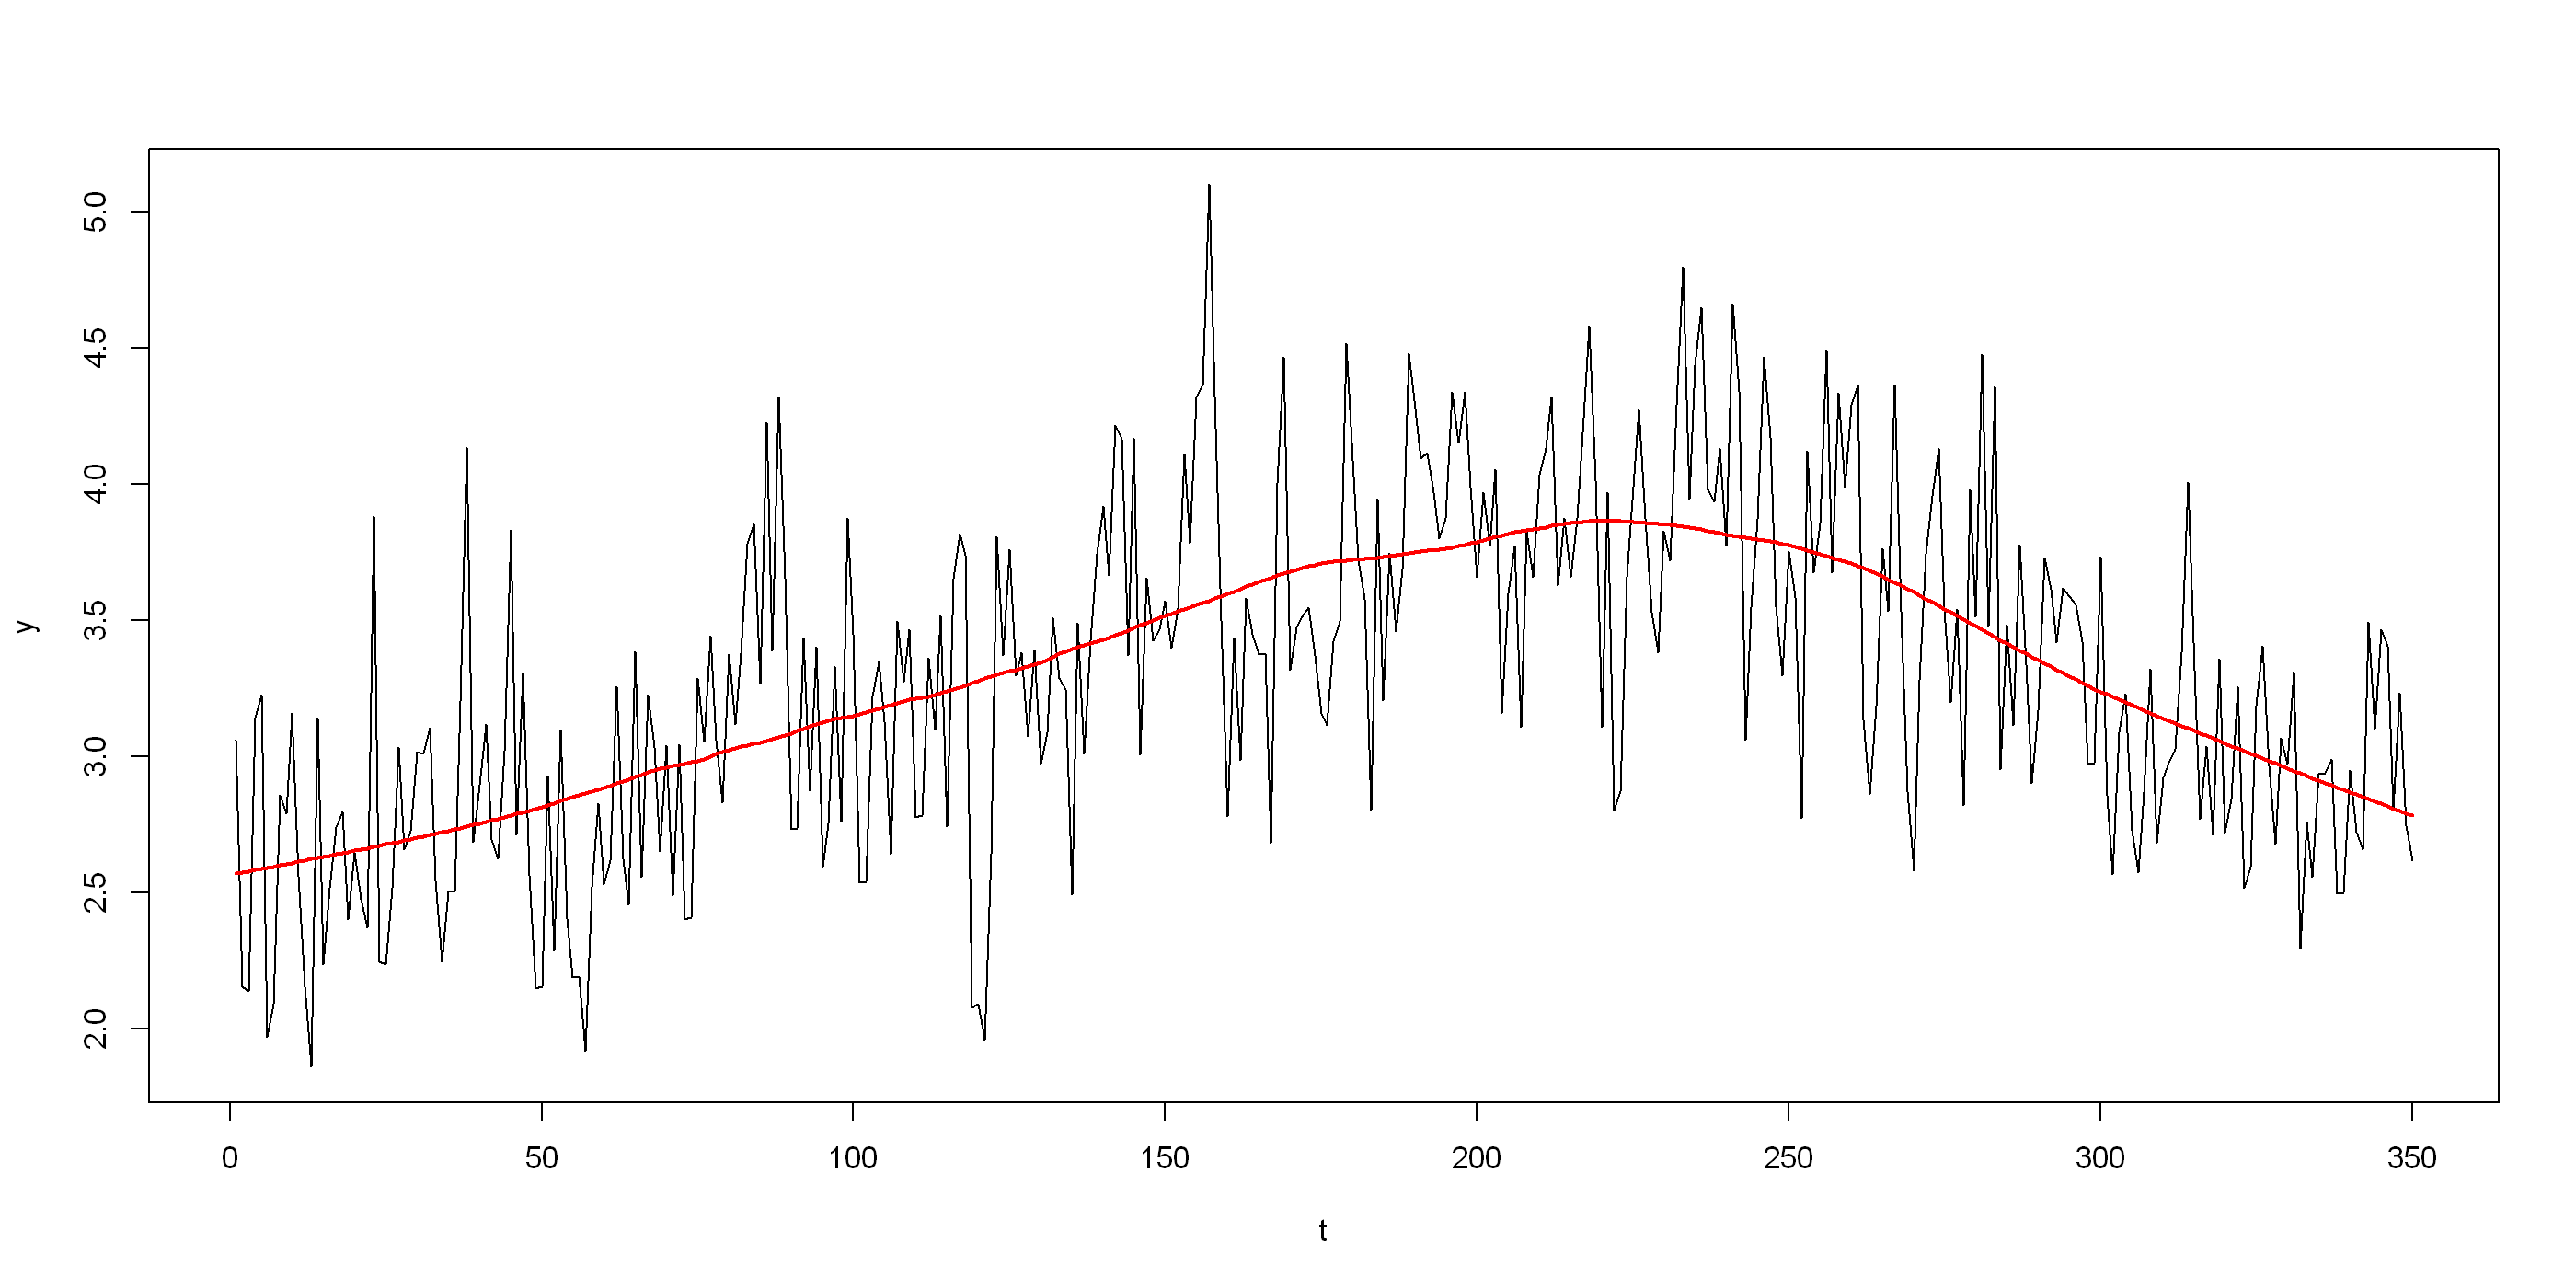

In [102]:
t <- seq_along(d.varve.log)
y <- as.numeric(d.varve.log)

fit.loess <- loess(y ~ t, span = 0.3, degree = 1)

plot(t, y, type = "l")
lines(t, fitted(fit.loess), col = "red", lwd = 2)

In [ ]:
fit.hw <- HoltWinters(d.varve.log, beta=FALSE, gamma=FALSE);
fit.hw 


Holt-Winters exponential smoothing without trend and without seasonal component.

Call:
HoltWinters(x = d.varve.log, beta = FALSE, gamma = FALSE)

Smoothing parameters:
 alpha: 0.1688476
 beta : FALSE
 gamma: FALSE

Coefficients:
      [,1]
a 2.945892

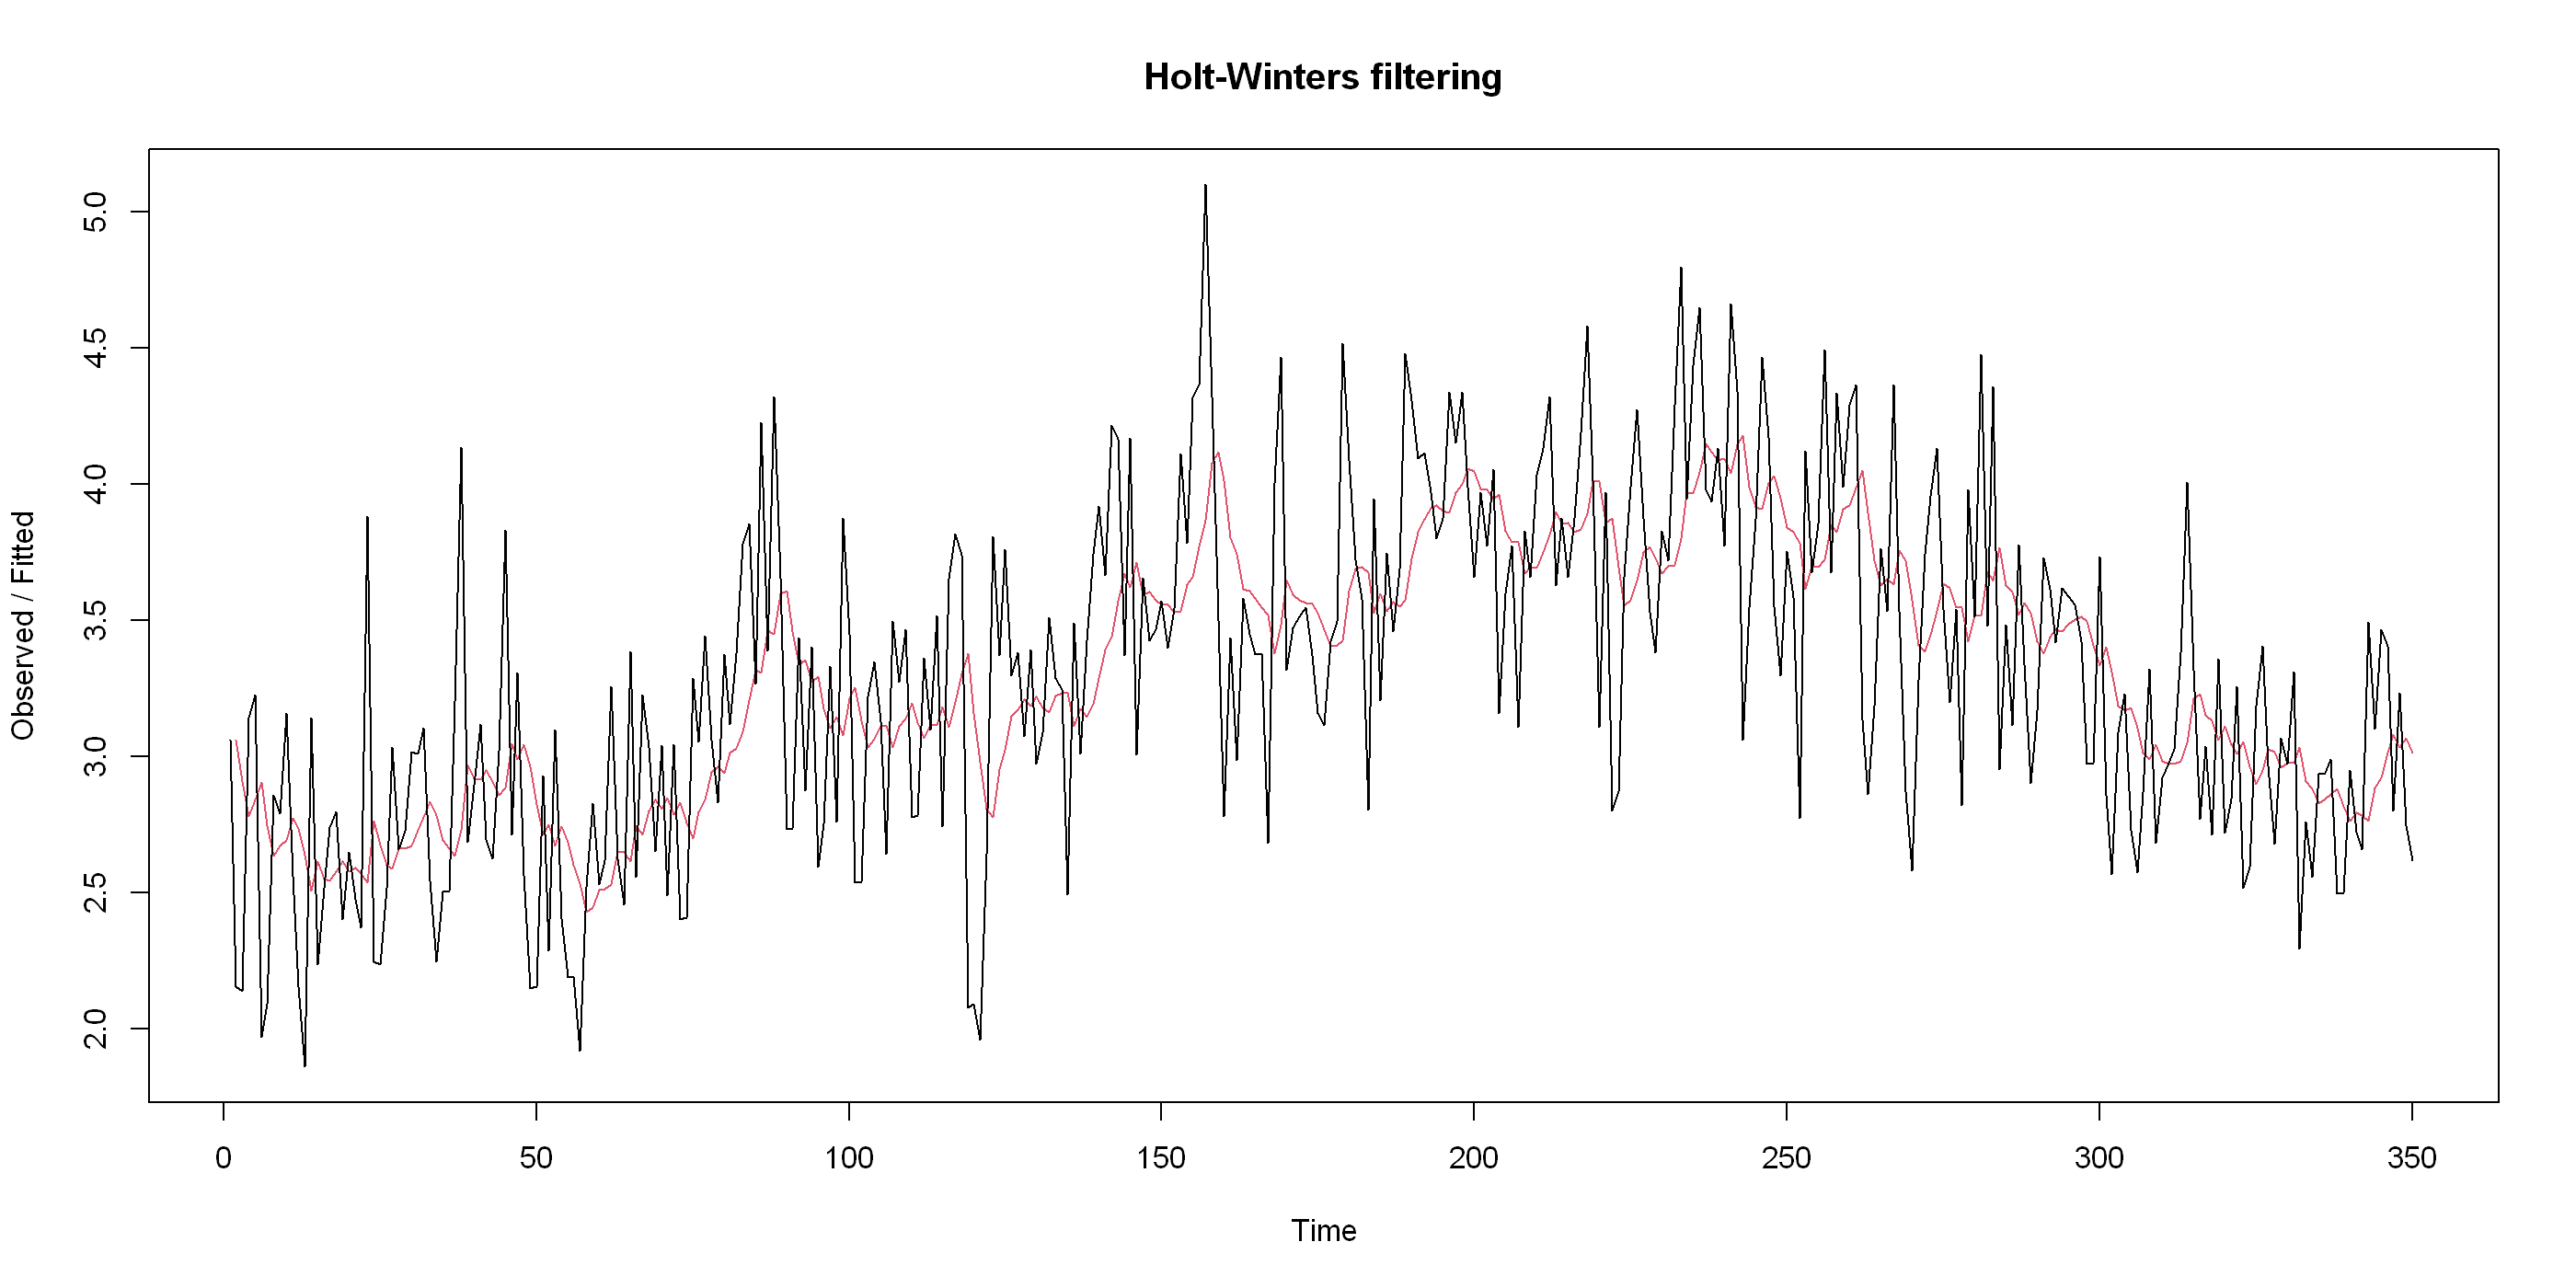

In [86]:
plot(fit.hw)

In [103]:
x_train <- window(d.varve.log,end=350-20)
x_test <- window(d.varve.log,start=330)

loess HoltWinters 
      0.155       0.115

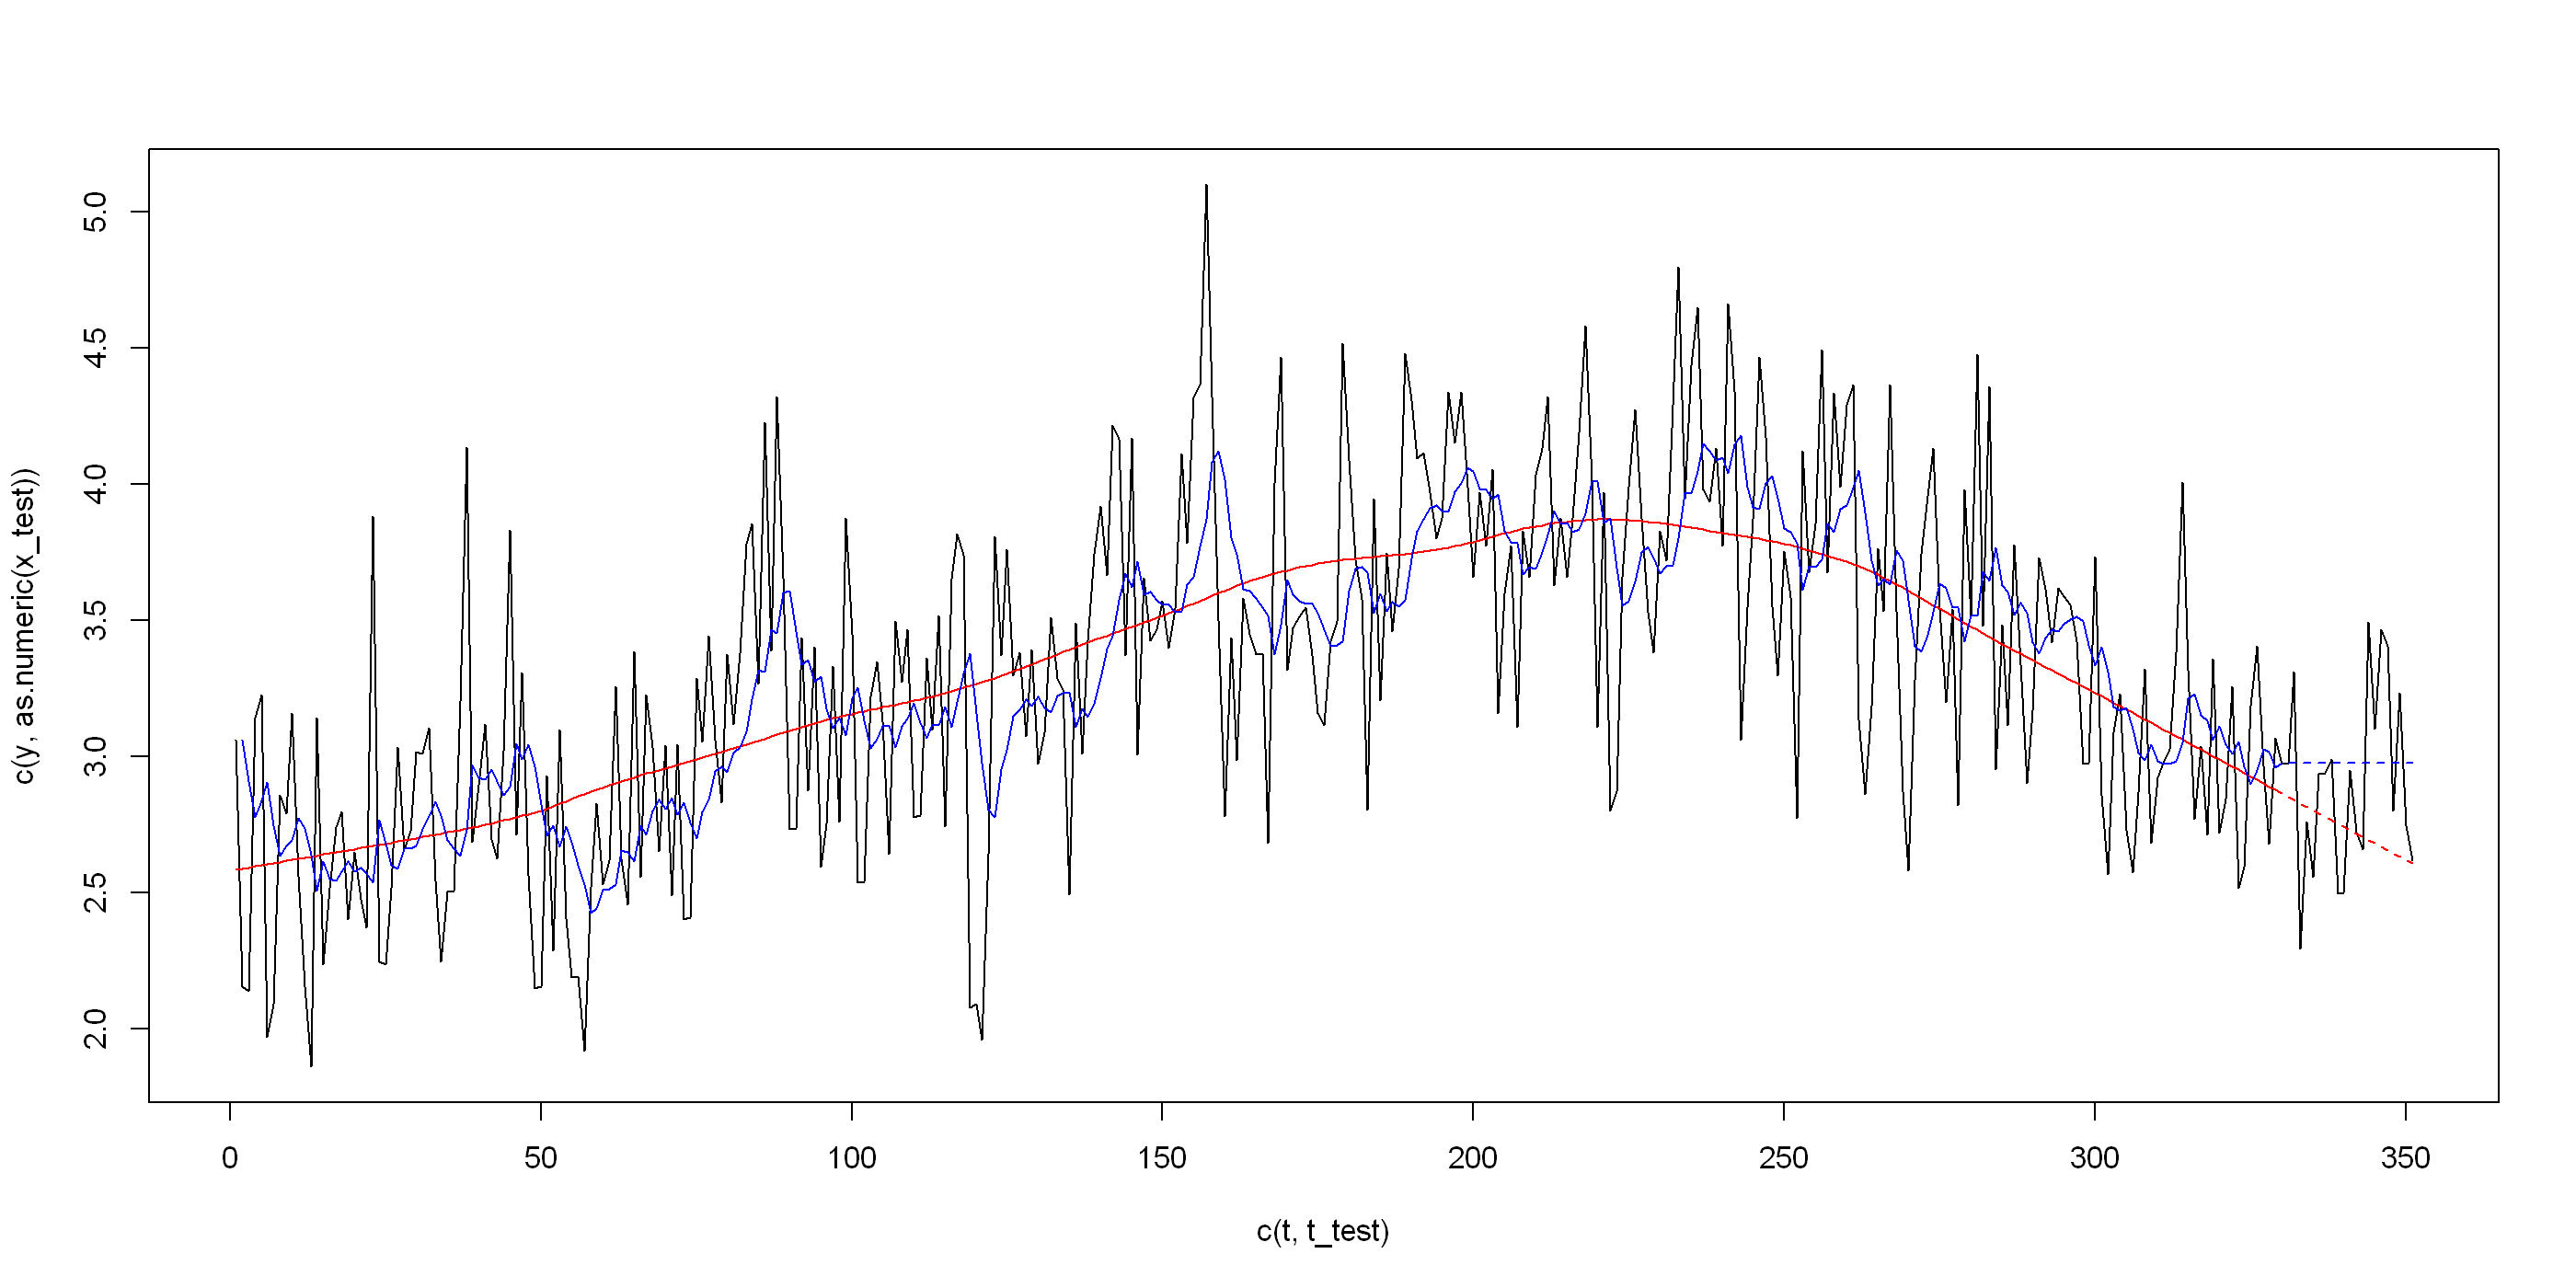

In [111]:
h <- length(x_test)
t_test <- length(x_train) + seq_len(h)

fit.loess <- loess(
  y ~ t,
  span = 0.3,
  degree = 1,
  control = loess.control(surface = "direct")
)

pred.loess <- predict(fit.loess, data.frame(t = t_test))
pred.hw <- as.numeric(predict(fit.hw, n.ahead = h))
hw.fitted <- as.numeric(fitted(fit.hw)[, "xhat"])

mse.loess <- mean((as.numeric(x_test) - pred.loess)^2)
mse.hw <- mean((as.numeric(x_test) - pred.hw)^2)

plot(c(t, t_test), c(y, as.numeric(x_test)), type = "l")
lines(t, fitted(fit.loess), col = "red")
lines(tail(t, length(hw.fitted)), hw.fitted, col = "blue")
lines(t_test, pred.loess, col = "red", lty = 2)
lines(t_test, pred.hw, col = "blue", lty = 2)

c(loess = round(mse.loess, 3), HoltWinters = round(mse.hw, 3))

In [112]:
set.seed(5)
ts.sim <- arima.sim(model = list(ar = c(0.3)), n = 100)

AR(1), AR(3), AR(14)

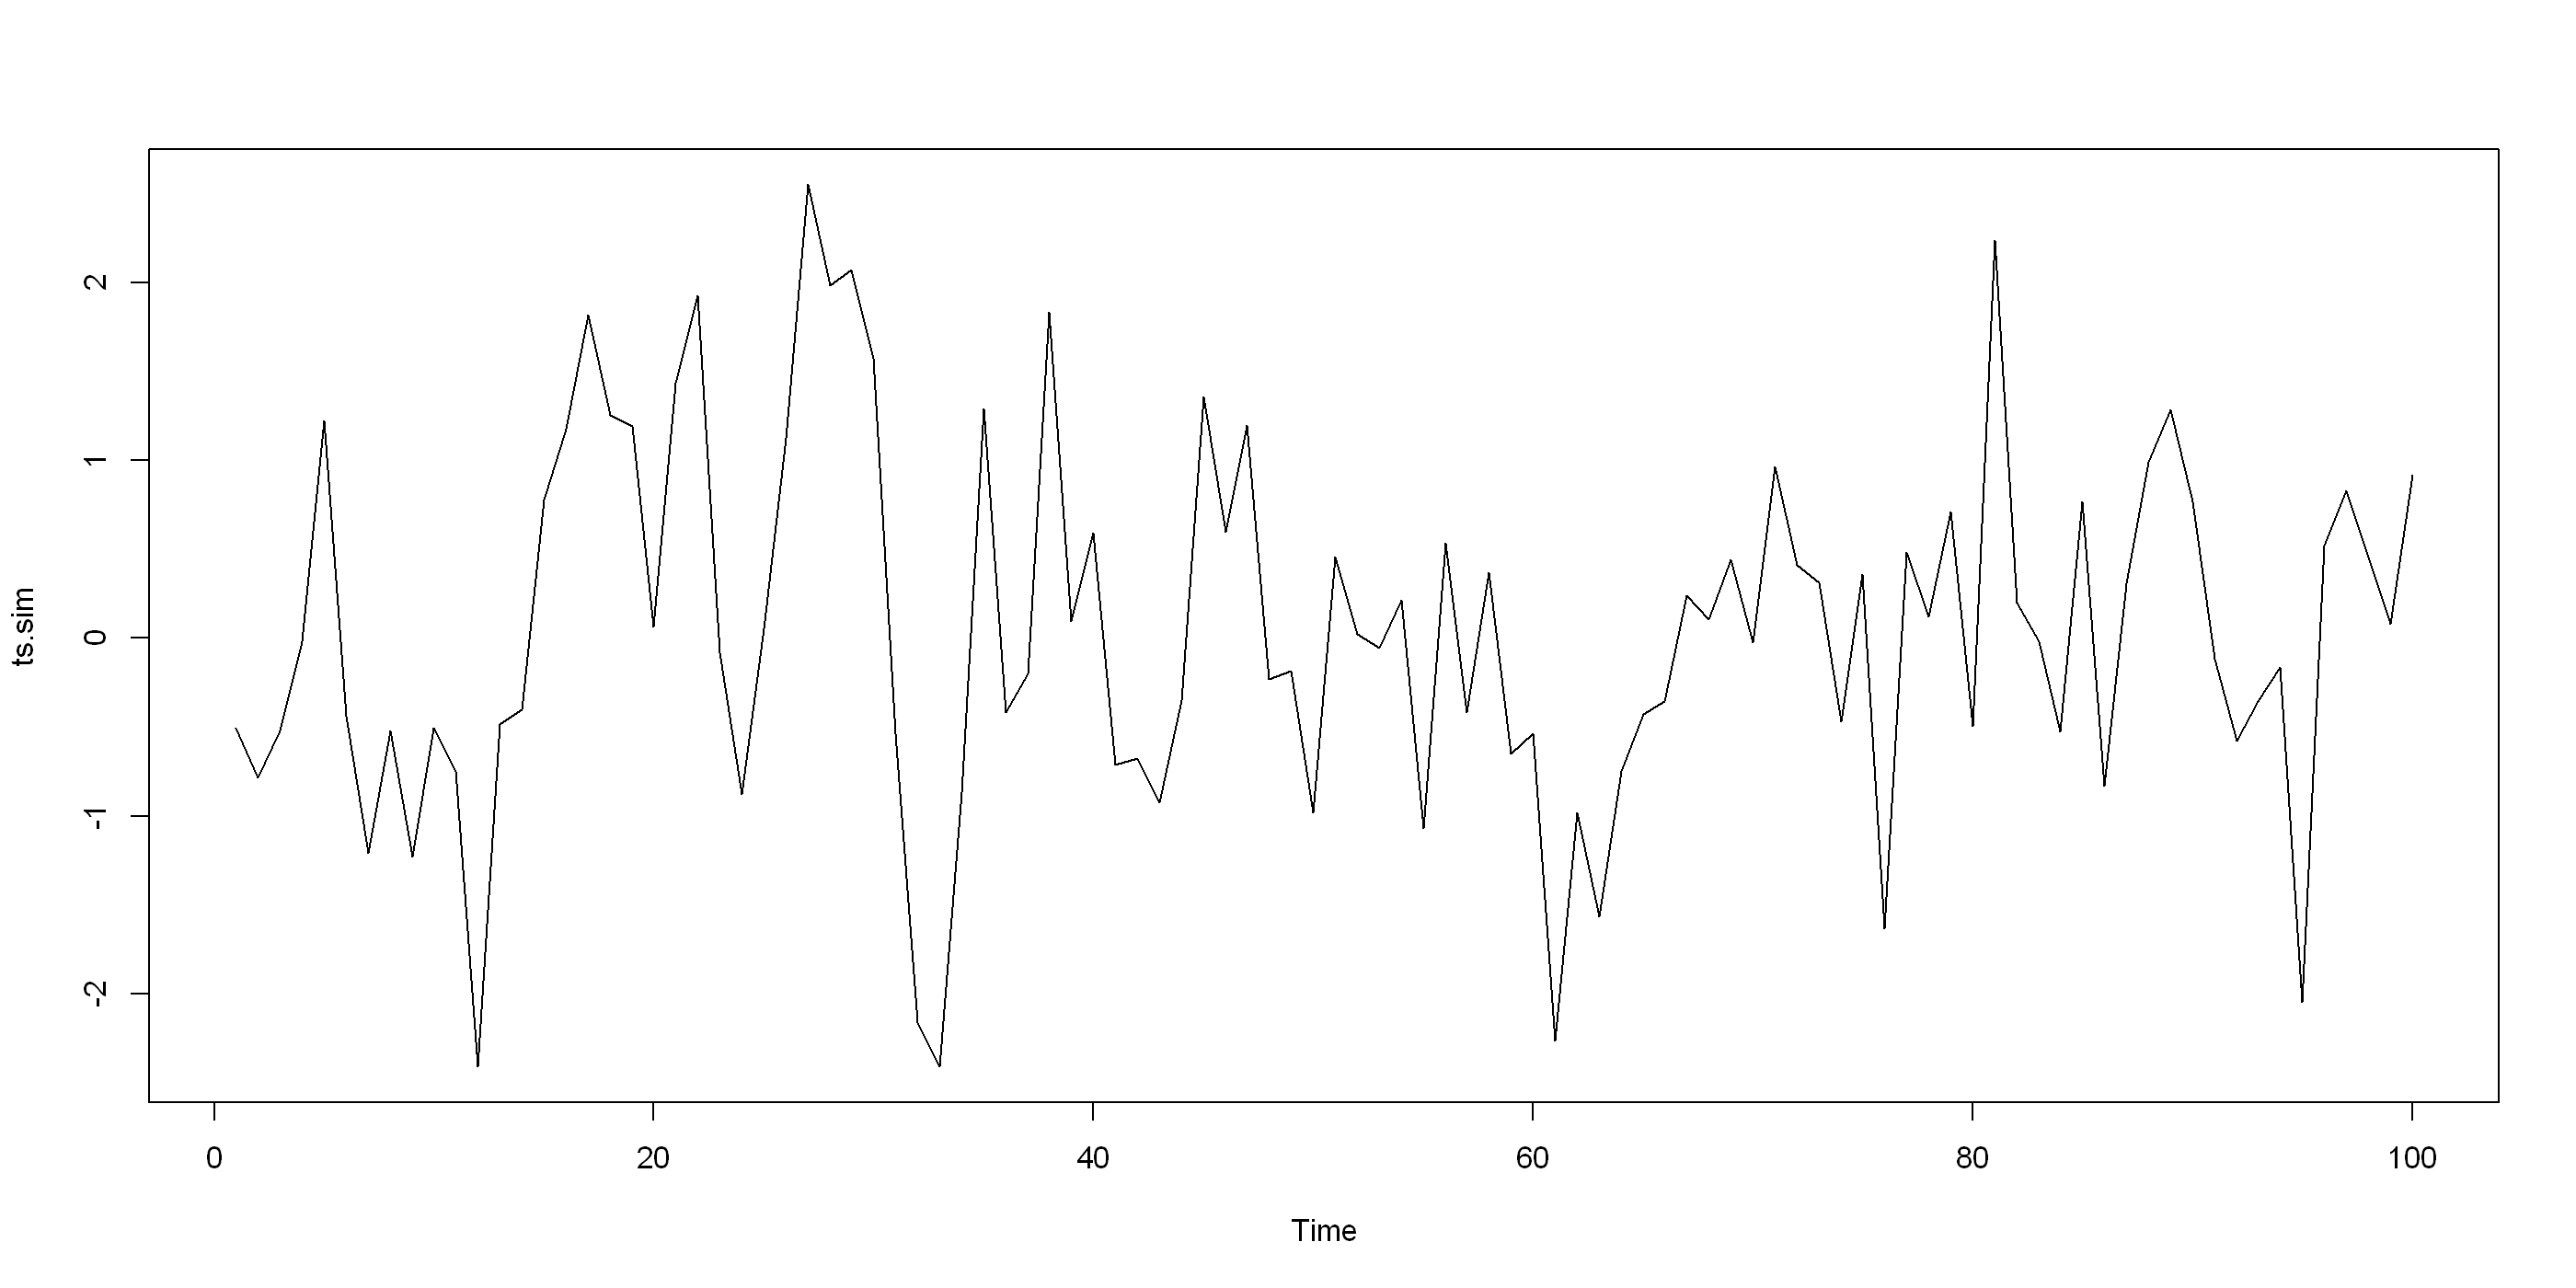

In [113]:
plot(ts.sim)

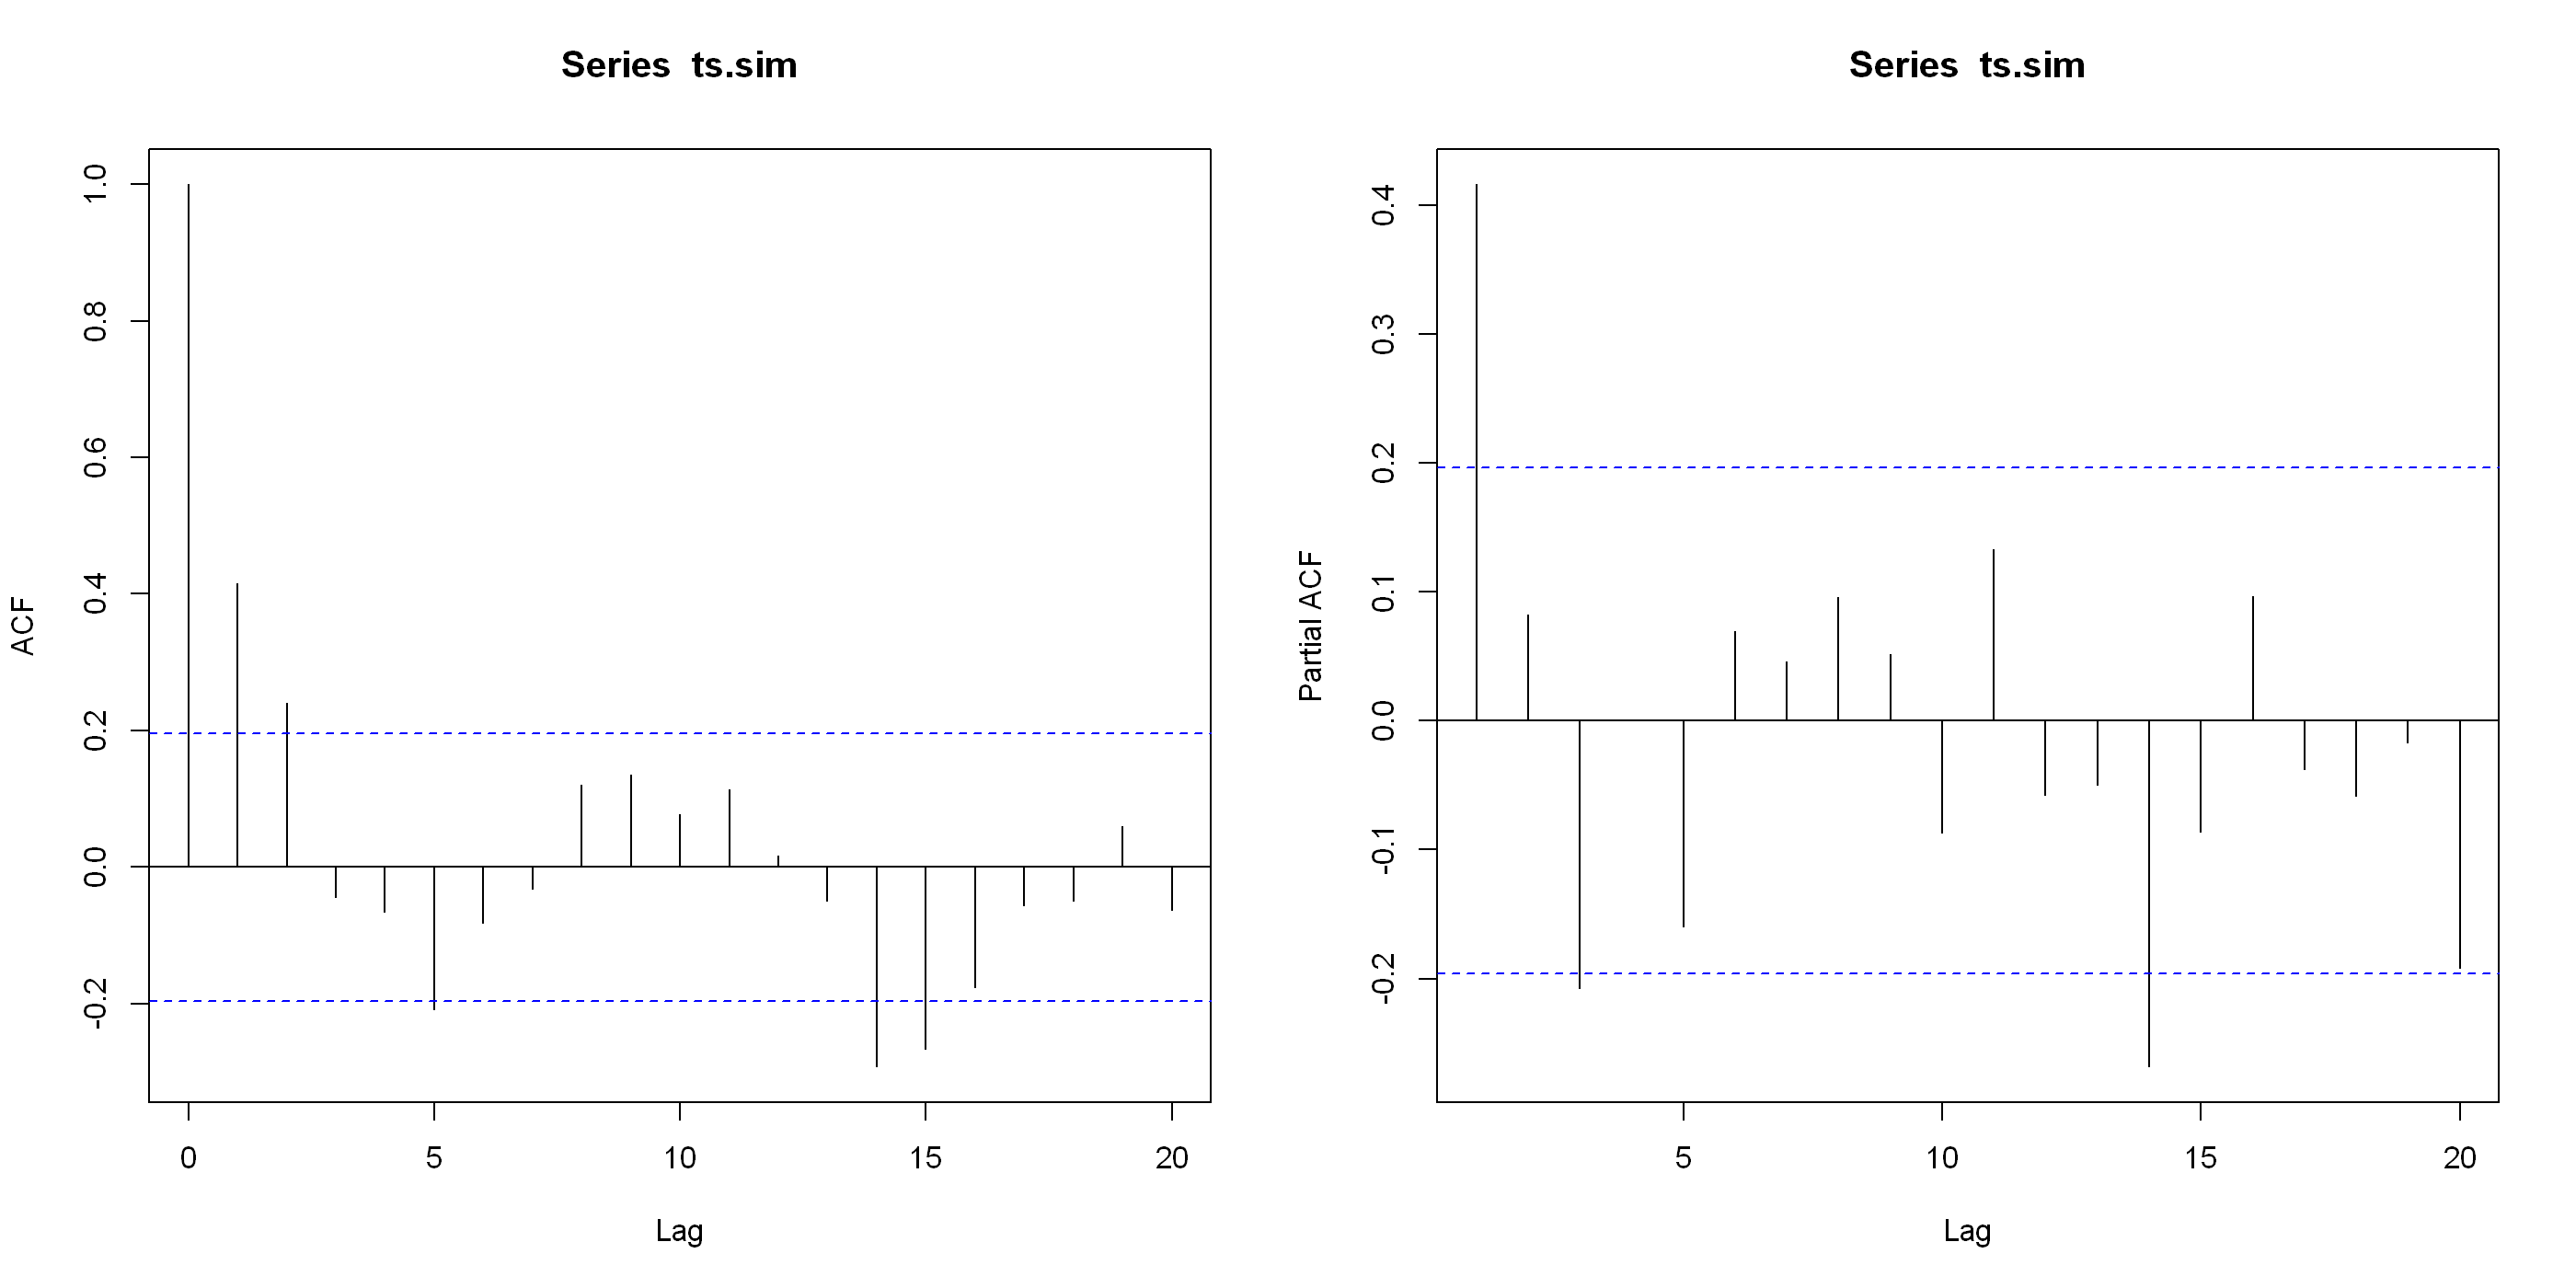

In [114]:
par(mfrow=c(1,2))
acf(ts.sim)
pacf(ts.sim)

In [118]:
fit <- auto.arima(
  ts.sim,
  max.p = 15,
  max.q = 0,
  max.d = 0,
  max.order = 15,
  seasonal = FALSE,
  stepwise = FALSE,
  approximation = FALSE,
  trace = TRUE
)


 ARIMA(0,0,0) with zero mean     : 290.2118
 ARIMA(0,0,0) with non-zero mean : 292.0882
 ARIMA(1,0,0) with zero mean     : 273.1667
 ARIMA(1,0,0) with non-zero mean : 275.198
 ARIMA(2,0,0) with zero mean     : 274.5993
 ARIMA(2,0,0) with non-zero mean : 276.6917
 ARIMA(3,0,0) with zero mean     : 272.5435
 ARIMA(3,0,0) with non-zero mean : 274.6377
 ARIMA(4,0,0) with zero mean     : 274.7598
 ARIMA(4,0,0) with non-zero mean : 276.9021
 ARIMA(5,0,0) with zero mean     : 274.397
 ARIMA(5,0,0) with non-zero mean : 276.5704
 ARIMA(6,0,0) with zero mean     : 276.2052
 ARIMA(6,0,0) with non-zero mean : 278.4563
 ARIMA(7,0,0) with zero mean     : 278.2162
 ARIMA(7,0,0) with non-zero mean : 280.5422
 ARIMA(8,0,0) with zero mean     : 279.6392
 ARIMA(8,0,0) with non-zero mean : 282.0477
 ARIMA(9,0,0) with zero mean     : 281.8509
 ARIMA(9,0,0) with non-zero mean : 284.332
 ARIMA(10,0,0) with zero mean     : 283.5346
 ARIMA(10,0,0) with non-zero mean : 286.0445
 ARIMA(11,0,0) with zero mean   

In [120]:
ar1 <- arima(ts.sim,order = c(1,0,0))
ar3 <- arima(ts.sim,order= c(3,0,0))
ar14 <- arima(ts.sim,order=c(14,0,0))

In [121]:
summary(ar1)
summary(ar3)
summary(ar14)


Call:
arima(x = ts.sim, order = c(1, 0, 0))

Coefficients:
         ar1  intercept
      0.4160     0.0487
s.e.  0.0906     0.1577

sigma^2 estimated as 0.8605:  log likelihood = -134.47,  aic = 274.95

Training set error measures:
                      ME      RMSE       MAE      MPE     MAPE      MASE
Training set 0.002802765 0.9276054 0.7360592 83.19797 161.9515 0.8243444
                    ACF1
Training set -0.03099039


Call:
arima(x = ts.sim, order = c(3, 0, 0))

Coefficients:
         ar1     ar2      ar3  intercept
      0.3979  0.1601  -0.2032     0.0492
s.e.  0.0974  0.1040   0.0971     0.1399

sigma^2 estimated as 0.8178:  log likelihood = -132,  aic = 274

Training set error measures:
                       ME      RMSE       MAE      MPE     MAPE     MASE
Training set 0.0007838257 0.9043037 0.7158793 127.5287 192.6969 0.801744
                    ACF1
Training set 0.003471946


Call:
arima(x = ts.sim, order = c(14, 0, 0))

Coefficients:
         ar1     ar2      ar3     ar4      ar5     ar6      ar7     ar8
      0.3946  0.1252  -0.1209  0.0274  -0.1791  0.0968  -0.0199  0.1323
s.e.  0.0944  0.1027   0.1025  0.1023   0.1039  0.1078   0.1124  0.1093
          ar9     ar10    ar11    ar12    ar13     ar14  intercept
      -0.0038  -0.1351  0.0985  0.0383  0.0573  -0.3024     0.0603
s.e.   0.1117   0.1093  0.1096  0.1129  0.1113   0.1010     0.1082

sigma^2 estimated as 0.6794:  log likelihood = -123.72,  aic = 279.44

Training set error measures:
                      ME      RMSE       MAE     MPE     MAPE      MASE
Training set -0.01281407 0.8242517 0.6538658 138.634 192.3574 0.7322925
                    ACF1
Training set -0.03049791

In [180]:
ar1_pred <- predict(ar1,n.ahead = 1)
ar3_pred <- predict(ar3,n.ahead = 1)
ar14_pred <- predict(ar14,n.ahead = 1)

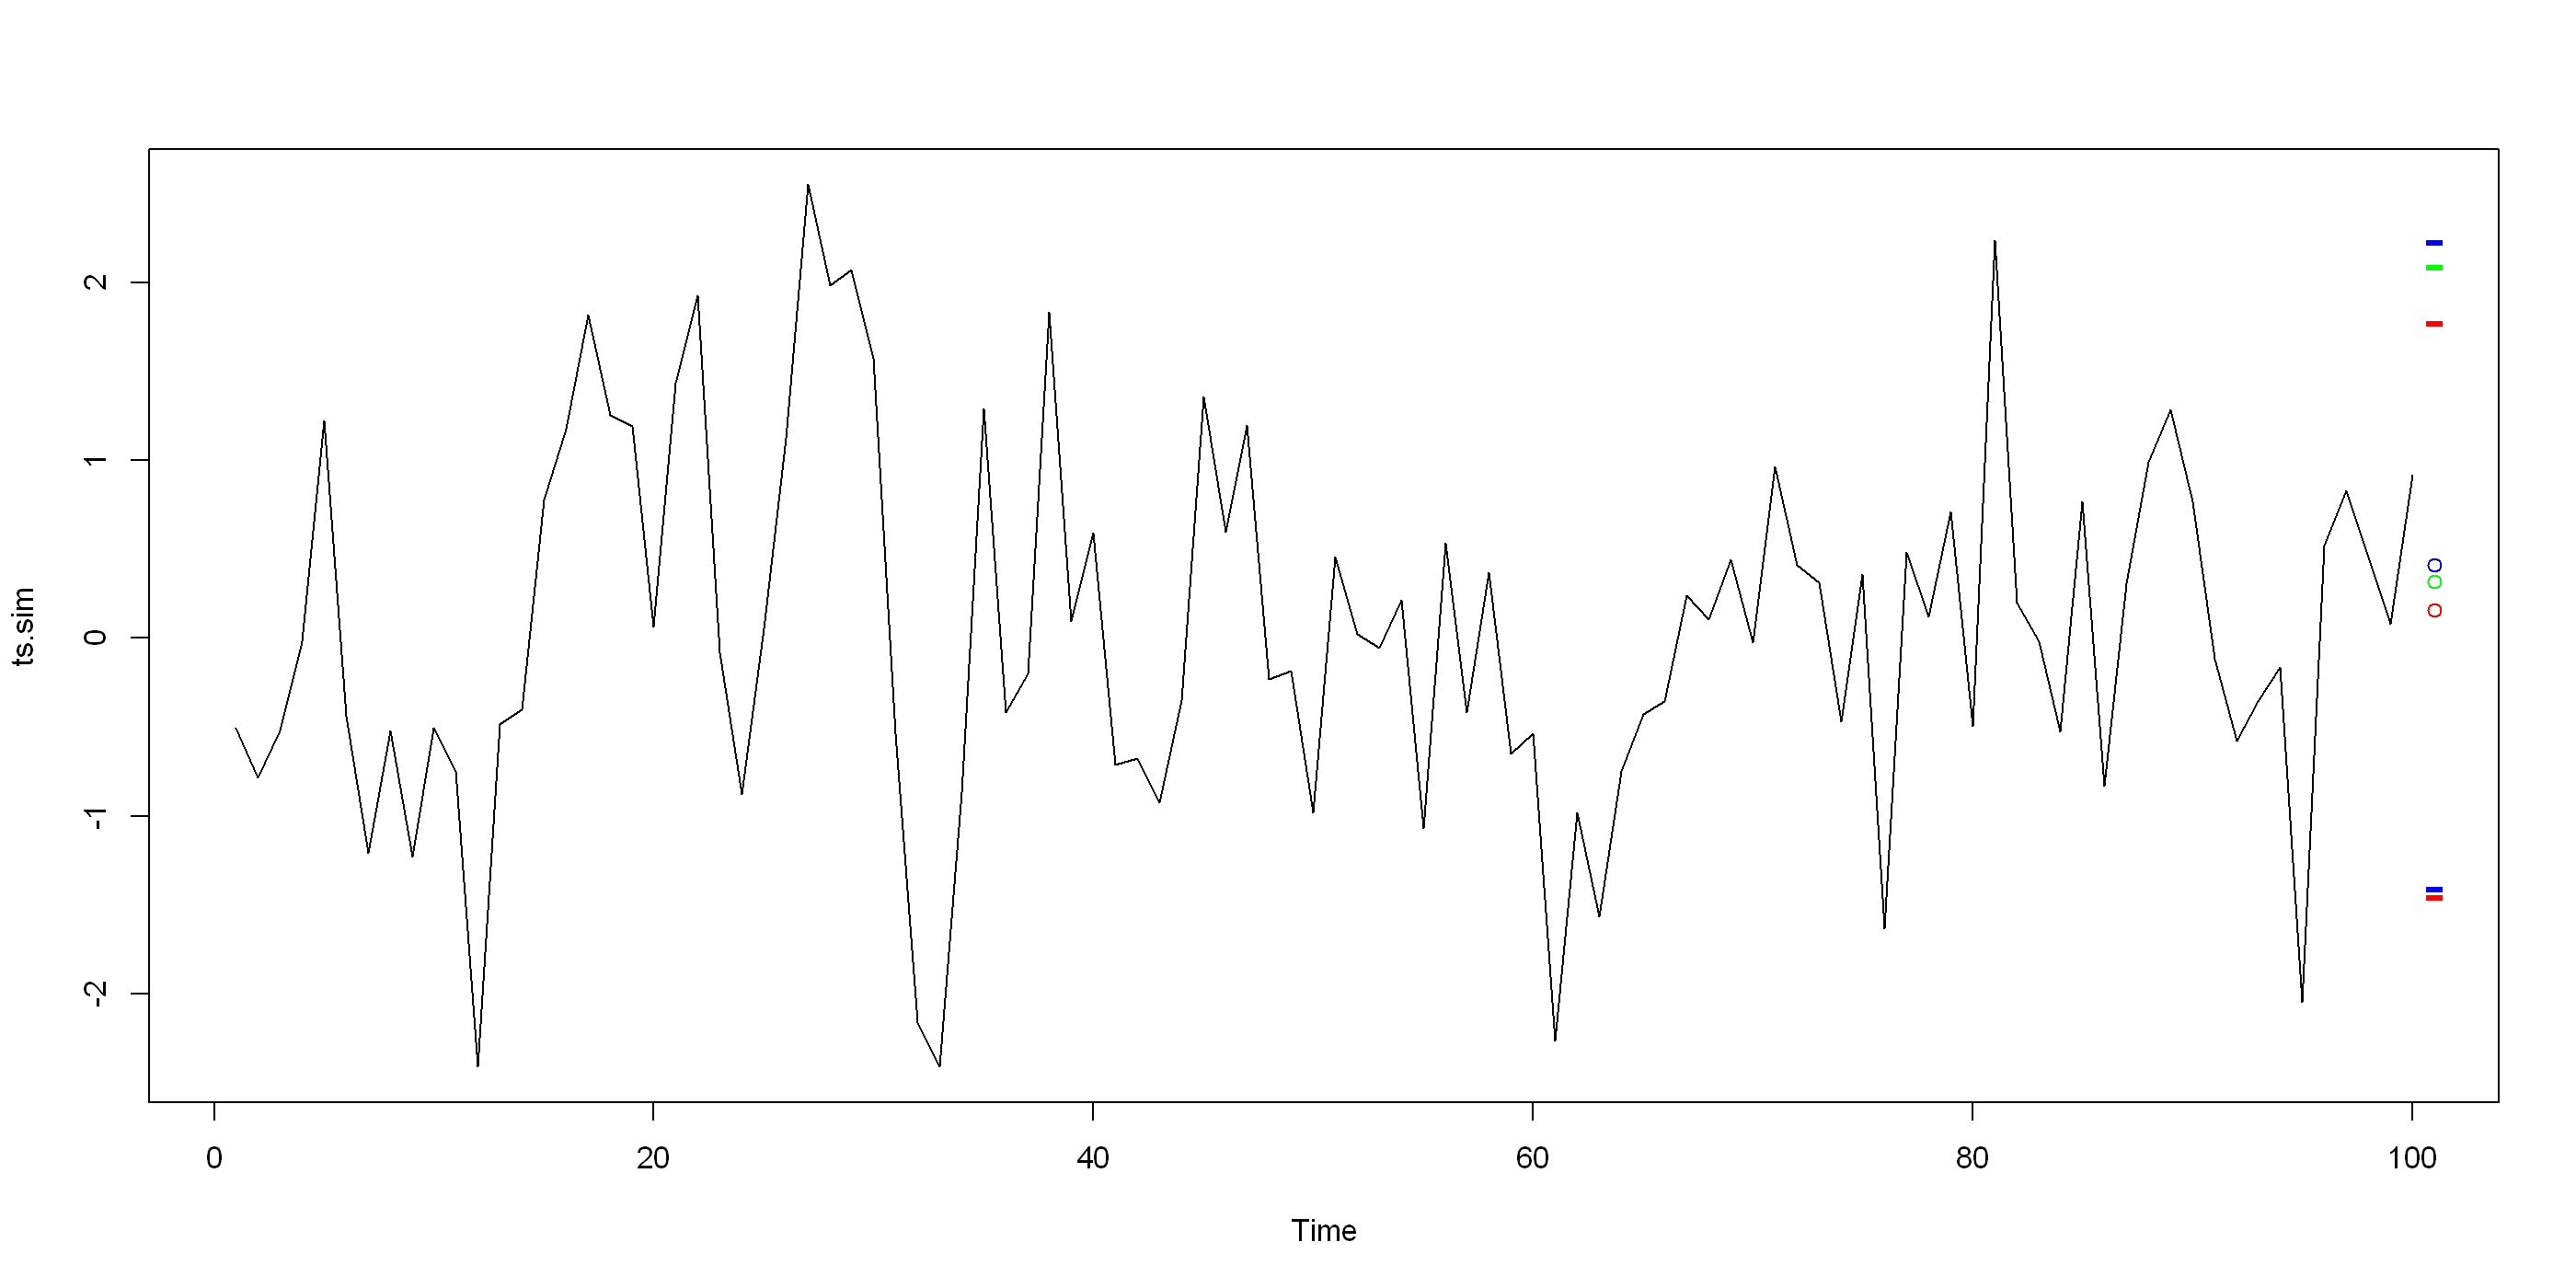

In [181]:
plot(ts.sim)

CI1 <- qnorm(0.975)*ar1_pred$se
CI3 <- qnorm(0.975)*ar3_pred$se
CI14 <- qnorm(0.975)*ar14_pred$se


lines(ar1_pred$pred,col="blue",type="p")

lines(ar1_pred$pred-CI1,col="blue",type="p",cex=2,pch='-')
lines(ar1_pred$pred+CI1,col="blue",type="p",cex=2,pch='-')

lines(ar3_pred$pred,col="green",type="p")
lines(ar3_pred$pred-CI3,col="green",type="p",cex=2,pch='-')
lines(ar3_pred$pred+CI3,col="green",type="p",cex=2,pch='-')

lines(ar14_pred$pred,col="red",type="p")
lines(ar14_pred$pred-CI14,col="red",type="p",cex=2,pch='-')
lines(ar14_pred$pred+CI14,col="red",type="p",cex=2,pch='-')

In [197]:
# Simulation
set.seed(1)
 # Initialization
 coverage.1 <- numeric(length = 100)
 coverage.3 <- numeric(length = 100)
 coverage.10 <- numeric(length = 100)
 ms.pred.error.1 <- numeric(100)
 ms.pred.error.3 <- numeric(100)
 ms.pred.error.10 <- numeric(100)
  for(i in 1:100){
# simulate AR(1) of length 101
sim <- arima.sim(model = list(ar = c(0.3)), n = 101)
# fit AR(1), AR(3) and AR(10)
fit1 <- arima(window(sim, start = 1, end = 100), order = c(1,0,0))
fit3 <- arima(window(sim, start = 1, end = 100), order = c(3,0,0))
fit10 <- arima(window(sim, start = 1, end = 100), order = c(10,0,0))
# 1-step prediction:
pred1 <- predict(fit1,n.ahead = 1)
pred3 <- predict(fit3,n.ahead = 1)
pred10 <- predict(fit10,n.ahead = 1)
4
# 1-step prediction interval:
PI1 <- c(pred1$pred-qnorm(0.975)*pred1$se,pred1$pred+qnorm(0.975)*pred1$se)
PI3 <- c(pred3$pred-qnorm(0.975)*pred3$se,pred3$pred+qnorm(0.975)*pred3$se)
PI10 <- c(pred10$pred-qnorm(0.975)*pred10$se,pred10$pred+qnorm(0.975)*pred10$se)
# MSE
ms.pred.error.1[i] <- (sim[101] - pred1$pred[1])^2
ms.pred.error.3[i] <- (sim[101] - pred3$pred[1])^2
ms.pred.error.10[i] <- (sim[101] - pred10$pred[1])^2
# Is true 101th observation contained in prediction interval?
coverage.1[i] <- ifelse(sim[101] >= PI1[1] & sim[101] <= PI1[2], 1, 0)
coverage.3[i] <- ifelse(sim[101] >= PI3[1] & sim[101] <= PI3[2], 1, 0)
coverage.10[i] <- ifelse(sim[101] >= PI10[1] & sim[101] <= PI10[2], 1, 0)
}
 # How often in 100 times is true value contained in prediction interval?
 sum(coverage.1)
 sum(coverage.3)
 sum(coverage.10)
 # Mean squared error averaged over 100 simulations
 mean(ms.pred.error.1)
 mean(ms.pred.error.3)
 mean(ms.pred.error.10)

[1] 92

[1] 92

[1] 86

[1] 1.161098

[1] 1.235414

[1] 1.437393